In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from scipy.stats import chi2_contingency, f_oneway, spearmanr, pearsonr 
from sklearn.preprocessing import KBinsDiscretizer
from optbinning import BinningProcess
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import FunctionTransformer
import xgboost as xgb

import warnings
warnings.filterwarnings("ignore", message="'force_all_finite' was renamed")

In [2]:
dane = pd.read_csv("zbiór_6.csv")

In [3]:
dane

,szczegolnaFormaPrawna_Symbol,formaWlasnosci_Symbol,pkdKod,wsk_liczba_dni_istnienia,Aktywa,Aktywa_trwale,Wartosci_niematerialne_prawne,Wartosc_firmy,Rzeczowe_aktywa_trwale,Srodki_trwale,...,wsk_struktura_kap_wlasnego_s_1,wsk_struktura_kap_wlasnego_s_2,wsk_zadluzenia,wsk_zob_dlugoterminowe_aktywa_rzeczowe,wsk_zob_oprocentowanych,wsk_zob_oprocentowanych_aktywa_rzeczowe,wsk_struktura_kap_obcego_s,wsk_zob_s_aktywa_rzeczowe,wsk_fin_majatku_kapitalem,default
0,117,214,4120,5624,572634.82,566043.03,0.00,0.0,566043.03,498829.92,...,0.930147,0.931558,0.075098,0.069853,0.000000,0.000000,0.069853,0.068339,-5.068154,1
1,117,215,7740,1706,28160219.63,25536228.41,14188900.51,0.0,3298.14,3298.14,...,0.992826,0.993019,0.003572,0.000000,0.000000,0.000000,0.007174,-0.156534,0.961805,1
2,117,214,4722,1700,3912177.84,1908325.29,0.00,0.0,1908325.29,1908325.29,...,0.165447,0.231344,5.044216,0.395688,0.571130,0.571130,0.834553,0.549711,-0.629321,1
3,117,214,7022,1588,53606.17,11200.00,0.00,0.0,0.00,0.00,...,0.153153,0.153153,5.529399,0.846847,0.000000,0.000000,0.846847,0.846847,-0.070509,1
4,117,224,6910,3023,99060.00,30500.00,0.00,0.0,0.00,0.00,...,0.167060,0.167060,4.985857,0.832940,0.100171,0.100171,0.832940,0.832940,-0.203486,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,117,214,5610,1364,132766.15,0.00,0.00,0.0,0.00,0.00,...,0.917131,2.589432,0.090356,0.000000,0.000000,0.000000,0.082869,-0.562949,0.917131,0
2996,117,214,6820,7020,494814.86,244029.62,0.00,0.0,244029.62,244029.62,...,0.528952,0.832334,0.890531,0.056548,0.024251,0.024251,0.471048,0.106553,0.070593,0
2997,117,216,7010,5291,86422.61,4700.00,0.00,0.0,0.00,0.00,...,0.969591,0.969591,0.031362,0.030409,0.000000,0.000000,0.030409,0.030409,0.967842,0
2998,117,214,4110,1891,4950507.97,995440.23,0.00,0.0,713268.57,332007.50,...,0.577655,1.218204,0.731138,0.261547,0.000020,0.000020,0.422345,-0.103469,0.471356,0


# 1. Eksploracja danych (EDA)

### a) rozmiar danych

In [4]:
rozmiar = dane.shape

print(f"Rozmiar: {rozmiar}")
print(f"Liczba wierszy: {rozmiar[0]}")
print(f"Liczba kolumn: {rozmiar[1]}")

Rozmiar: (3000, 220)
Liczba wierszy: 3000
Liczba kolumn: 220


### a) typy danych

In [5]:
dane.info()
# Mamy 213 kolumn zmiennych typu float64, 5 kolumn zmiennych typu int63, 2 kolumny zmiennych typu object

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Columns: 220 entries, szczegolnaFormaPrawna_Symbol to default
dtypes: float64(213), int64(5), object(2)
memory usage: 5.0+ MB


In [6]:
dane.loc[:, dane.dtypes == object]
# kolumny typu object to: schemat_wsk_bilans i schemat_wsk_rzis z wartościami: 'SFIJIN', 'SFJMI', 'SFJMA'
# czyli faktycznie są kategoryczne a nie liczby zapisane jako napis (które dałoby się zamienić na int lub float)
# zatem w preprocessingu na tych kolumnach zrobimy OneHotEncoding

,schemat_wsk_bilans,schemat_wsk_rzis
0,SFJIN,SFJIN
1,SFJIN,SFJIN
2,SFJIN,SFJIN
3,SFJMI,SFJMI
4,SFJMI,SFJMI
...,...,...
2995,SFJMA,SFJMA
2996,SFJIN,SFJIN
2997,SFJMI,SFJMI
2998,SFJMA,SFJIN


In [7]:
# kolumny numeryczne
num_cols = dane.select_dtypes(include=['float64', 'int64']).drop(columns=['default'])
len(num_cols.columns)

217

### b) wartości inf

In [8]:
num_cols = dane.select_dtypes(include=['float64', 'int64']).drop(columns=['default'])

In [9]:
np.isinf(num_cols).any().any()
# mamy wartości inf - trzeba coś z nimi zrobić

True

In [10]:
inf_count = np.isinf(num_cols).sum()
inf_count[inf_count > 0]

wsk_kapital_do_aktywa               8
wsk_plynnosc_biez_1               921
wsk_struktura_kap_wlasnego_s_2     93
dtype: int64

In [11]:
# Zastąpienie wartości inf wartościami NA 
# (wartości inf mogły wyjść przez różne błędy np. dzielenie przez 0, nie wiadomo czy oznaczają one duże wartości, więc lepiej po prostu dać NA)

for col in num_cols.columns:
    inf_pos = dane[col] == np.inf
    inf_neg = dane[col] == -np.inf
    
    if inf_pos.any() or inf_neg.any():
        dane[col] = dane[col].replace([np.inf, -np.inf], np.nan)

In [12]:
num_cols = dane.select_dtypes(include=['float64', 'int64']).drop(columns=['default'])
np.isinf(num_cols).any().any()
# już nie ma wartości inf

False

### c) braki daych

In [13]:
braki = dane.isna().sum() #zsumowane NA w wierszach 
braki[braki > 0] #wybieramy te wiersze w ktorych sa niezerowe braki 

wsk_kapital_do_aktywa                 57
RP_przeplywy_operacyjne             2981
RP_amortyzacja                      2884
wsk_akt_generowania_got_2           2981
wsk_pokrycie_wyd_fin_gotowkowe_2    2981
wsk_pokrycie_zob_kr_gotowkowe_2     2981
wsk_zadluzenia_gotowki_2            2981
wsk_plynnosc_biez_1                 1040
wsk_zysk_CF_operacyjny              2981
wsk_struktura_kap_wlasnego_s_2       142
dtype: int64

In [14]:
# Wszystkie kolumny, w których są braki danych są numeryczne
# Kolumny z większością braków (np. 2891) usuwamy
# Kolumny z mniejszą ilością braków (49, 119) - zastępujemy medianą

In [15]:
# Usuwanie kolumn z dużą liczbą braków

braki_procent = dane.isna().sum() / len(dane)

cols_to_drop = braki_procent[braki_procent > 0.8].index # powyżej 80% braków danych usuwamy kolumnę 
dane.drop(columns=cols_to_drop, inplace=True)

print(f"Usunięte {len(cols_to_drop)} kolumn z dużą liczbą braków:" )
print(cols_to_drop.tolist())

Usunięte 7 kolumn z dużą liczbą braków:
['RP_przeplywy_operacyjne', 'RP_amortyzacja', 'wsk_akt_generowania_got_2', 'wsk_pokrycie_wyd_fin_gotowkowe_2', 'wsk_pokrycie_zob_kr_gotowkowe_2', 'wsk_zadluzenia_gotowki_2', 'wsk_zysk_CF_operacyjny']


In [16]:
# Pozostałe braki danych zastąpimy medianą w preprocessing

### d) rozkłady danych

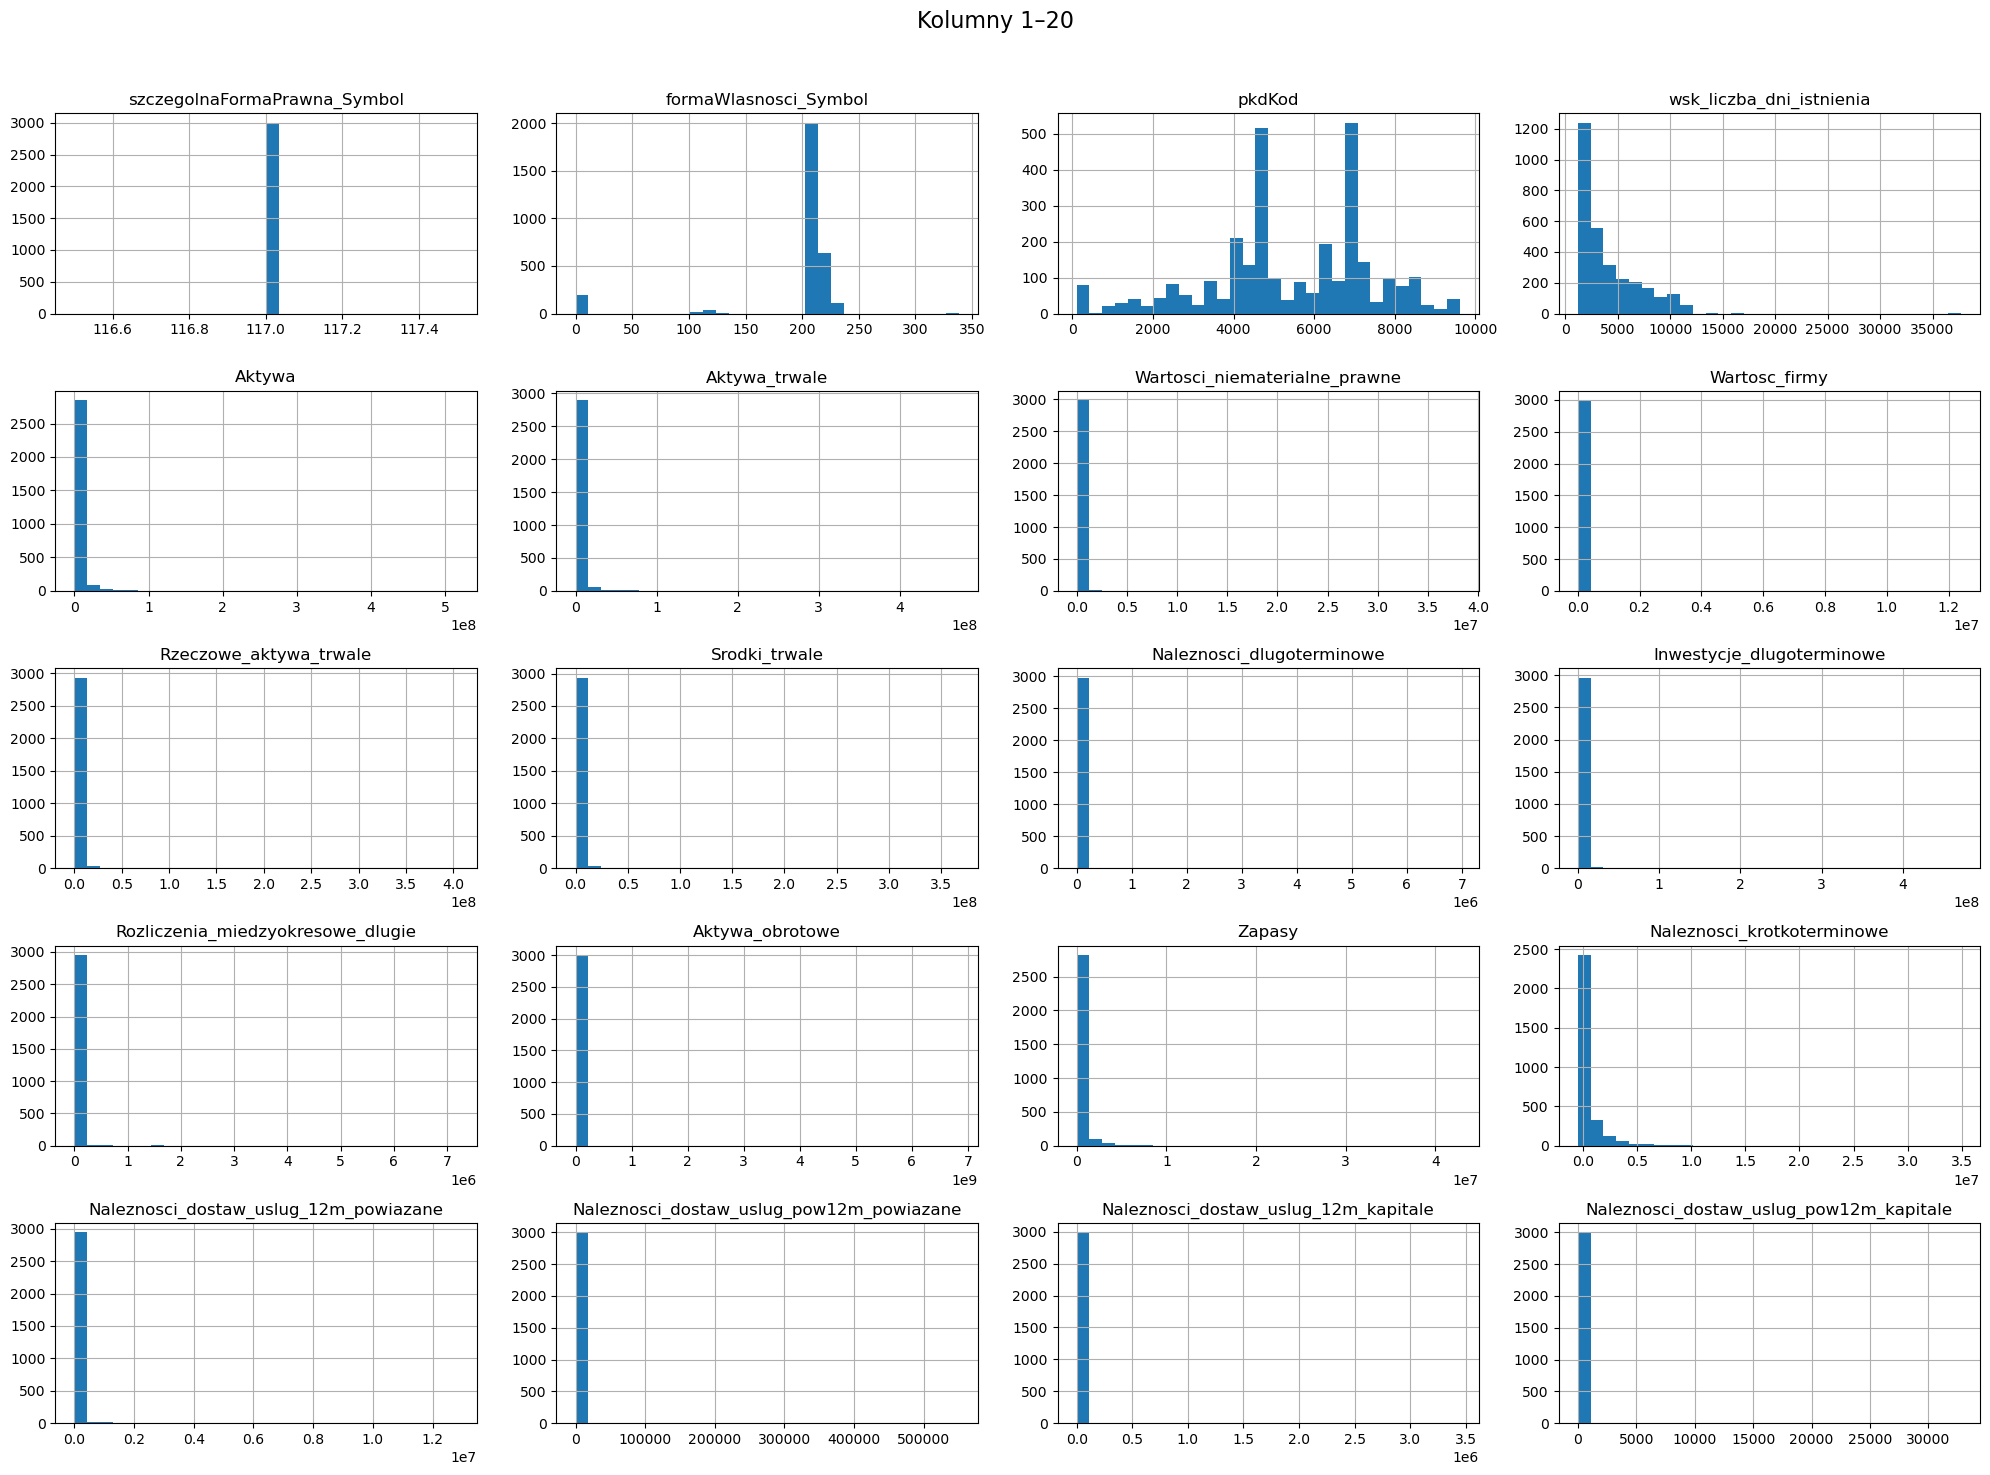

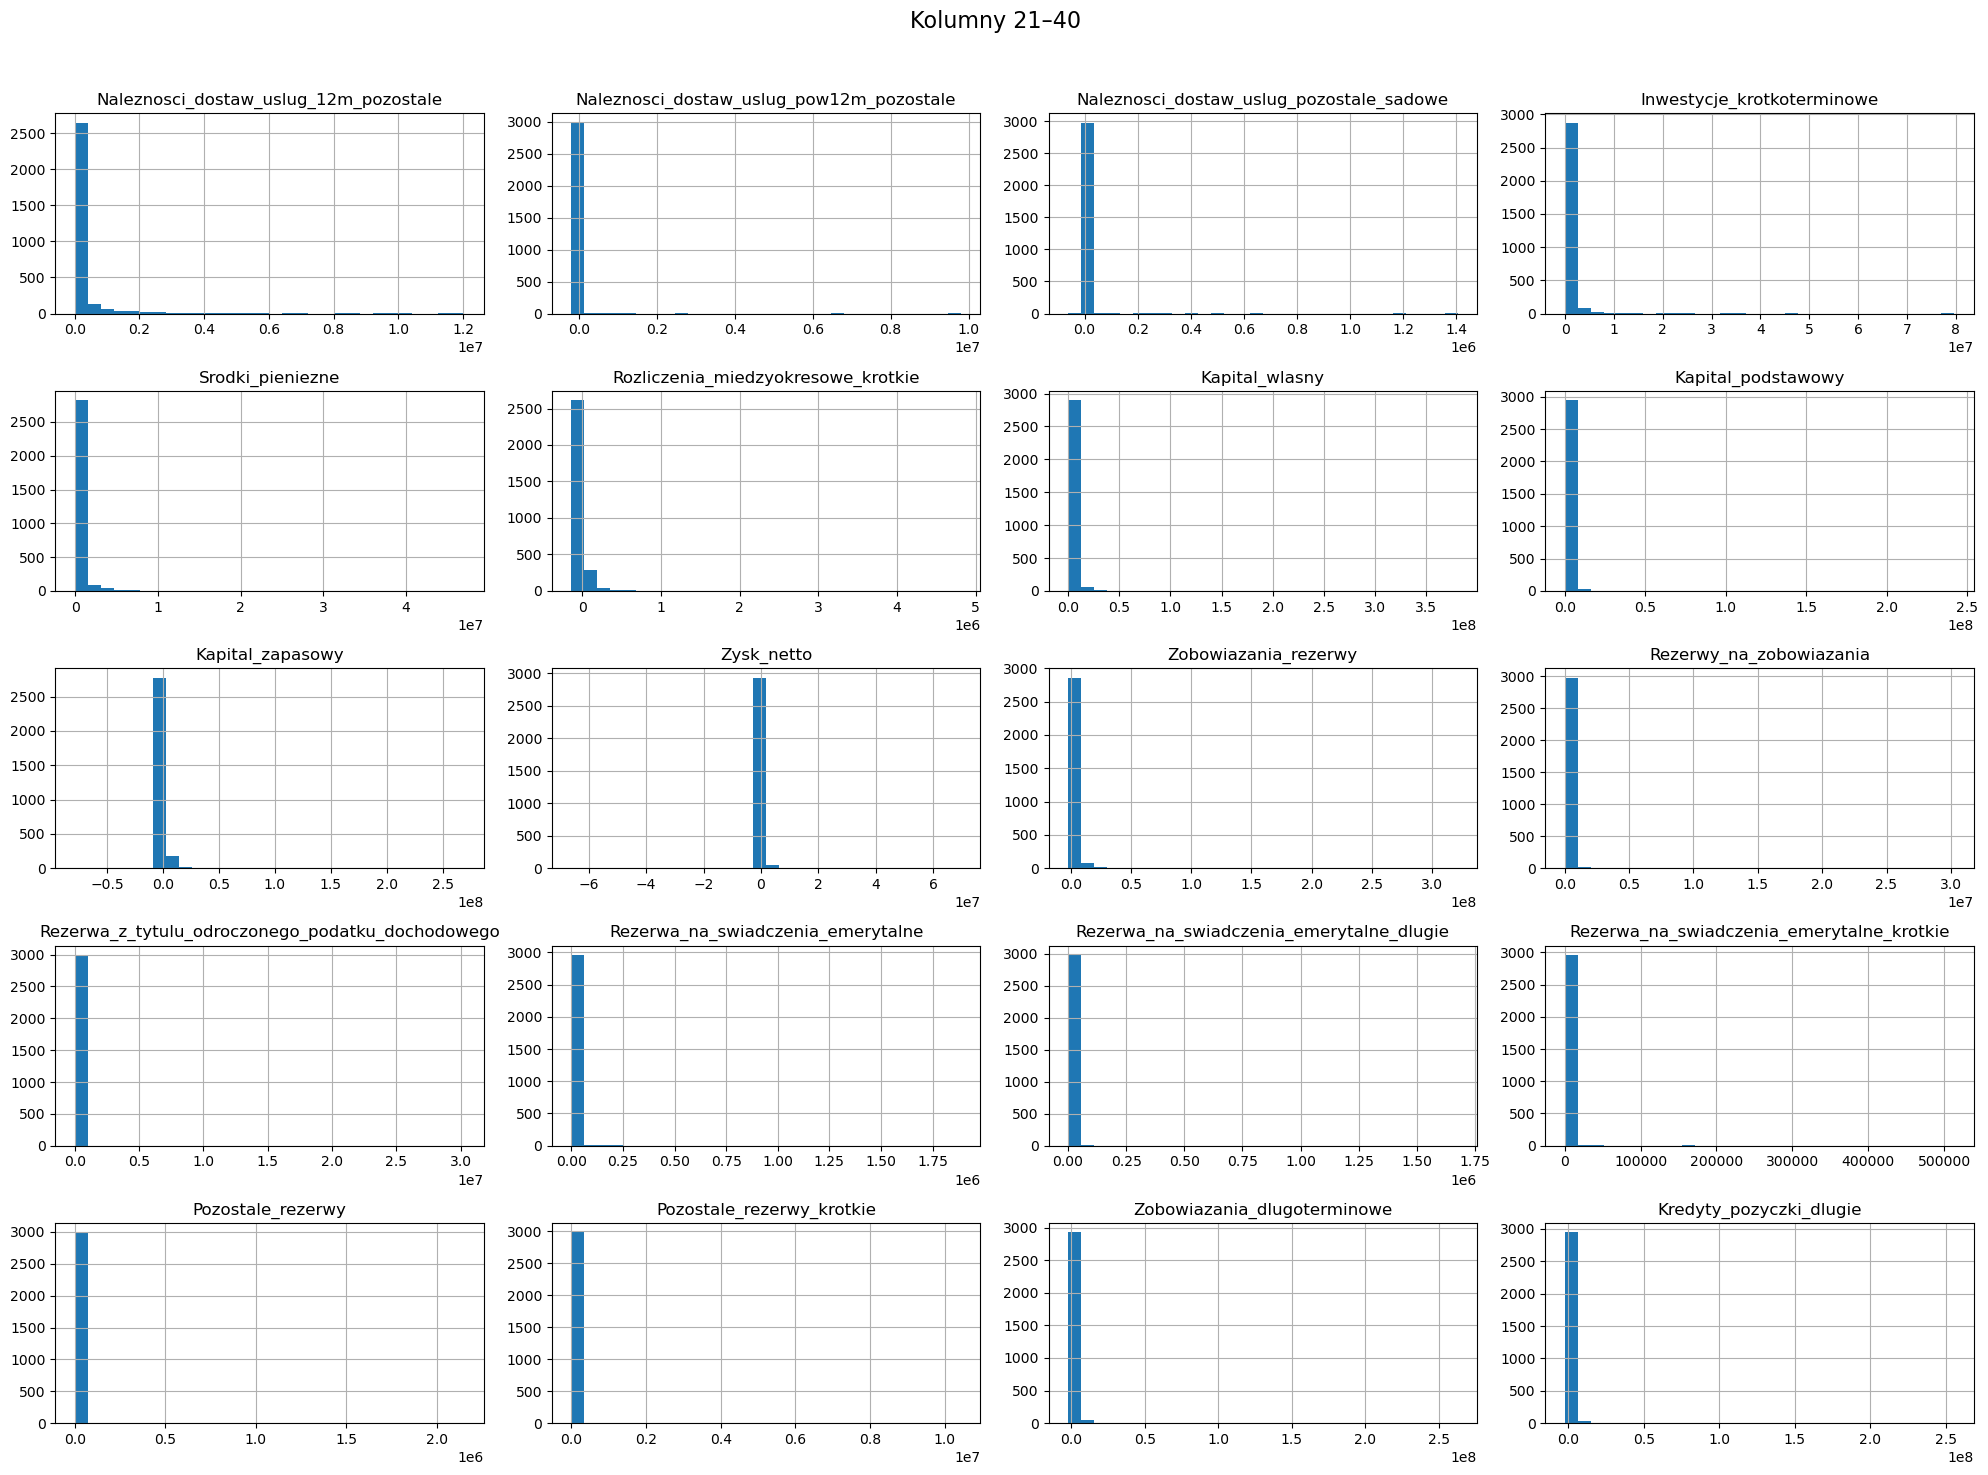

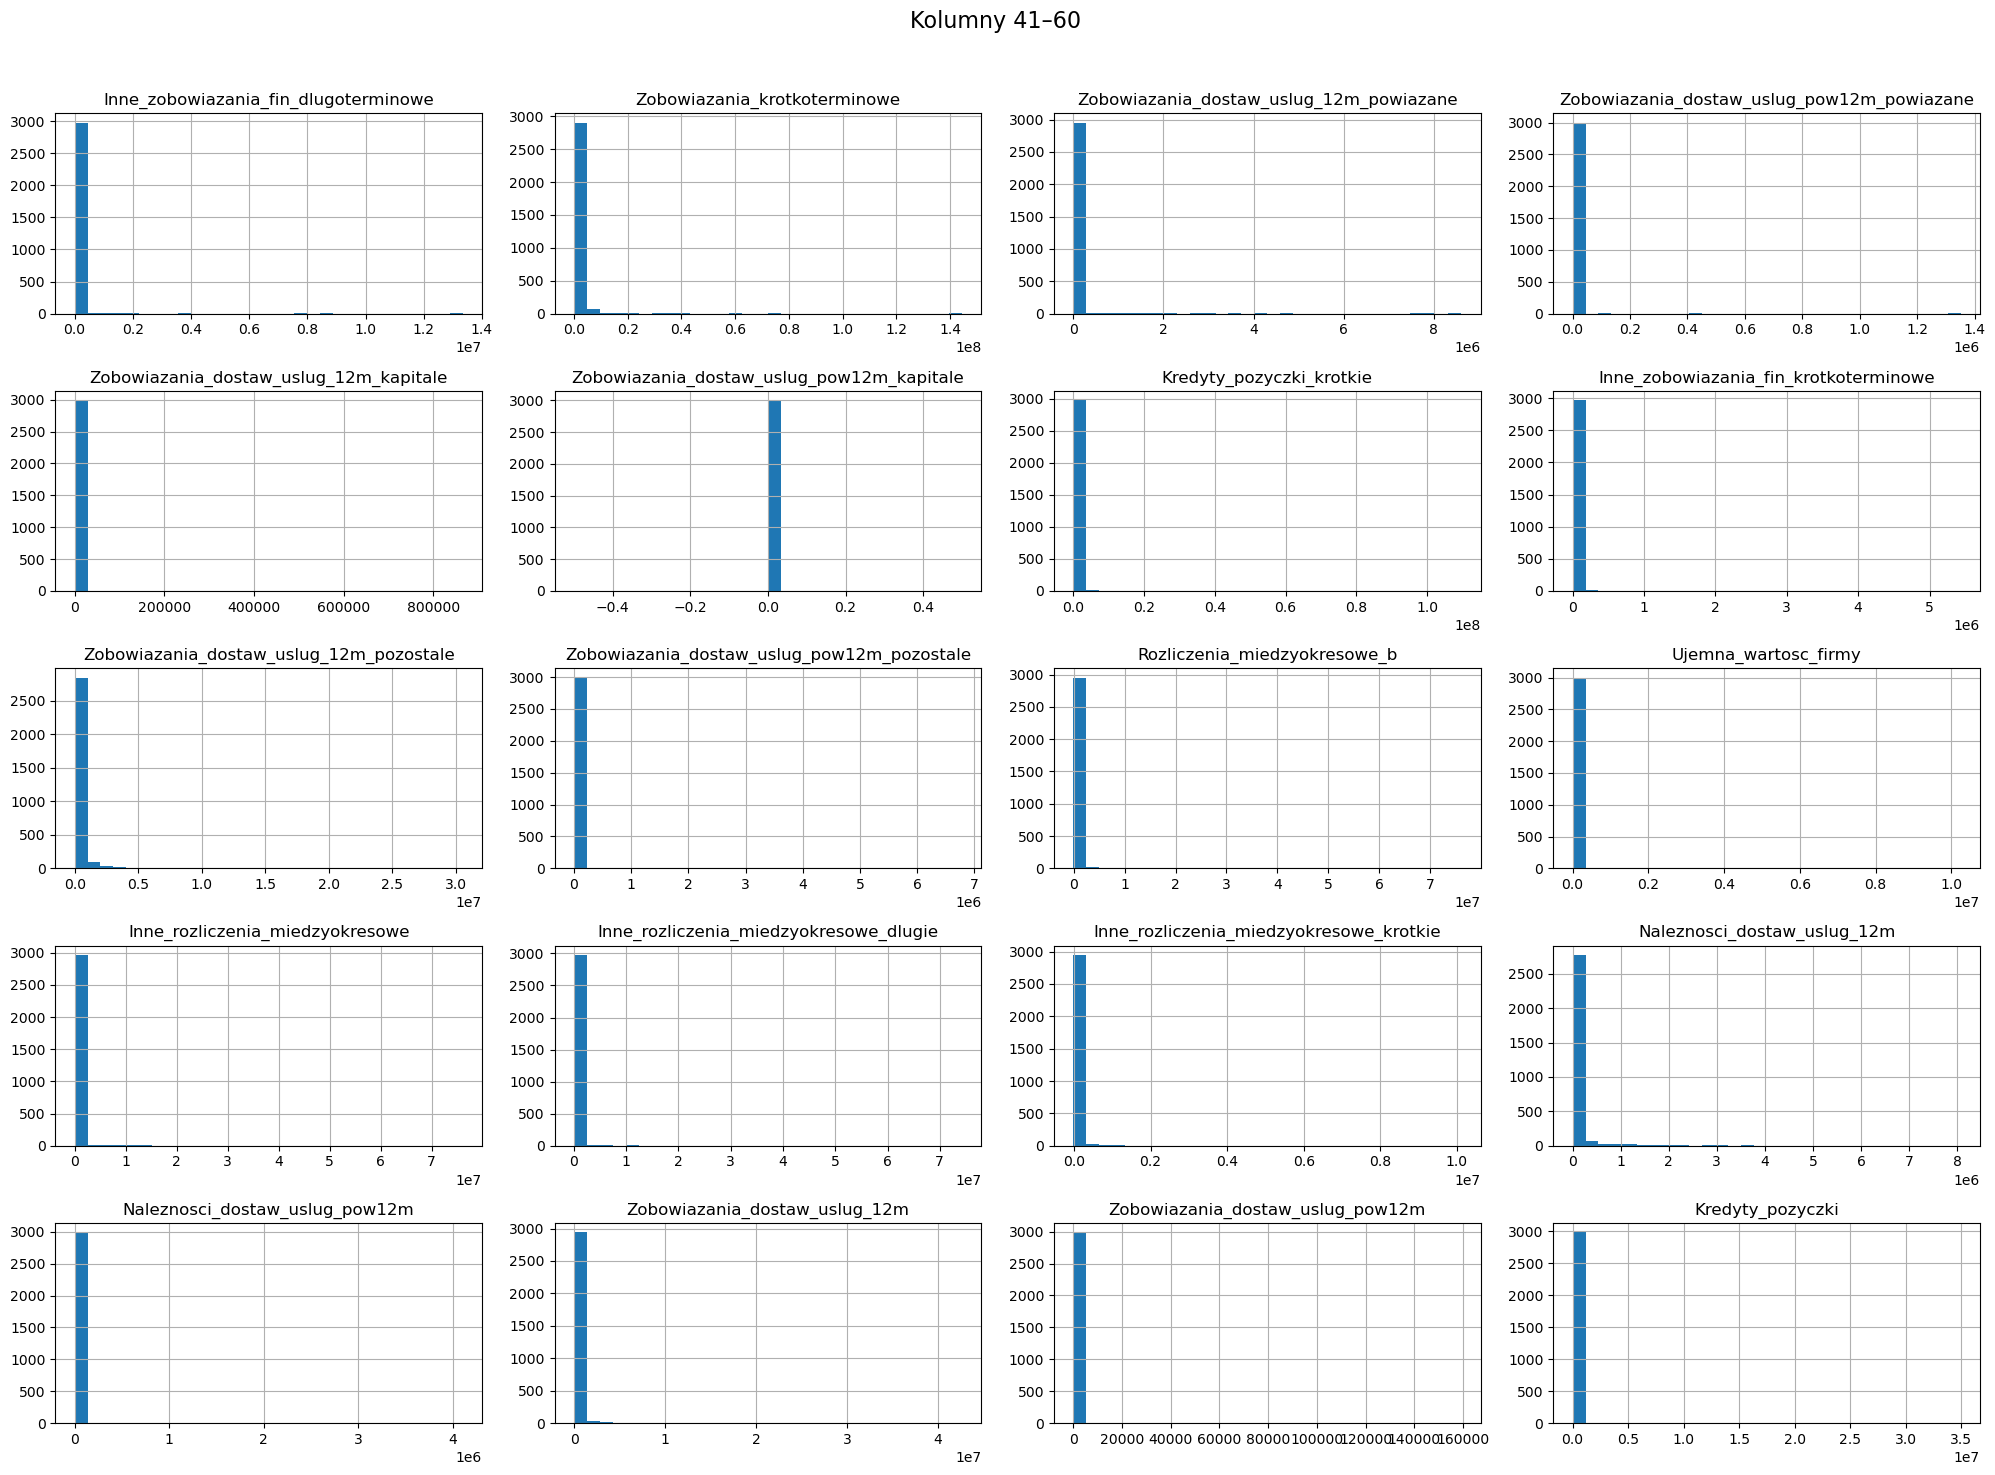

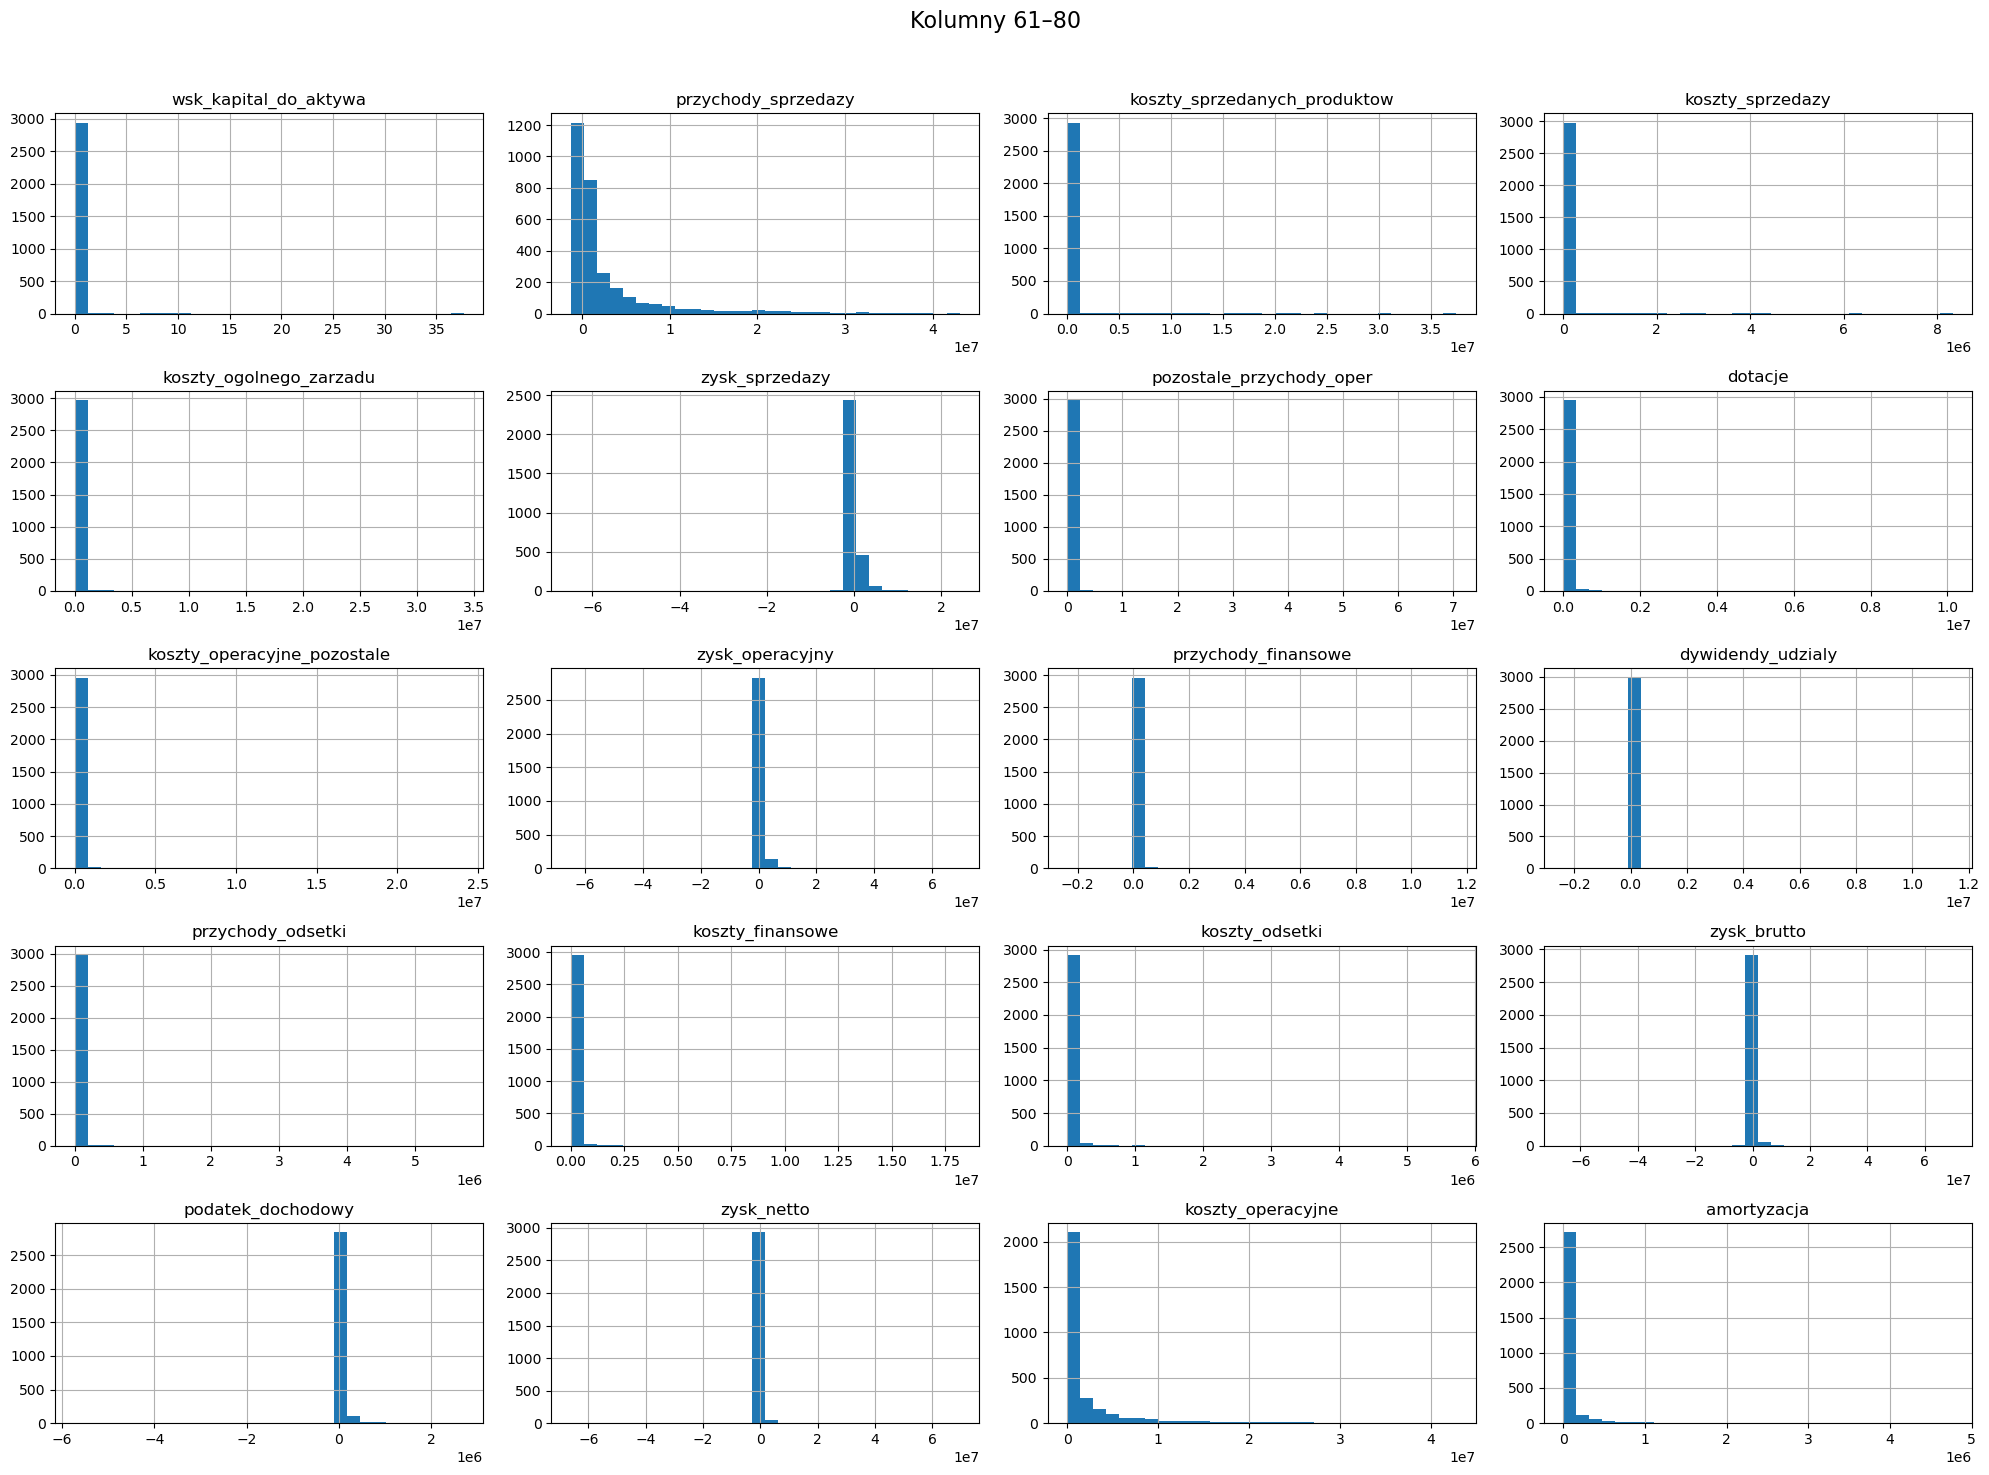

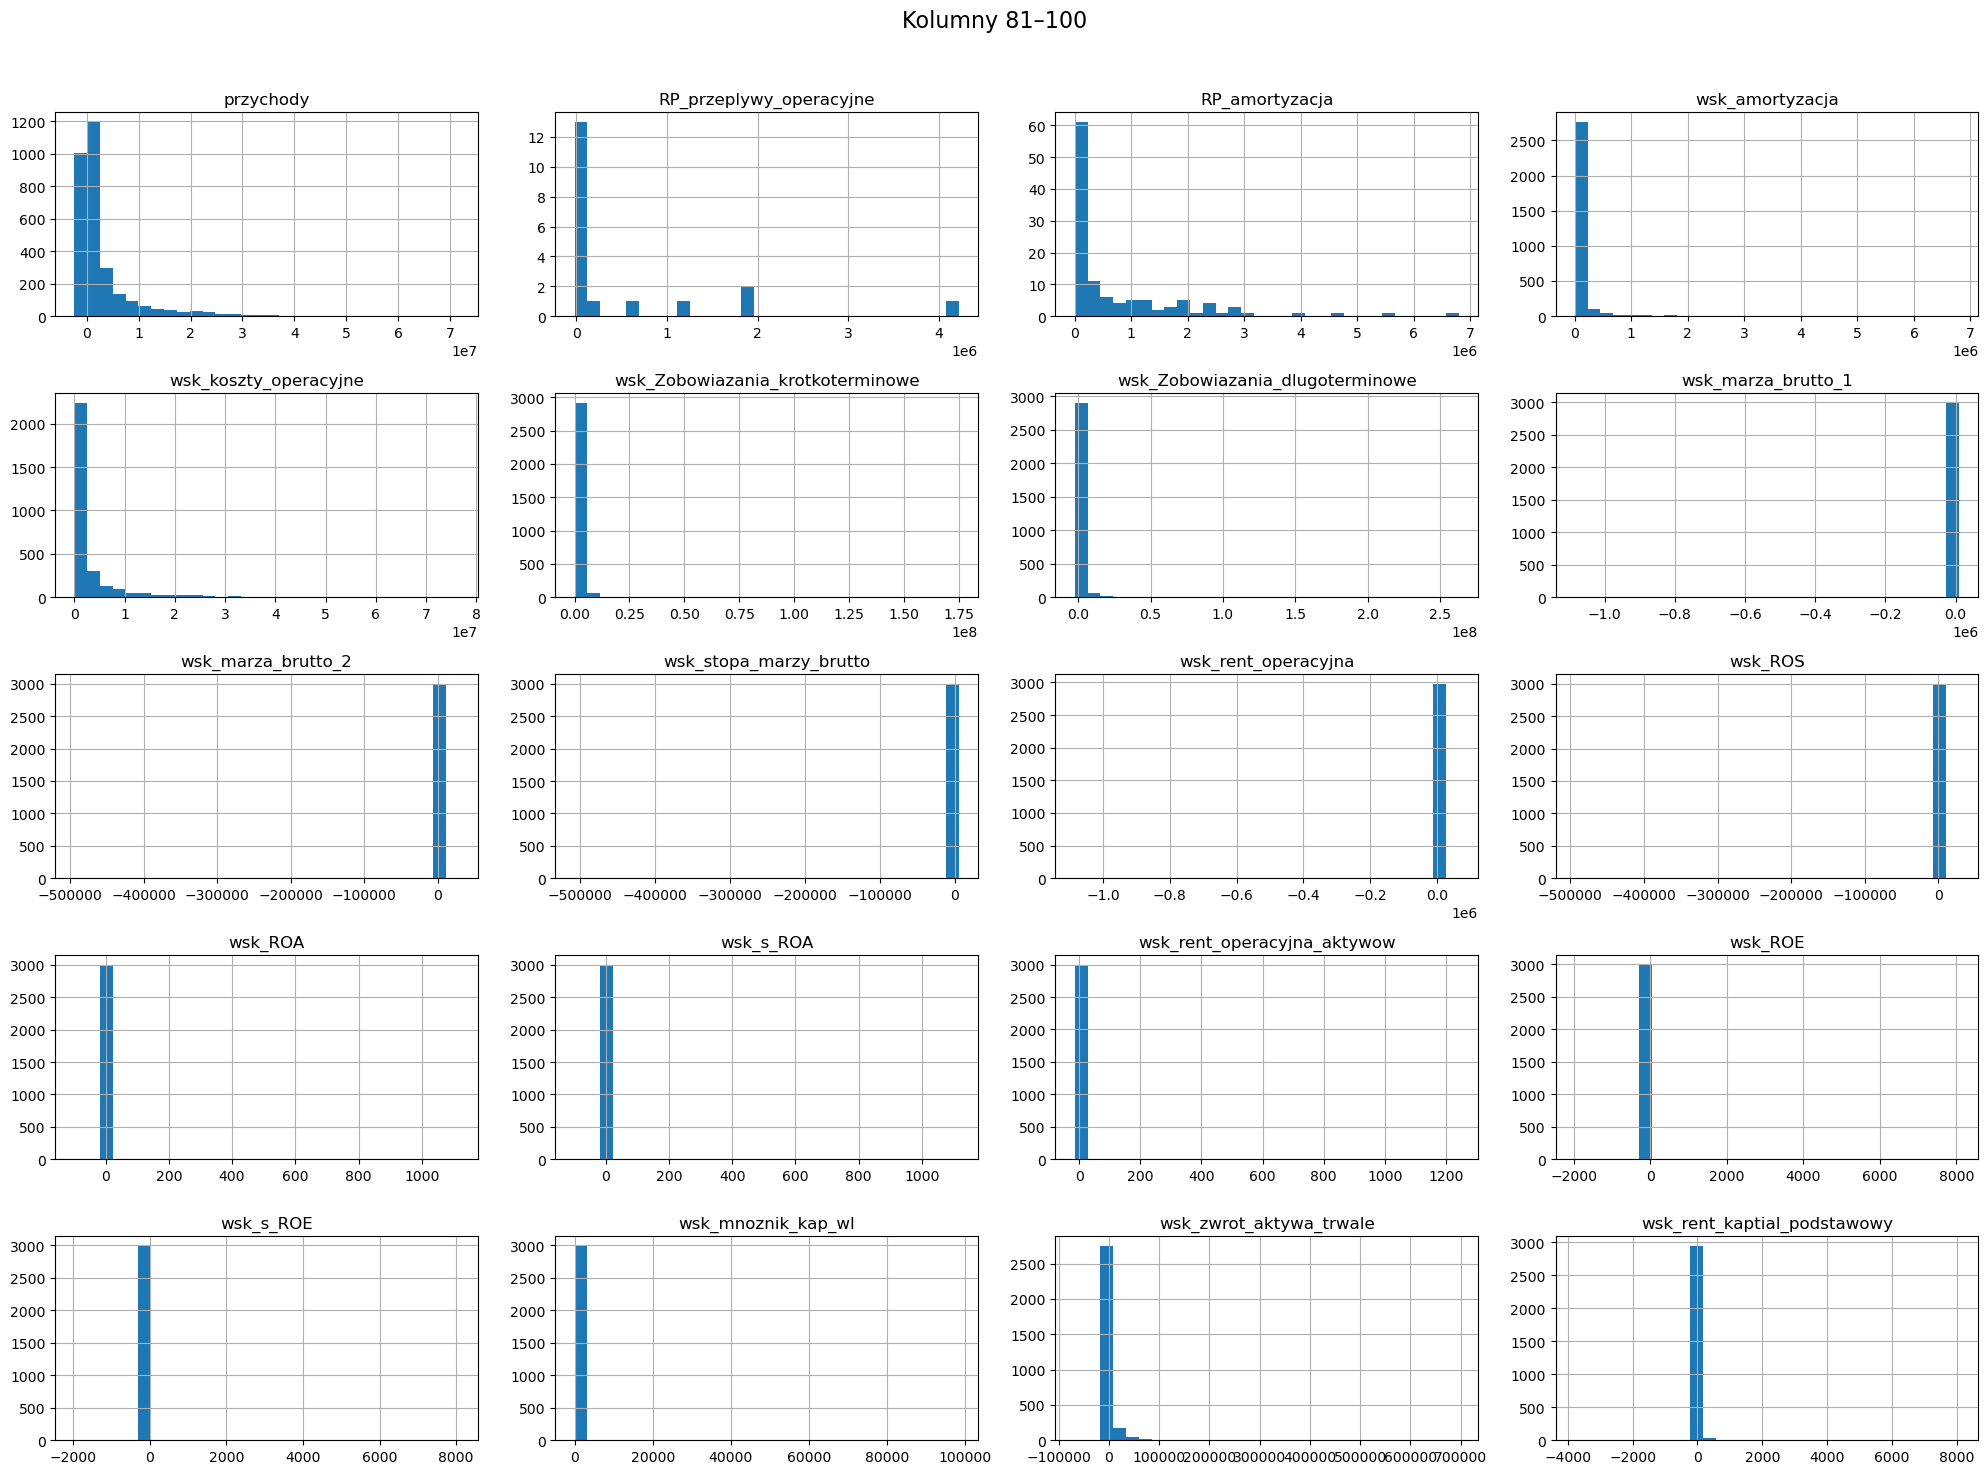

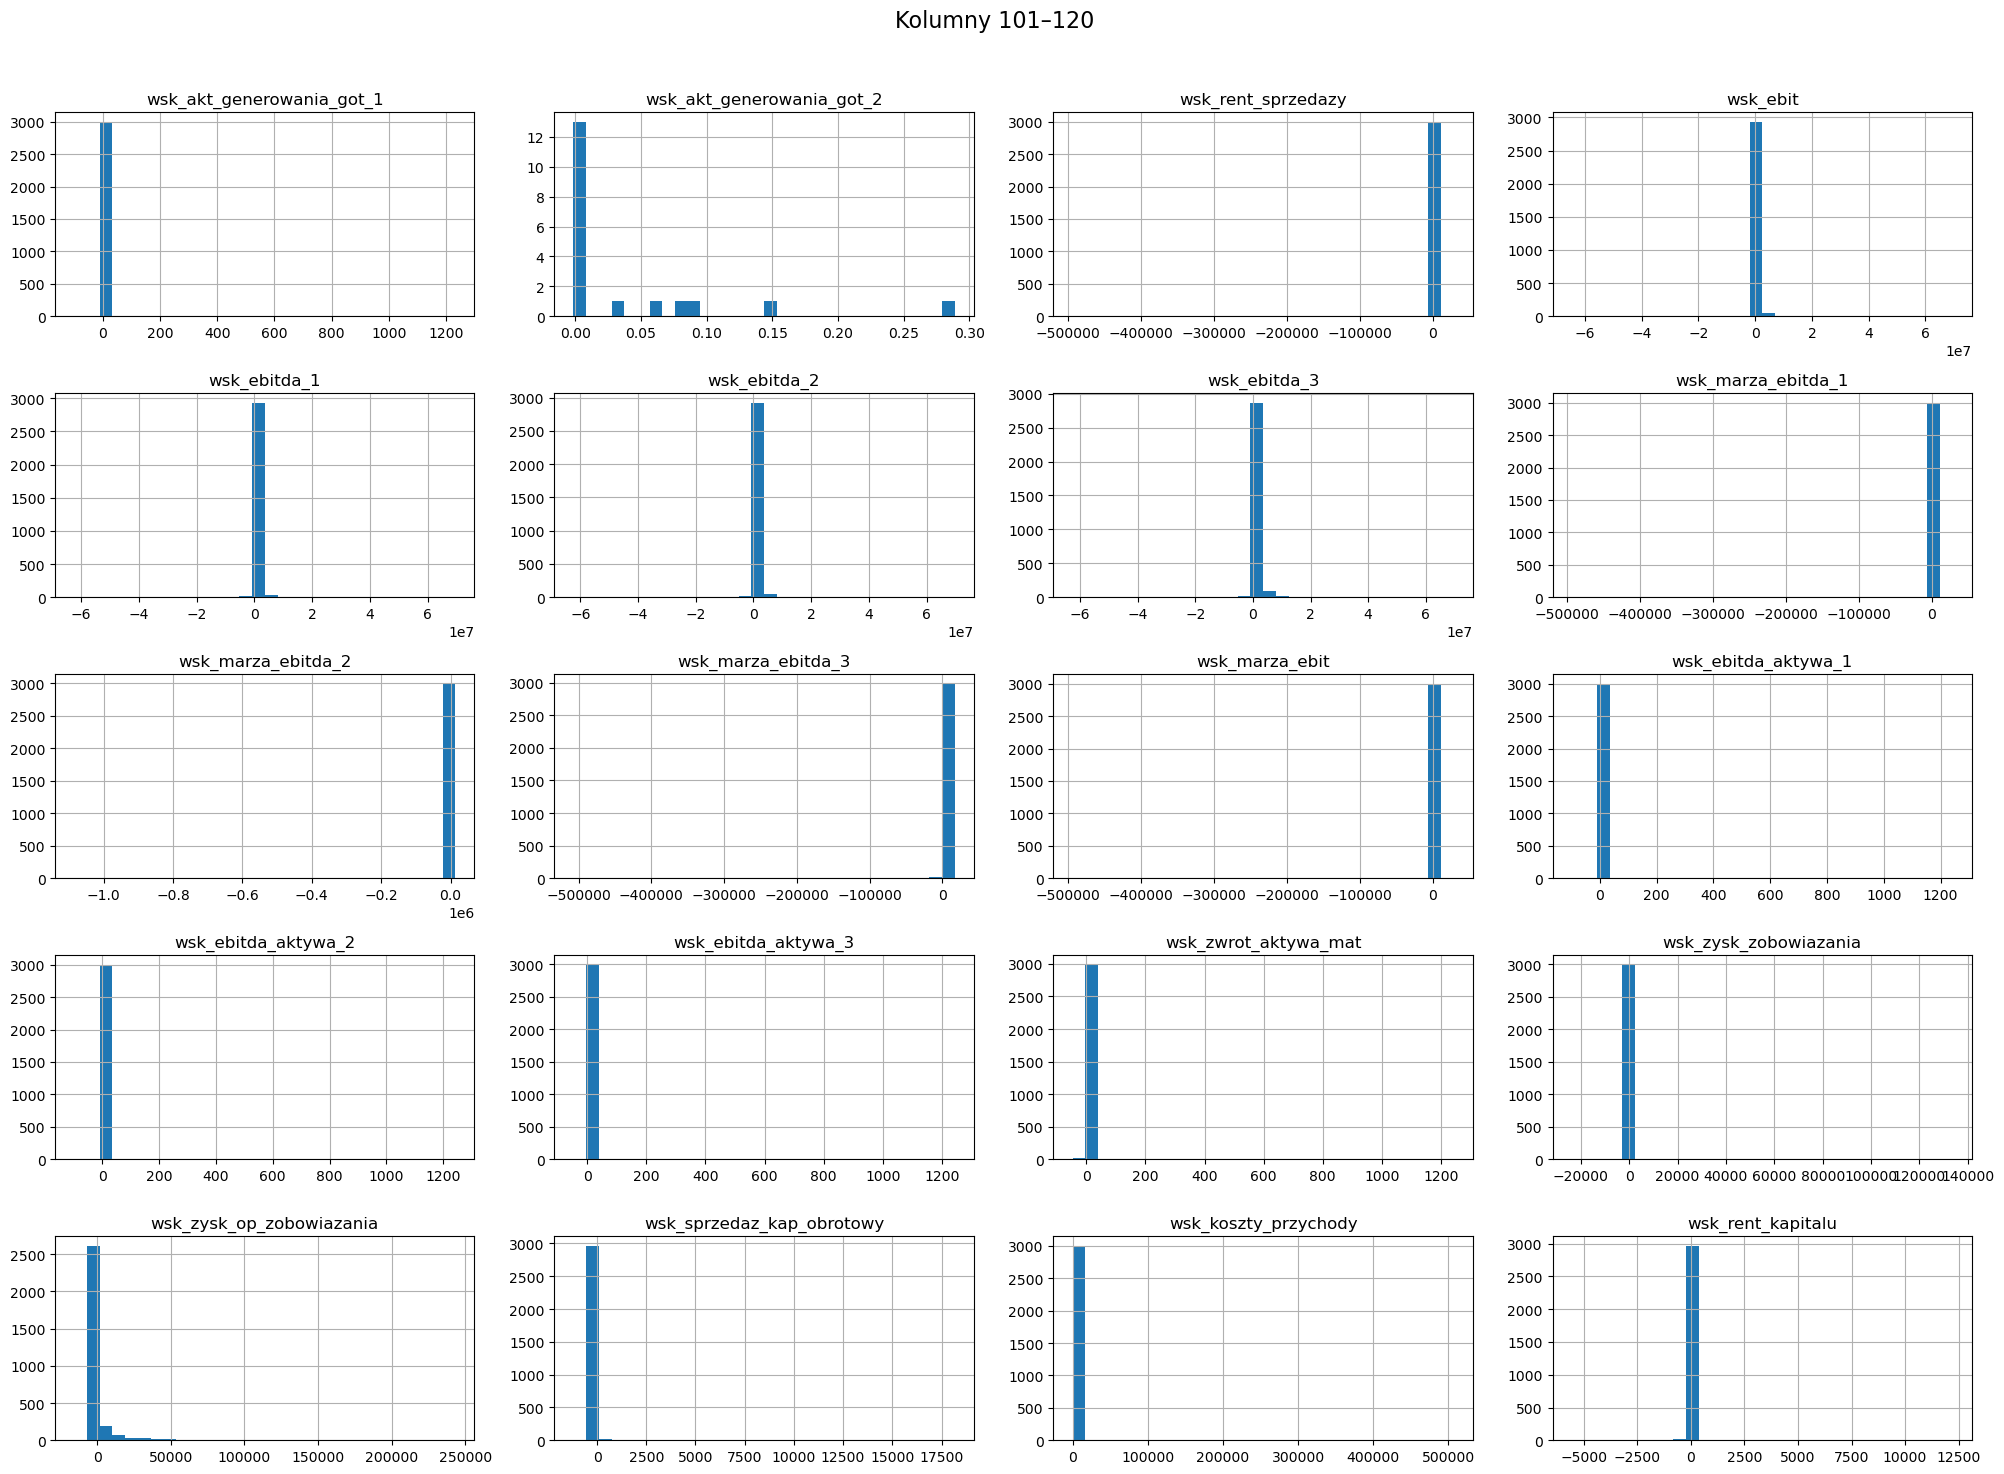

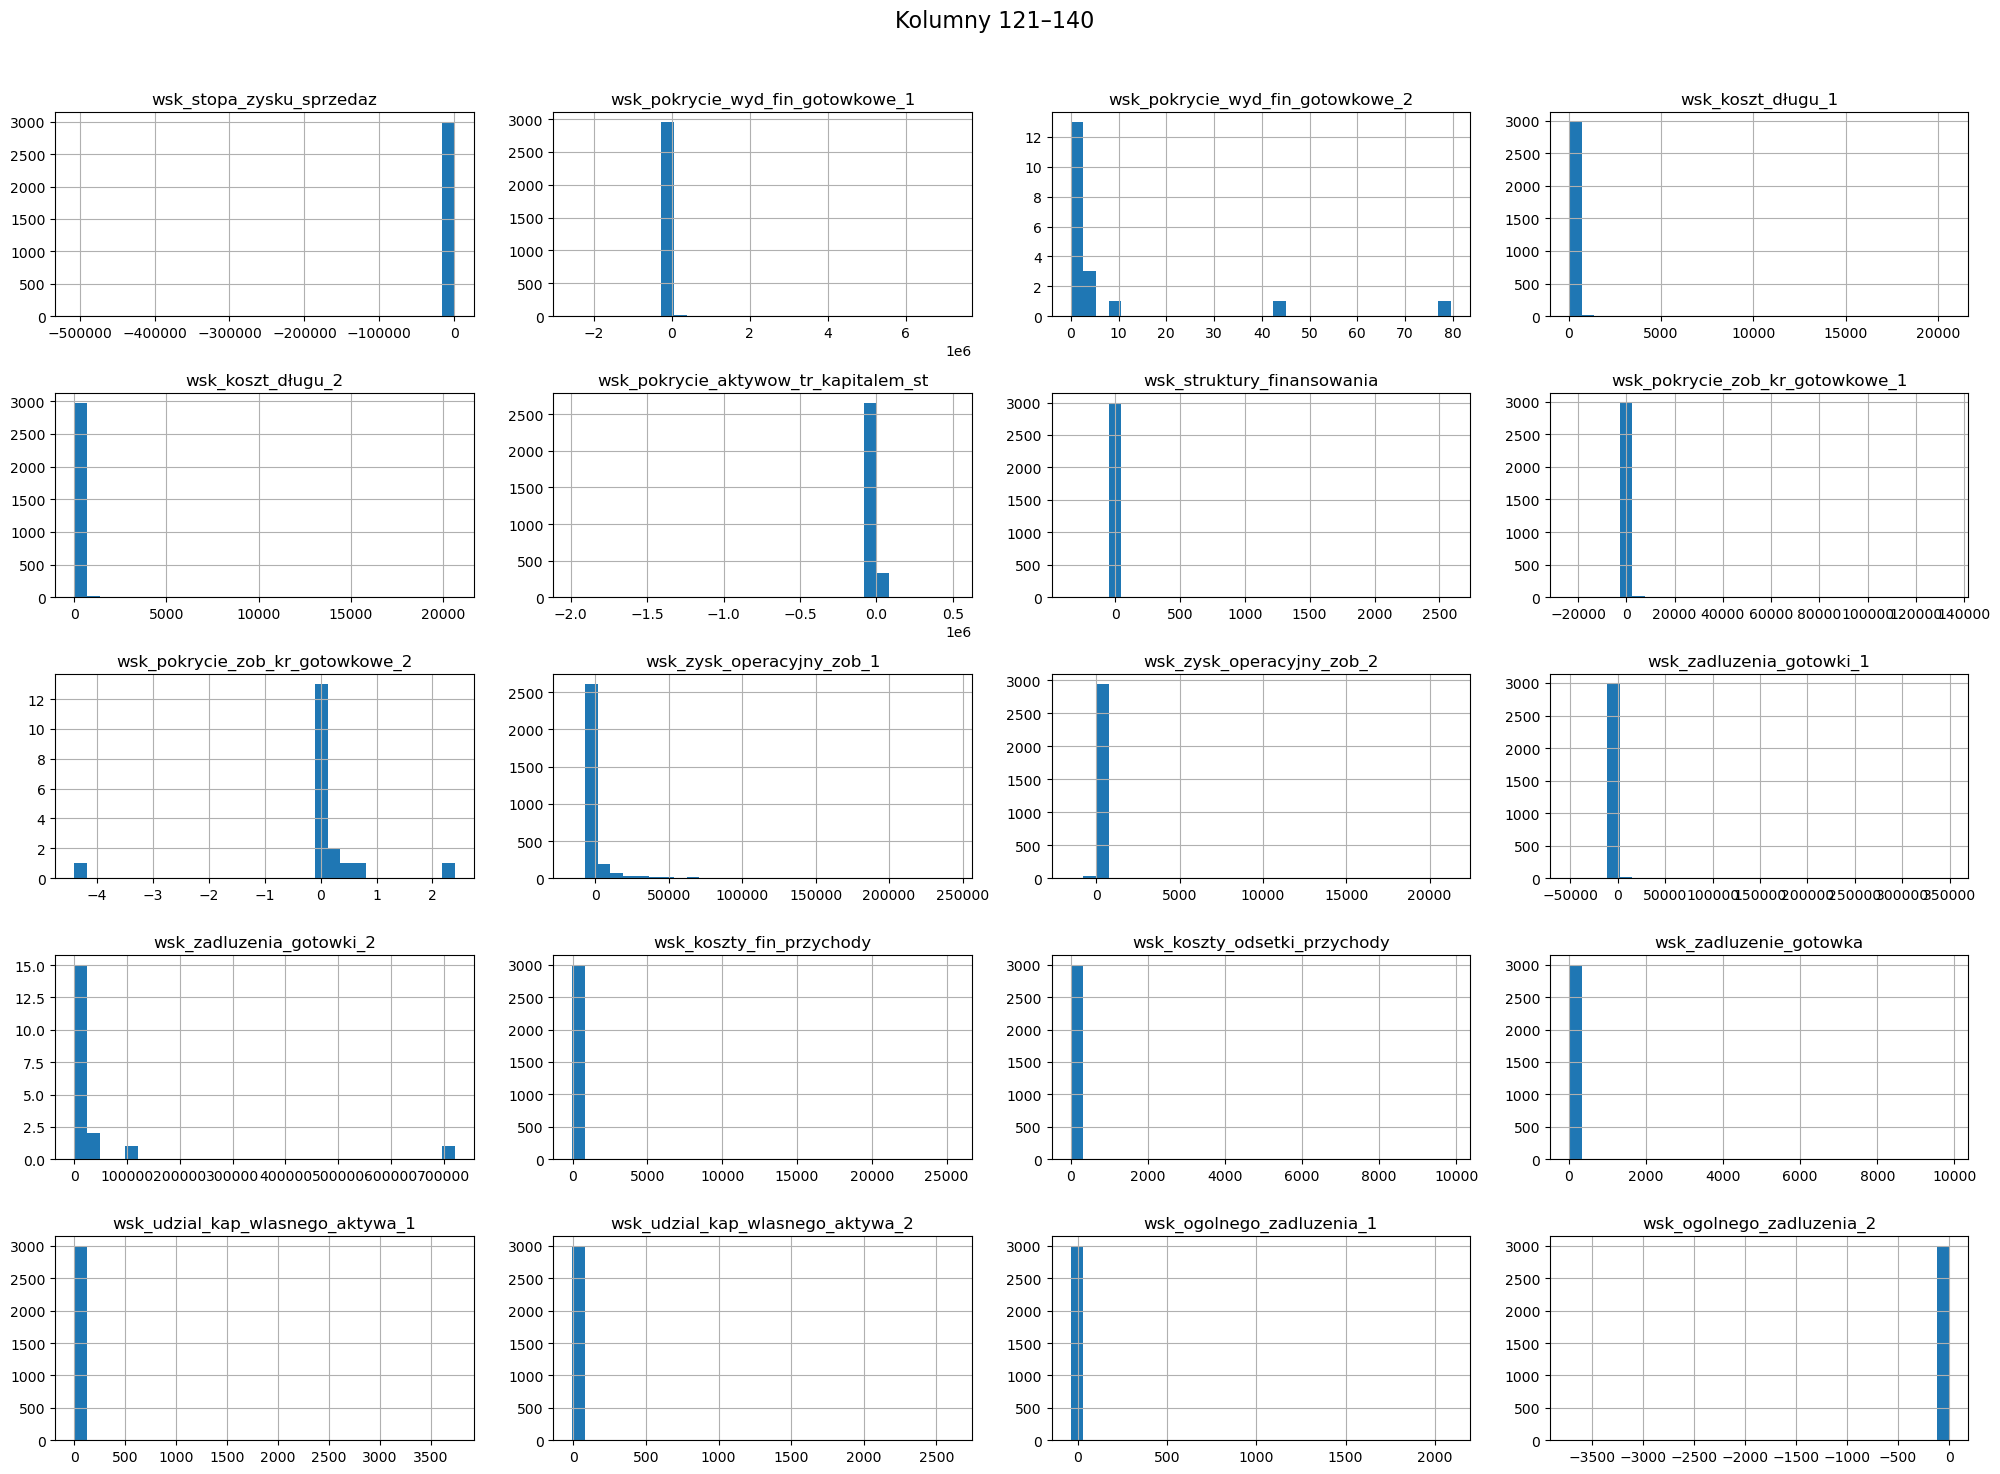

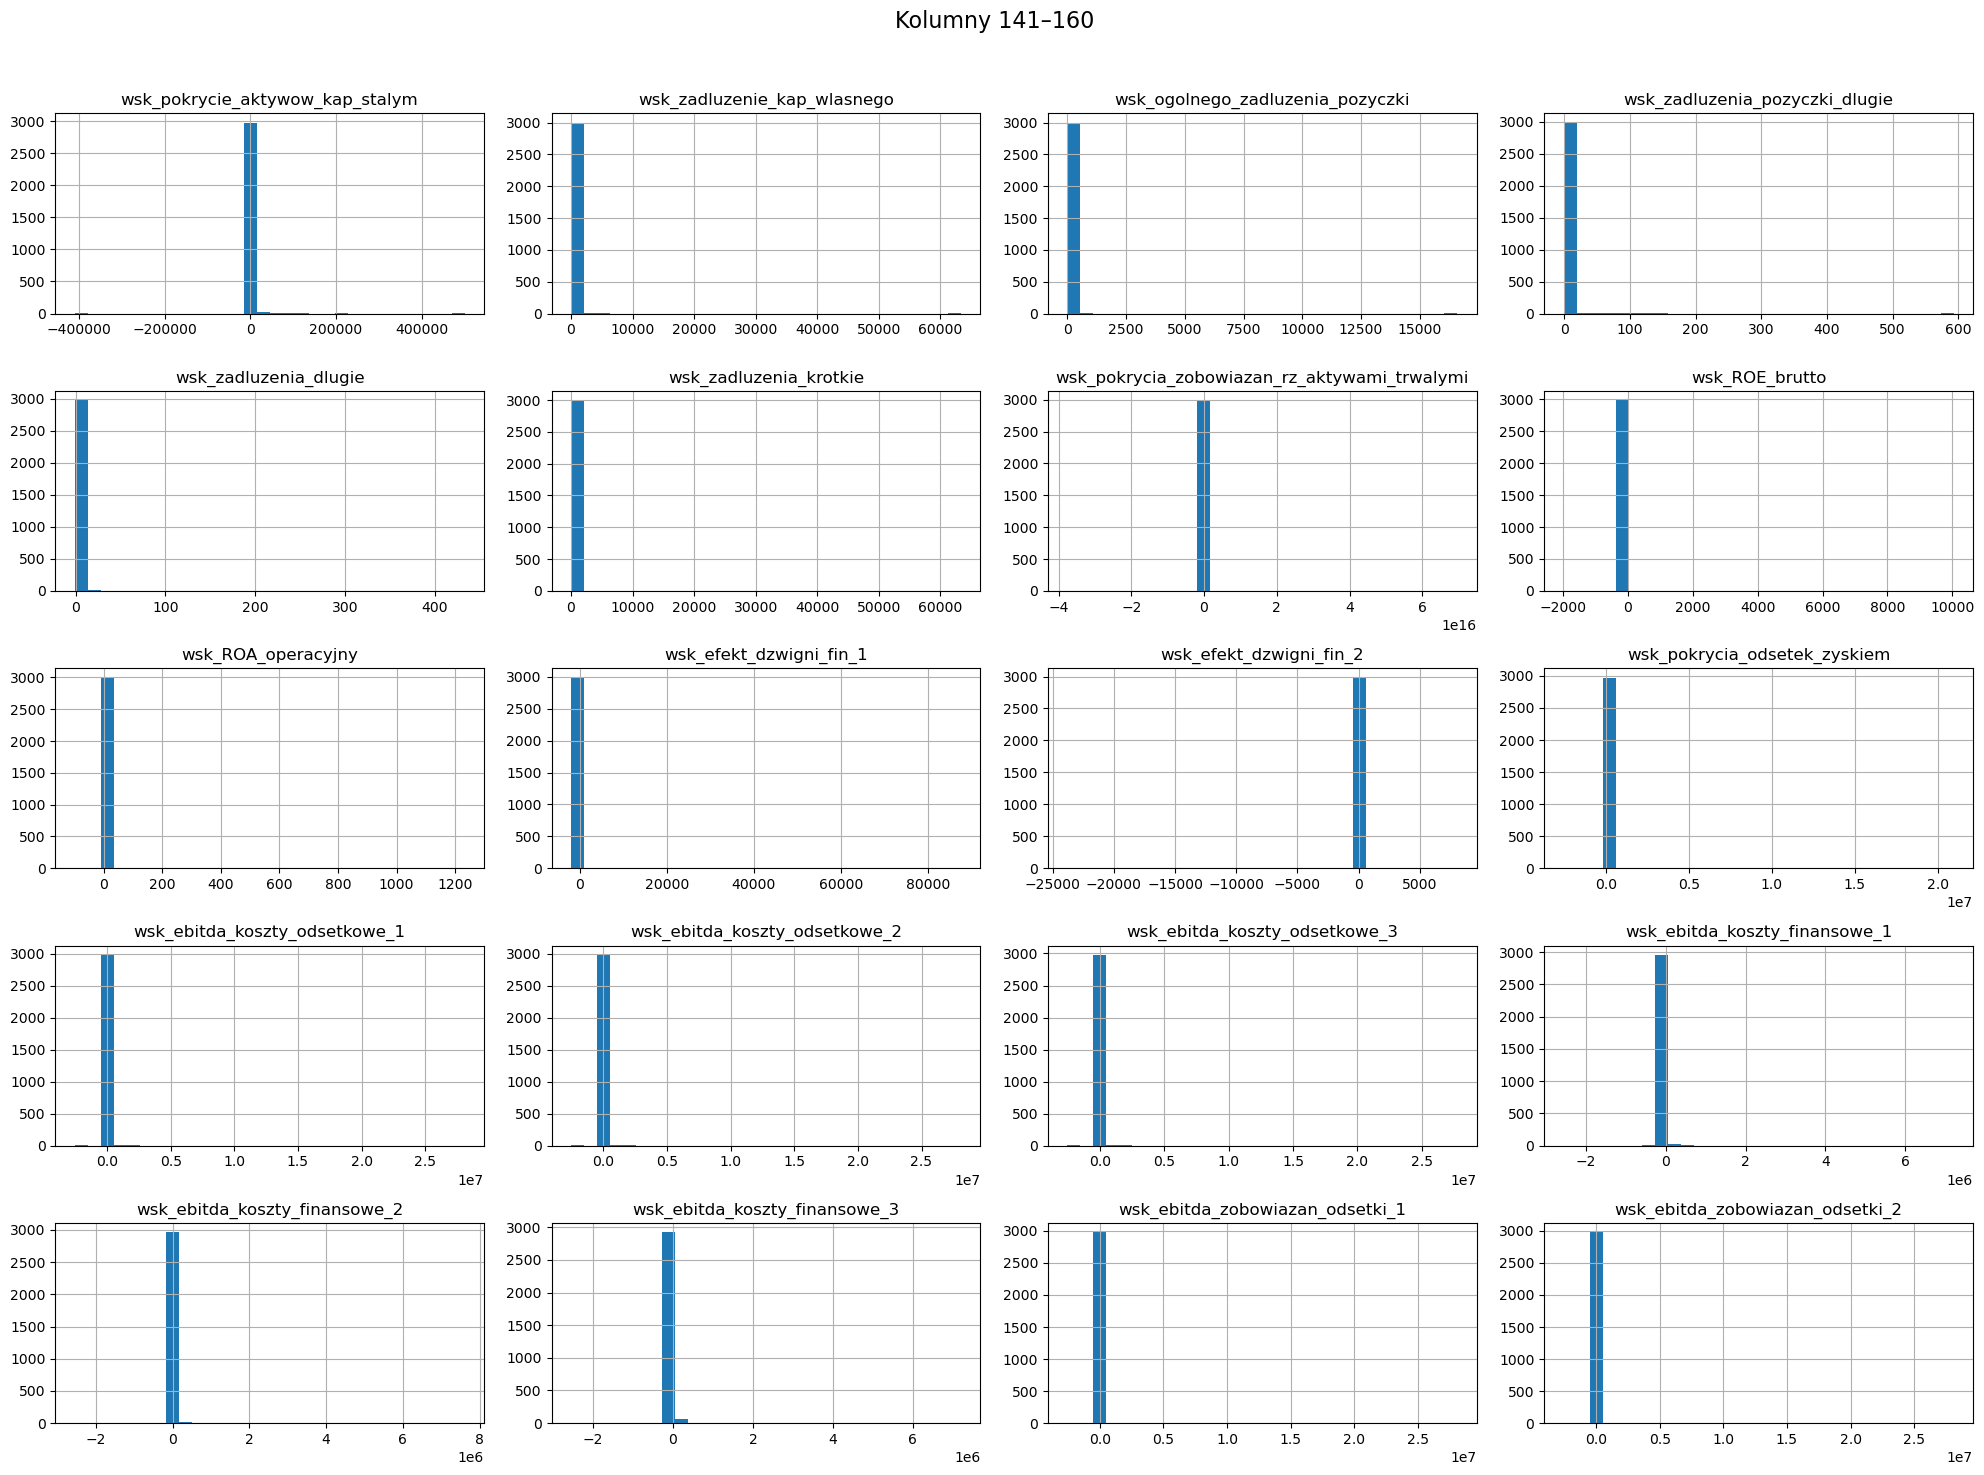

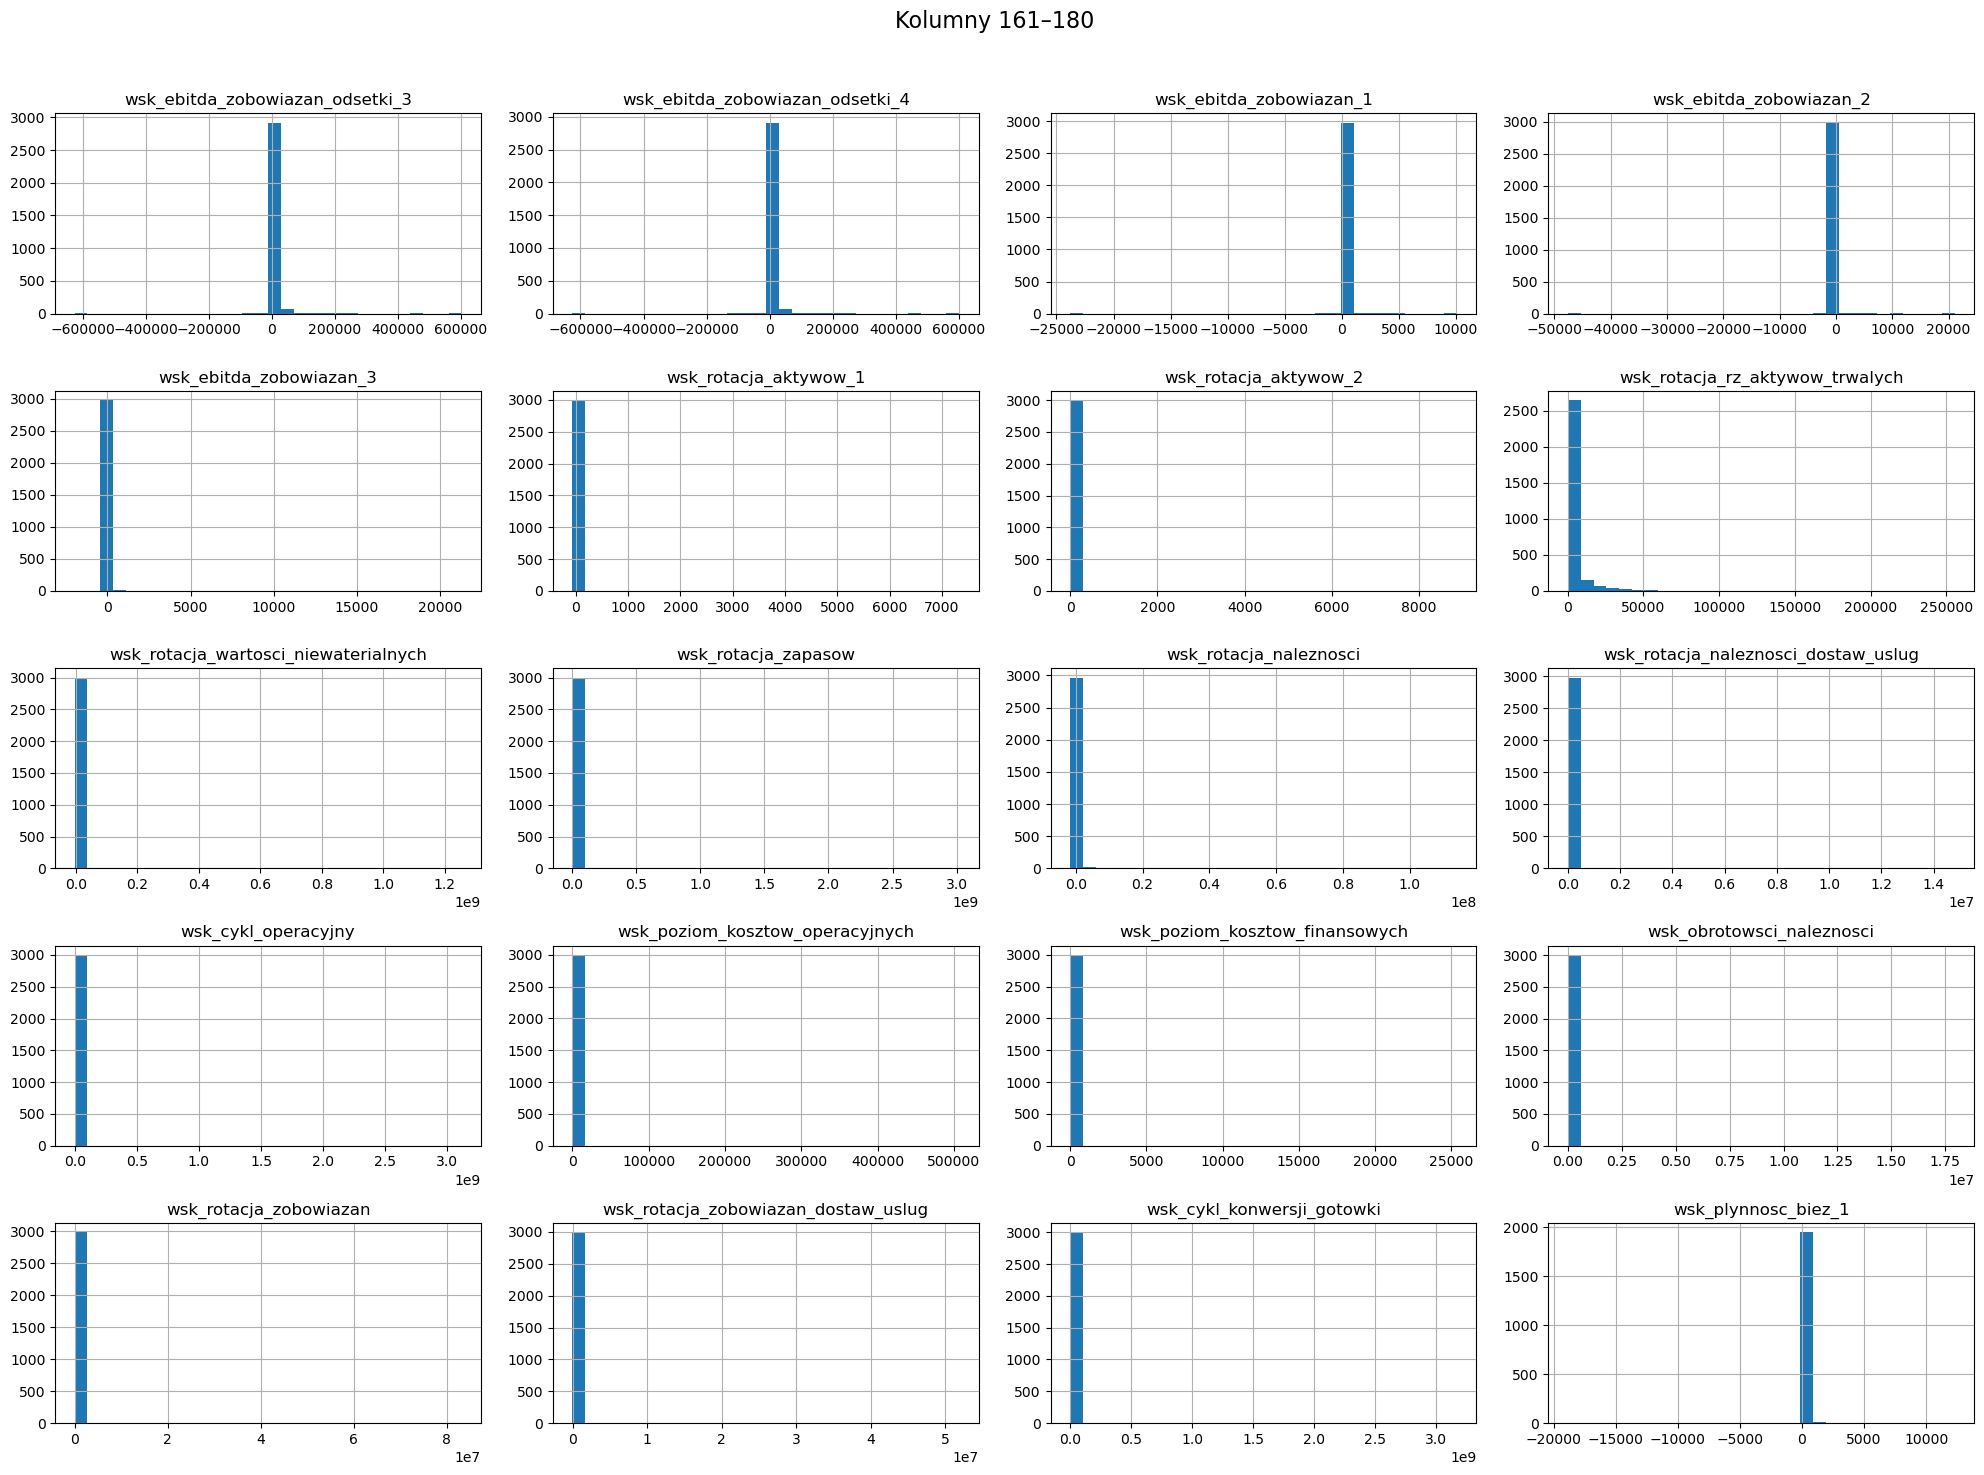

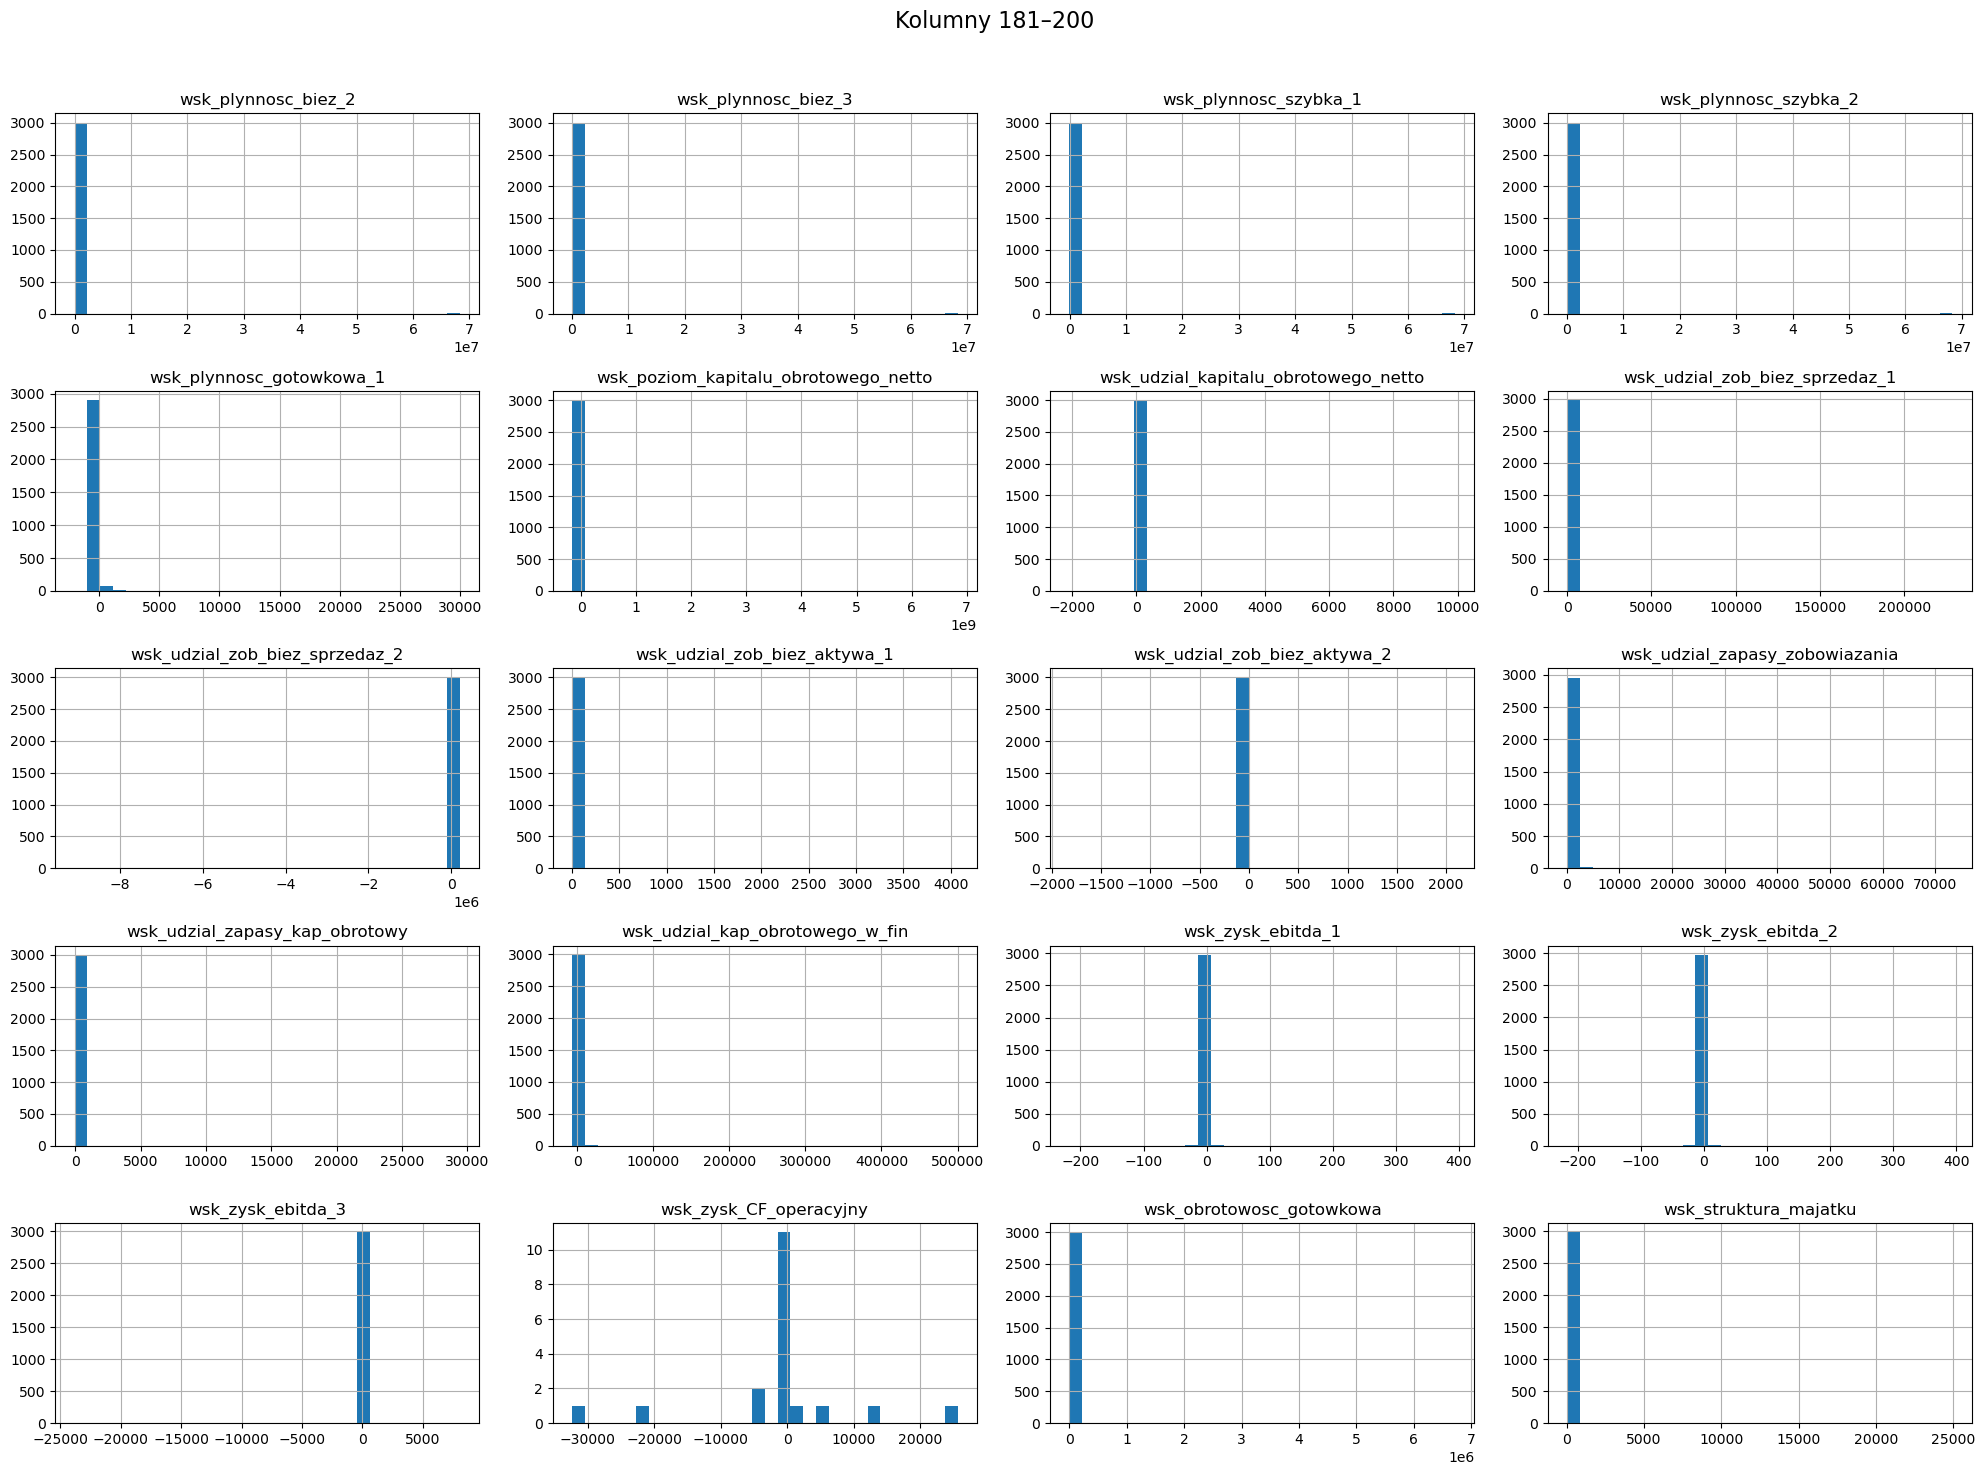

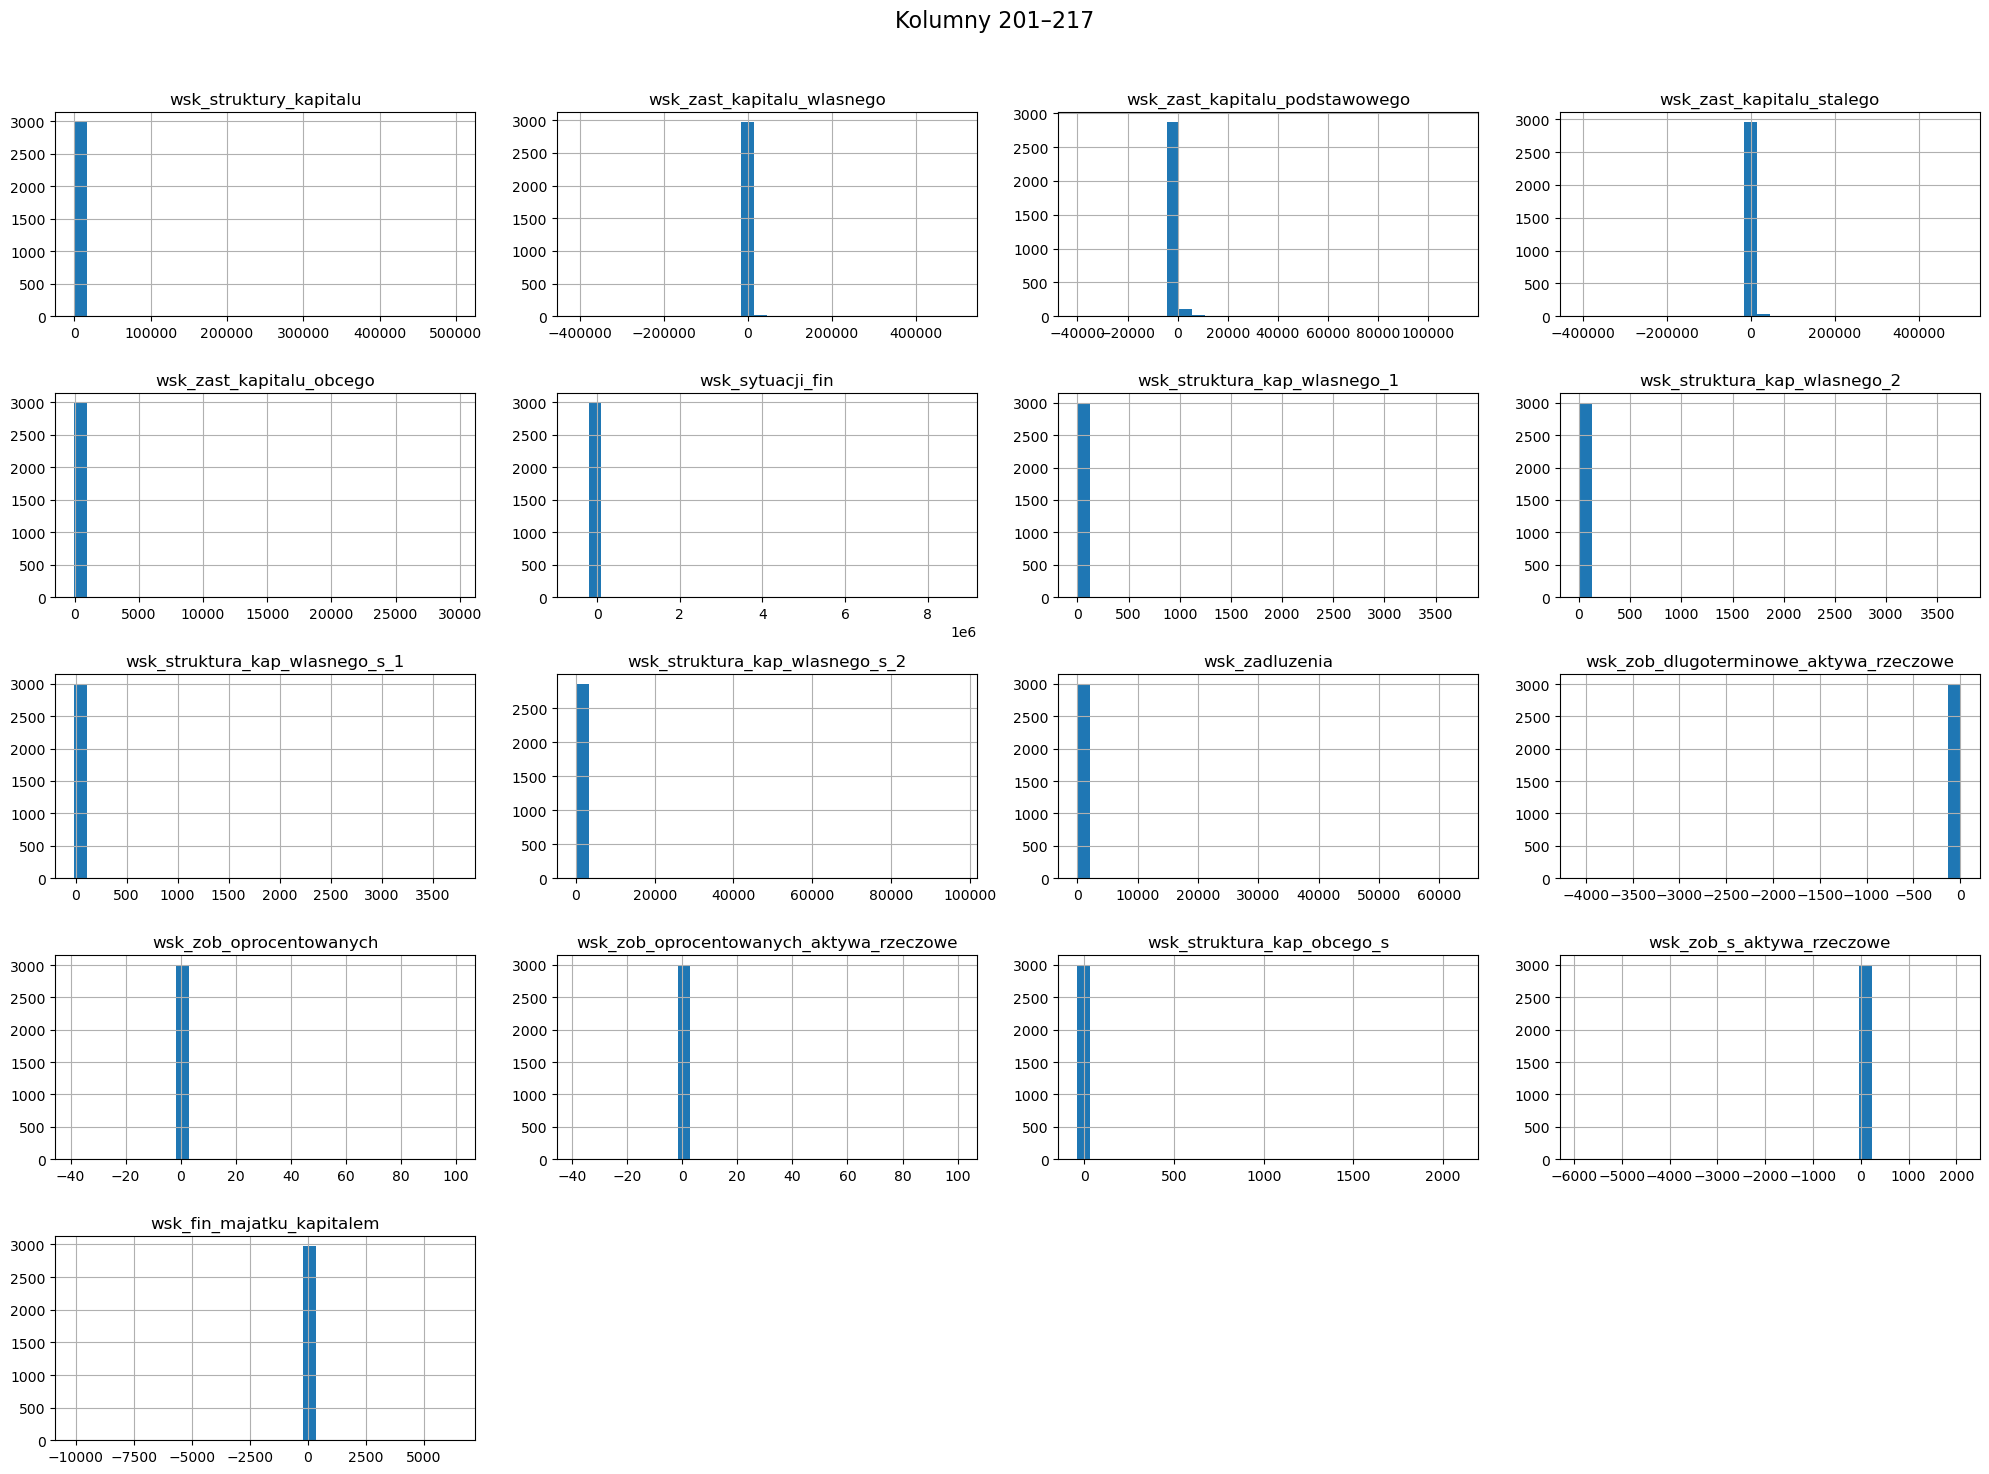

In [17]:
cols = num_cols.columns
batch_size = 20

for i in range(0, len(cols), batch_size):
    batch = cols[i:i+batch_size]
    num_cols[batch].hist(figsize=(20, 15), bins=30)
    plt.suptitle(f"Kolumny {i+1}–{i+len(batch)}", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

# Widać, że jest dużo zmiennych, które mają praktycznie same stałe wartości - w pipeline (na zbiorze train) je usuniemy (te, które będą miały wariancję bliską 0)
# Ponadto widać dużo outlierów - przytniemy je w pipelinie (mogą być problematyczne w modelu regresji)

<Axes: >

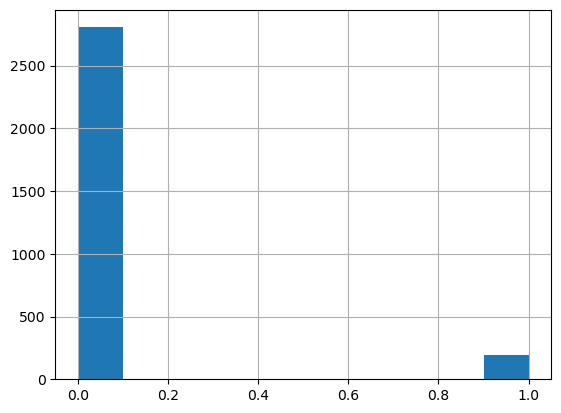

In [18]:
dane.default.hist()
# Mamy bardzo niezbalansowane dane - bardzo duża przewaga wartości 0

# 2. Podział na train/test/validation

60%/20%/20%

Zbiór walidacyjny będzie potrzebny do kalibracji

In [19]:
X = dane.drop("default", axis=1)
target = dane["default"] #zmienna przechowujaca kolumne default

In [20]:
X_train, X_temp, y_train, y_temp = train_test_split(X, target, test_size=0.4, random_state=123)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=123)

In [21]:
X_train.info() #mamy 212 kolumn

<class 'pandas.core.frame.DataFrame'>
Index: 1800 entries, 847 to 1346
Columns: 212 entries, szczegolnaFormaPrawna_Symbol to wsk_fin_majatku_kapitalem
dtypes: float64(206), int64(4), object(2)
memory usage: 2.9+ MB


# 3. Skorelowane zmienne kategoryczne

In [22]:
# to może być przed pipelinem ale już te inne korelacje są w pipelinie

In [23]:
# Obliczymy jaki procent wartości jest identyczny w obu kolumnach 
print((X_train['schemat_wsk_bilans'] == X_train['schemat_wsk_rzis']).mean())

# Dostajemy 97.8% - bardzo dużo, na tej podstawie możemy stwierdzić, że kolumny te niosą jednakową informację, a zatem
# możemy sie pozbyć jednej z nich 

0.9772222222222222


In [24]:
# Zbadamy jeszcze procent przypadków zgodnych z flagą default dla każdej kategorii osobno
print(pd.crosstab(X_train['schemat_wsk_bilans'], y_train , normalize='index') )

print(pd.crosstab(X_train['schemat_wsk_rzis'], y_train, normalize='index') )

# Mówi nam to czy zmienna silnie różnicuje ryzyko defaultu. Im większe różnice między kategoriami, tym bardziej 
# predykcyjna jest zmienna.
# Zmienne słabo różnicują ryzyko defaultu (dla każdej wartości mamy ryzyko mniej ięcej  5-7%), zatem zmienne nie 
# niosą zbyt dużo informacji, ale zostawimy jedną z nich aby została zmienna kategoryczna

default                    0         1
schemat_wsk_bilans                    
SFJIN               0.929748  0.070252
SFJMA               0.947917  0.052083
SFJMI               0.928713  0.071287
default                  0         1
schemat_wsk_rzis                    
SFJIN             0.929250  0.070750
SFJMA             0.948087  0.051913
SFJMI             0.930185  0.069815


In [25]:
cols_to_drop = ['schemat_wsk_rzis']

X_train = X_train.drop(columns=cols_to_drop)
X_val  = X_val.drop(columns=cols_to_drop)
X_test  = X_test.drop(columns=cols_to_drop)

# 4. Pipeline'y

## 1. Przycinanie outlierów

In [26]:
from sklearn.base import BaseEstimator, TransformerMixin

class OutlierCapper(BaseEstimator, TransformerMixin):
    #Przycinanie wartości odstających w kolumnach numerycznych za pomocą metody IQR
    def __init__(self, factor=1.5):
        self.factor = factor
        self.bounds_ = {} # Słownik do przechowywania granic dla każdej kolumny

    def fit(self, X, y=None):
        # Dopasowanie (nauka) granic tylko na danych treningowych
        X_df = pd.DataFrame(X)
        self.bounds_ = {}
        for col in X_df.columns:
            Q1 = X_df[col].quantile(0.25)
            Q3 = X_df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - self.factor * IQR
            upper = Q3 + self.factor * IQR
            self.bounds_[col] = (lower, upper)
        return self

    def transform(self, X):
        # Stosowanie granic na danych treningowych lub testowych
        X_df = pd.DataFrame(X)
        X_transformed = X_df.copy()
        
        for col, (lower, upper) in self.bounds_.items():
            # Użycie funkcji clip()
            X_transformed[col] = X_transformed[col].clip(lower, upper)
            
        # Pipeline oczekuje tablicy NumPy, nie DataFrame
        return X_transformed.values

    def get_feature_names_out(self, input_features=None):
    # W OutlierCapper liczba kolumn się nie zmienia, więc zwraca nazwy, które otrzymał
        return input_features

In [27]:
# 2. Usuwanie kolumn o niskiej wariancji

class LowVarianceRemover(BaseEstimator, TransformerMixin):
    # Usuwanie kolumn, których wariancja na zbiorze treningowym jest poniżej progu.
    def __init__(self, min_var=1e-5):
        self.min_var = min_var
        self.features_to_keep_ = [] # Lista kolumn do zachowania

    def fit(self, X, y=None):
        # Nauka, które kolumny mają wystarczającą wariancję
        X_df = pd.DataFrame(X)
        variances = X_df.var()
        
        # Zachowaj kolumny, których wariancja >= próg
        self.features_to_keep_ = variances[variances >= self.min_var].index.tolist()
        return self

    def transform(self, X):
        # Stosowanie selekcji kolumn
        X_df = pd.DataFrame(X)
        
        # Filtrowanie kolumny do transformacji (na wypadek, gdyby X_test miało dodatkowe kolumny)
        cols_to_transform = [col for col in self.features_to_keep_ if col in X_df.columns]
        
        # Pipeline oczekuje tablicy NumPy
        return X_df[cols_to_transform].values

    def get_feature_names_out(self, input_features=None):
        return np.asarray(self.features_to_keep_)

In [28]:
# 3. Usuwanie kolumn silnie skorelowanych

class HighCorrelationRemover(BaseEstimator, TransformerMixin):
    # Usuwa z pary silnie skorelowanych cech tę, która ma mniejszą wariancję.
    def __init__(self, threshold=0.9):
        self.threshold = threshold
        self.features_to_keep_ = None

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X)
        corr = X_df.corr().abs()
        
        cols_to_drop = set() 
        all_cols = X_df.columns
        
        # Pętla po górnym trójkącie macierzy korelacji
        for i in range(len(all_cols)):
            for j in range(i + 1, len(all_cols)):
                col_i = all_cols[i]
                col_j = all_cols[j]
                
                # Sprawdzamy, czy korelacja przekracza próg
                if corr.iloc[i, j] > self.threshold:
                    # Liczymy wariancję dla obu kolumn
                    var_i = X_df[col_i].var()
                    var_j = X_df[col_j].var()
                    
                    # Dodajemy do listy do usunięcia tę o mniejszej wariancji
                    if var_i < var_j:
                        cols_to_drop.add(col_i)
                    else:
                        cols_to_drop.add(col_j)
                        
        # Ostateczna listę cech do zachowania
        self.features_to_keep_ = [col for col in all_cols if col not in cols_to_drop]
        
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X)
        
        X_transformed = X_df[self.features_to_keep_]
        
        return X_transformed.values

    def get_feature_names_out(self, input_features=None):
        return np.asarray(self.features_to_keep_)

In [29]:
# 5. Usuwanie kolumn silnie skorelowanych z y (Default)

from sklearn.feature_selection import SelectFpr

# za pomocą SelectFpr przy tworzeniu modelu

In [30]:
# 6. Binning i WOE

from optbinning import BinningProcess

class WoEBinningTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.binning_process = None
        self.current_cols_ = None

    def fit(self, X, y=None):
        # Tworzenie DataFrame z tymczasowymi nazwami kolumn o poprawnej długości
        X_df = pd.DataFrame(X, columns=[f'col_{i}' for i in range(X.shape[1])])
        
        # Zapisanie tymczasowych nazw kolumn
        self.current_cols_ = X_df.columns.tolist()

        # Inicjalizacja BinningProcess z nowymi, tymczasowymi nazwami kolumn
        self.binning_process = BinningProcess(variable_names=self.current_cols_)
        self.binning_process.fit(X_df, y)
        return self

    def transform(self, X):
        # Użycie zapisanych nazw kolumn, aby utworzyć DataFrame o właściwej strukturze
        X_df = pd.DataFrame(X, columns=self.current_cols_)
        X_transformed = self.binning_process.transform(X_df, metric="woe")
        return X_transformed.values

    def get_feature_names_out(self, input_features=None):
        return np.asarray(self.current_cols_)

In [31]:
# Pipeline - preprocessing i tworzenie dwóch modeli
from sklearn.feature_selection import f_classif
from sklearn.feature_selection import VarianceThreshold

num_features = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_train.select_dtypes(include=['object']).columns


# Zmienne kategorycnze - dla XGBoost (Używa ONEHOT)
cat_pipeline_xgb = Pipeline(steps = [
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('one_hot', OneHotEncoder(handle_unknown='ignore', drop='first')),
])

# Zmienne kategoryczne - dla Regresji Logistycznej (Używa WoE)
cat_pipeline_lr = Pipeline(steps = [
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('woe_encode', WoEBinningTransformer())
])

# Zmienne numeryczne - XGBoost
numeric_transformer_xgb = Pipeline(steps=[
    ('low_var_remover', LowVarianceRemover(min_var=1e-5)),
    ('high_corr_remover', HighCorrelationRemover(threshold=0.95)),
    ('outlier_capper', OutlierCapper(factor=1.5)), 
    ('imputer', SimpleImputer(strategy='median')), 
    ('scaler', StandardScaler()),
])

# Zmienne numeryczne - Regresja logistyczna (z Binning/WoE)
numeric_transformer_lr = Pipeline(steps=[
    ('low_var_remover', LowVarianceRemover(min_var=1e-5)),
    ('high_corr_remover', HighCorrelationRemover(threshold=0.95)),
    ('outlier_capper', OutlierCapper(factor=1.5)), 
    ('imputer', SimpleImputer(strategy='median')),     
    ('scaler', StandardScaler()), 
])


# Preprocesor dla modelu XGBoost
preprocessor_xgb = ColumnTransformer(
    transformers=[
        ("numeric_preprocessing", numeric_transformer_xgb, num_features),
        ("categorical_preprocessing", cat_pipeline_xgb, categorical_features),
    ],
    remainder='passthrough'
)

# Preprocesor dla modelu Logistic Regression
preprocessor_lr = ColumnTransformer(
    transformers=[
        ("numeric_preprocessing", numeric_transformer_lr, num_features),
        ("categorical_preprocessing", cat_pipeline_lr, categorical_features),
    ],
    remainder='passthrough'
)


# 4. Tworzenie modeli (Pipeline)

# Pipeline dla XGBoost 
xgb_model = Pipeline(steps=[
    ('preprocessing', preprocessor_xgb),
    ('variance_filter', VarianceThreshold(threshold=0.0)), # w trakcie preprocessingu mogą powstać nowe stałe kolumny, więc je usuwam (bez tego wyskakuje error)
    ('stat_feature_selector', SelectFpr(score_func=f_classif, alpha=0.15)), #SelectFpr to wbudowana funkcja, usuwa kolumny skorelowane z targetem
    ('model', XGBClassifier(eval_metric='logloss', random_state=123))
])

# Pipeline dla Logistic Regression
lr_model = Pipeline(steps=[
    ('preprocessing', preprocessor_lr),
    ('variance_filter', VarianceThreshold(threshold=0.0)),
        ('stat_feature_selector', SelectFpr(score_func=f_classif, alpha=0.15)),
    ('model', LogisticRegression(random_state=123))]) 

# Trenowanie modelu XGBoost

In [32]:

scale_factor = (y_train == 0).sum() / (y_train == 1).sum() # pomoże z overfittingiem przy niezbalansowanych danych

param_grid_xgb = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [3, 4, 5, 6],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__min_child_weight': [10, 20, 30],
    'model__gamma': [0, 0.1, 0.5, 1],
    'model__subsample': [0.7, 0.8, 0.9],
    'model__colsample_bytree': [0.7, 0.8, 0.9],
    'model__scale_pos_weight': [scale_factor]
}


random_search_xgb = RandomizedSearchCV(
     estimator=xgb_model,
     param_distributions=param_grid_xgb, 
     n_iter=50,
     scoring='roc_auc',
     cv=3, 
     verbose=1, 
     random_state=123
)

# Trenowanie modelu
random_search_xgb.fit(X_train, y_train)

print("Najlepsze parametry XGBoost: ")
print(random_search_xgb.best_params_)

best_xgb = random_search_xgb.best_estimator_

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Najlepsze parametry XGBoost: 
{'model__subsample': 0.7, 'model__scale_pos_weight': 14.0, 'model__n_estimators': 200, 'model__min_child_weight': 20, 'model__max_depth': 5, 'model__learning_rate': 0.01, 'model__gamma': 1, 'model__colsample_bytree': 0.8}


# Trenowanie modelu regresji logistycznej

In [34]:
# Wybieranie najlepszych parametrów do modelu LinearRegression

param_grid = [
    # L2 penalty
    {
        'model__penalty': ['l2'],
        'model__C': [0.01, 0.05, 0.1, 0.5, 1, 5, 10],
        'model__solver': ['lbfgs', 'liblinear'], # oba obsługują L2
        'model__max_iter': [1000],
        'model__class_weight': ['balanced'] #class_weight = balanced konieczne bo mamy brak równowagi klas targetu])
    },
    
    # L1 penalty
    {
        'model__penalty': ['l1'],
        'model__C': [0.01, 0.05, 0.1, 0.5, 1, 5, 10],
        'model__solver': ['liblinear', 'saga'], # oba obsługują L1
        'model__class_weight': ['balanced'],
        'model__max_iter': [1000]
    },
    
    # ElasticNet (tylko saga, wymaga l1_ratio)
    {
        'model__penalty': ['elasticnet'],
        'model__C': [0.01, 0.05, 0.1, 0.5, 1, 5, 10],
        'model__solver': ['saga'], # saga obsługuje elasticnet
        'model__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9],
        'model__class_weight': ['balanced'],
        'model__max_iter': [1000, 3000]
    }
]


random_search = RandomizedSearchCV(
    estimator=lr_model,
    param_distributions=param_grid,
    n_iter=20,
    cv=3,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print(random_search.best_params_)

best_lr = random_search.best_estimator_

{'model__solver': 'saga', 'model__penalty': 'elasticnet', 'model__max_iter': 3000, 'model__l1_ratio': 0.3, 'model__class_weight': 'balanced', 'model__C': 0.01}


# Ocena jakości modelu regresji logistycznej

In [35]:
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    roc_auc_score,
    average_precision_score,
    log_loss,
    brier_score_loss,
    roc_curve)

In [36]:
y_proba_train_lr = best_lr.predict_proba(X_train)[:, 1]
y_proba_test_lr = best_lr.predict_proba(X_test)[:, 1]
y_proba_val_lr = best_lr.predict_proba(X_val)[:, 1]

y_pred_train_lr = best_lr.predict(X_train)
y_pred_test_lr = best_lr.predict(X_test)
y_pred_val_lr = best_lr.predict(X_val)

### Metryki: Accuracy, Recall, Precision, ROC/AUC, PR-AUC, KS, log-loss, Brier score

In [37]:
# Funkcja zwracająca wartości metryk

def metryki(y, y_proba, threshold=0.5):

    y_pred = (y_proba >= threshold).astype(int) # powyżej progu dajemy wartość 1
    
    y_values = np.asarray(y)
    
    auc = roc_auc_score(y_values, y_proba)
    pr_auc = average_precision_score(y_values, y_proba)
    logloss = log_loss(y_values, y_proba)
    brier = brier_score_loss(y_values, y_proba)

    # Metryka KS (Kolmogorov-Smirnov)
    fpr, tpr, _ = roc_curve(y_values, y_proba)
    ks = np.max(tpr - fpr)

    acc = accuracy_score(y_values, y_pred)
    # Zabezpieczenie przed błędami np dzielenie przez 0
    rec = recall_score(y_values, y_pred, zero_division=0.0) 
    prec = precision_score(y_values, y_pred, zero_division=0.0) 

    # Wyświetlenie Wyników
    
    print(f"AUC/ROC:       {auc:.4f}")
    print(f"PR-AUC:        {pr_auc:.4f}")
    print(f"KS:            {ks:.4f}")
    print("---------------------------------")
    print(f"Log-Loss:      {logloss:.4f}")
    print(f"Brier Score:   {brier:.4f}")
    print("---------------------------------")
    print(f"Accuracy:      {acc:.4f}")
    print(f"Recall:        {rec:.4f}")
    print(f"Precision:     {prec:.4f}")


AUC / ROC: Mierzy zdolność do rankowania, czyli jak dobrze model oddziela ryzyko od bezpieczeństwa.

PR-AUC (Precision-Recall Area Under the Curve): Mierzy zdolność do rankowania klientów, koncentrując się na rzadkiej klasie ryzyka (Default), co daje realistyczny obraz wydajności.

KS (Kolmogorov-Smirnov): Mierzy maksymalną separację między rozkładami ryzyka a bezpieczeństwa. Im większa separacja, tym łatwiej wybrać próg, który optymalnie dzieli te dwie grupy.

Log-Loss (Logarytmiczna Strata): Kara za niepewne lub błędne predykcje prawdopodobieństw (im mniejsza tym lepiej, 0.2-0.3 jest już ok)

Brier Score: Mierzy całkowity błąd w przewidywaniu prawdopodobieństw (im mniejszy tym lepiej, poniżej 0.1, najlepiej poniżej 0.05)

Accuracy (Dokładność): Mierzy całkowity odsetek poprawnych klasyfikacji dokonanych przez model (zarówno klientów bezpiecznych, jak i ryzykownych). Dla niezbalansowanych danych bardzo mylące - model, który daje same 0 będzie miał bardzo dobre Accuracy.

Recall (Czułość): Mierzy skuteczność wykrywania ryzyka; odsetek poprawnie złapanych defaultów.

Precision (Precyzja): Mierzy wiarygodność pozytywnej prognozy; jak często model ma rację, gdy klasyfikuje klienta jako ryzykowny.

In [38]:
print('Jakość modelu regresji liniowej na zbiorze treningowym')
metryki(y_train, y_proba_train_lr, 0.5) # na razie domyślny próg 0.5

Jakość modelu regresji liniowej na zbiorze treningowym
AUC/ROC:       0.7414
PR-AUC:        0.2034
KS:            0.3506
---------------------------------
Log-Loss:      0.6025
Brier Score:   0.2091
---------------------------------
Accuracy:      0.6711
Recall:        0.6250
Precision:     0.1206


In [39]:
print('Jakość modelu regresji liniowej na zbiorze walidacyjnym')
metryki(y_val, y_proba_val_lr, 0.5)

Jakość modelu regresji liniowej na zbiorze walidacyjnym
AUC/ROC:       0.7452
PR-AUC:        0.1750
KS:            0.4220
---------------------------------
Log-Loss:      0.5981
Brier Score:   0.2070
---------------------------------
Accuracy:      0.6750
Recall:        0.6571
Precision:     0.1117


In [40]:
print('Jakość modelu regresji liniowej na zbiorze testowym')
metryki(y_test, y_proba_test_lr, 0.5)

Jakość modelu regresji liniowej na zbiorze testowym
AUC/ROC:       0.7471
PR-AUC:        0.2661
KS:            0.3772
---------------------------------
Log-Loss:      0.5994
Brier Score:   0.2080
---------------------------------
Accuracy:      0.6650
Recall:        0.6923
Precision:     0.1250


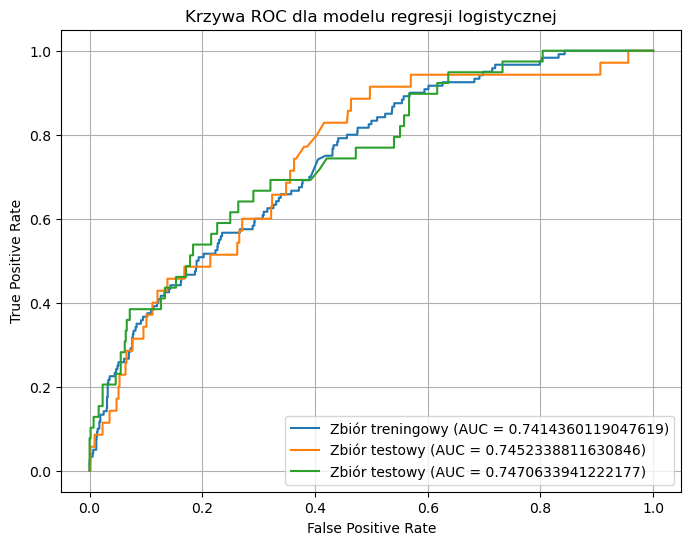

In [41]:
# Wykres krzywej ROC
plt.figure(figsize=(8,6))
plt.plot(roc_curve(y_train, y_proba_train_lr)[0], roc_curve(y_train, y_proba_train_lr)[1], label=f"Zbiór treningowy (AUC = {roc_auc_score(y_train, y_proba_train_lr)})")
plt.plot(roc_curve(y_val, y_proba_val_lr)[0], roc_curve(y_val, y_proba_val_lr)[1], label=f"Zbiór testowy (AUC = {roc_auc_score(y_val, y_proba_val_lr)})")
plt.plot(roc_curve(y_test, y_proba_test_lr)[0], roc_curve(y_test, y_proba_test_lr)[1], label=f"Zbiór testowy (AUC = {roc_auc_score(y_test, y_proba_test_lr)})")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Krzywa ROC dla modelu regresji logistycznej')
plt.legend()
plt.grid(True)
plt.show()

## Regresja logistyczna - współczynniki, ważność cech

In [40]:
# Ile kolumn tak właściwie nam zostało?
X_transformed = best_lr[:-1].transform(X_test)

# Sprawdzenie kształtu (shape) przetransformowanej macierzy
num_features_retained = X_transformed.shape[1] 

print(f"Liczba kolumn, które weszły do modelu (po całym preprocessingu i selekcji): {num_features_retained}")

Liczba kolumn, które weszły do modelu (po całym preprocessingu i selekcji): 52


### Odzyskanie oryginalnych nazw kolumn

In [41]:
# Pobranie listy wszystkich cech po ColumnTransformer (114)
feature_names_all = best_lr['preprocessing'].get_feature_names_out()
len(feature_names_all)

131

In [42]:
# Filtrowanie przez VarianceThreshold 
# Mogło powstać dużo stałych kolumn w wyniku onehotencoder
variance_filter = best_lr['variance_filter']
variance_mask = variance_filter.get_support()
feature_names_retained = feature_names_all[variance_mask]
len(feature_names_retained)

89

In [43]:
# Filtrowanie przez SelectFpr
selector = best_lr['stat_feature_selector']
support_mask_final = selector.get_support()
feature_names_final = feature_names_retained[support_mask_final]
len(feature_names_final)

52

In [44]:
# Tabela współczynników (posortowana według ważności)
coef = best_lr['model'].coef_[0]
importance_df = pd.DataFrame({
    'Feature': feature_names_final, 
    'Coefficient': coef 
}).sort_values(
    by='Coefficient', 
    key=lambda x: np.abs(x), 
    ascending=False
)

In [45]:
# 1. Utwórz słownik mapowania Indeks (str)
original_num_features_list = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
# Tworzymy mapę ID (int) -> Nazwa, a potem konwertujemy klucze na str
ID_TO_NAME_MAP = {
    str(index): name 
    for index, name in enumerate(original_num_features_list)
}

# 2. Utwórz kolumnę z ID ('83', '201', '160',...) z kolumny 'Feature'
importance_df['Numeric_ID_Str'] = (
    importance_df['Feature']
    .astype(str)
    # Zmieniamy to, aby pasowało do nowej, krótszej konwencji:
    # Usuwamy prefiks 'numeric_preprocessing__'
    .str.replace('numeric_preprocessing__', '')
    # Usuwamy prefiks 'categorical_preprocessing__' (jeśli jakieś się pojawią)
    .str.replace('categorical_preprocessing__', '')
)


# 3. Mapowanie na Nazwy Słowne
# Jeśli nazwa w 'Numeric_ID_Str' jest ID numerycznym (np. '83'), mapujemy ją na nazwę.
# Jeśli nie jest (bo jest cechą kategoryczną WoE, np. 'typ_konta'), zachowujemy jej nazwę.
def map_name(row):
    key = row['Numeric_ID_Str']
    
    # 3.1. Próba mapowania na Numeryczne (jeśli jest to numer)
    if key.isdigit():
        return ID_TO_NAME_MAP.get(key, row['Numeric_ID_Str'])
    
    # 3.2. W przeciwnym razie jest to oryginalna nazwa kategoryczna (po WoE)
    return key
    
importance_df['Final_Feature_Name'] = importance_df.apply(map_name, axis=1)


# 4. Wyświetl finalny wynik
print("TOP 10 WSPÓŁCZYNNIKÓW")
# Pamiętaj, aby posortować, jeśli chcesz TOP 10 WZGLĘDEM WAŻNOŚCI (|Współczynnik|)
print(importance_df[['Final_Feature_Name', 'Coefficient']].sort_values(
    by='Coefficient', 
    key=lambda x: np.abs(x), 
    ascending=False
).head(10))

TOP 10 WSPÓŁCZYNNIKÓW
                    Final_Feature_Name  Coefficient
8   Rozliczenia_miedzyokresowe_krotkie    -0.266446
48      wsk_struktura_kap_wlasnego_s_1     0.257150
33           wsk_zysk_operacyjny_zob_2     0.184149
30                wsk_koszty_przychody    -0.178973
10                          Zysk_netto    -0.125778
43                 wsk_rotacja_zapasow    -0.114303
29           wsk_sprzedaz_kap_obrotowy     0.099413
1                        Wartosc_firmy    -0.087832
42               wsk_rotacja_aktywow_2    -0.068268
22               wsk_koszty_operacyjne    -0.067845


In [46]:
# lista top 10 cech (przyda się później)
top_10_features = importance_df[['Final_Feature_Name', 'Coefficient']].sort_values(
    by='Coefficient', 
    key=lambda x: np.abs(x), 
    ascending=False
).head(10)['Final_Feature_Name'].tolist()

In [47]:
# Klasyfikacja współczynników
total_features = len(importance_df)
positive_coefs = len(importance_df[importance_df['Coefficient'] > 0])
negative_coefs = len(importance_df[importance_df['Coefficient'] < 0])
zero_coefs = len(importance_df[importance_df['Coefficient'] == 0])

# 2. Tworzenie podsumowania w DataFrame (dla czystości i raportowania)
summary_data = {
    'Typ Wpływu': ['Pozytywny (+)', 'Negatywny (-)', 'Zerowy (=)'],
    'Liczba Cech': [positive_coefs, negative_coefs, zero_coefs],
    'Procent (%)': [
        (positive_coefs / total_features) * 100,
        (negative_coefs / total_features) * 100,
        (zero_coefs / total_features) * 100
    ]
}

coef_summary_df = pd.DataFrame(summary_data)

print("Analiza wpółczynników")
print(f"Całkowita liczba cech w modelu: {total_features}")
print(f"{'Typ Wpływu':<20} | {'Liczba Cech':<15} | {'Procent (%)':<10}")

print(f"{'Pozytywny (+)':<20} | {positive_coefs:<15} | {(positive_coefs / total_features) * 100:.2f}")
print(f"{'Negatywny (-)':<20} | {negative_coefs:<15} | {(negative_coefs / total_features) * 100:.2f}")
print(f"{'Zerowy (=)':<20} | {zero_coefs:<15} | {(zero_coefs / total_features) * 100:.2f}")

Analiza wpółczynników
Całkowita liczba cech w modelu: 52
Typ Wpływu           | Liczba Cech     | Procent (%)
Pozytywny (+)        | 5               | 9.62
Negatywny (-)        | 16              | 30.77
Zerowy (=)           | 31              | 59.62


#### Nazwy zmiennych do kolejnych etapów

In [48]:
names = importance_df[['Feature', 'Final_Feature_Name']]
names

,Feature,Final_Feature_Name
8,numeric_preprocessing__25,Rozliczenia_miedzyokresowe_krotkie
48,numeric_preprocessing__201,wsk_struktura_kap_wlasnego_s_1
33,numeric_preprocessing__125,wsk_zysk_operacyjny_zob_2
30,numeric_preprocessing__115,wsk_koszty_przychody
10,numeric_preprocessing__29,Zysk_netto
43,numeric_preprocessing__163,wsk_rotacja_zapasow
29,numeric_preprocessing__114,wsk_sprzedaz_kap_obrotowy
1,numeric_preprocessing__7,Wartosc_firmy
42,numeric_preprocessing__160,wsk_rotacja_aktywow_2
22,numeric_preprocessing__82,wsk_koszty_operacyjne


## Testy monotoniczności

In [49]:
def check_monotonicity(X_data, y_true, p_proba, feature, n_bins=10, ascending=True):
    
    # 1. Tworzenie koszyków na podstawie cechy
    # Użycie qcut (kwantyle) jest bezpieczniejsze przy nierównym rozkładzie danych
    df = pd.DataFrame({'Y_true': y_true, 'P_proba': p_proba, 'Feature_Value': X_data[feature]})
    
    # Zmieniamy pd.cut na pd.qcut, które tworzy koszyki o równej liczbie obserwacji 
    # (Co jest lepsze dla testów statystycznych)
    try:
        df['Bin'] = pd.qcut(df['Feature_Value'], q=n_bins, duplicates='drop')
    except ValueError:
        # Awaryjnie wracamy do pd.cut, jeśli qcut zawiedzie (za mało unikalnych wartości)
        df['Bin'] = pd.cut(df['Feature_Value'], bins=n_bins, duplicates='drop')

    # 2. Obliczenie średniej PD (Mean PD)
    results = df.groupby('Bin', observed=True).agg(
        Mean_PD=('P_proba', 'mean'),
        Count=('Feature_Value', 'count')
    ).dropna()
    
    # 3. TEST MONOTONICZNOŚCI
    
    mean_pd_values = results['Mean_PD'].values
    
    if len(mean_pd_values) <= 1:
        # Zbyt mało koszyków, by przeprowadzić test
        is_monotonic = False
    else:
        # Oblicz różnice między kolejnymi koszykami
        diffs = np.diff(mean_pd_values)
        
        if ascending:
            # Test rosnący: sprawdzamy, czy wszystkie różnice są >= 0 (niemalejące)
            # Używamy np.all, aby sprawdzić, czy wszystkie różnice spełniają warunek
            is_monotonic = np.all(diffs >= 0)
        else:
            # Test malejący: sprawdzamy, czy wszystkie różnice są <= 0 (nierosnące)
            is_monotonic = np.all(diffs <= 0)
            
    
    # 4. Wizualizacja
    plt.figure(figsize=(10, 5))
    results['Mean_PD'].plot(kind='bar')
    plt.title(f"Monotoniczność PD vs {feature} (Test: {is_monotonic})")
    plt.ylabel("Średnie PD")
    plt.xlabel(f"Koszty cechy {feature}")
    plt.xticks(rotation=45, ha='right')
    plt.show()
    
    return is_monotonic, results


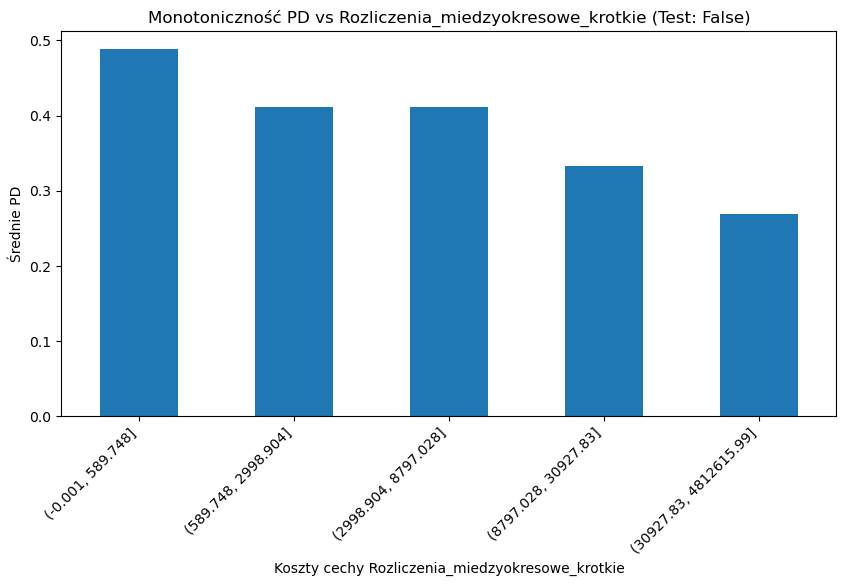

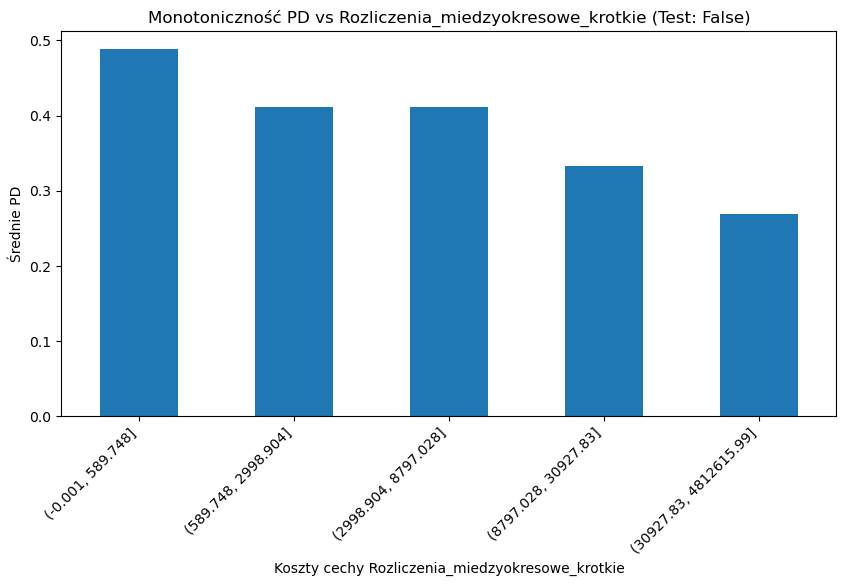

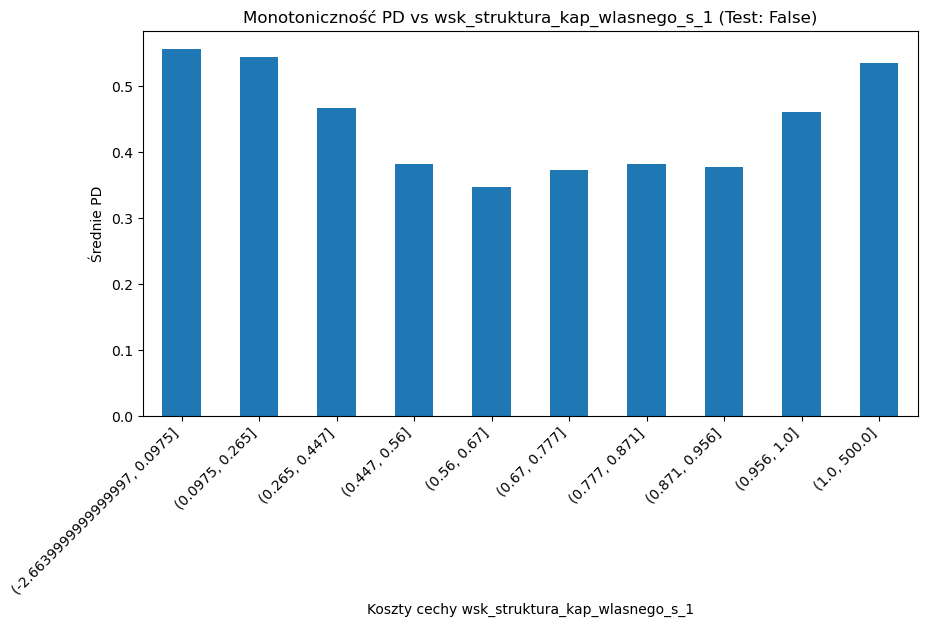

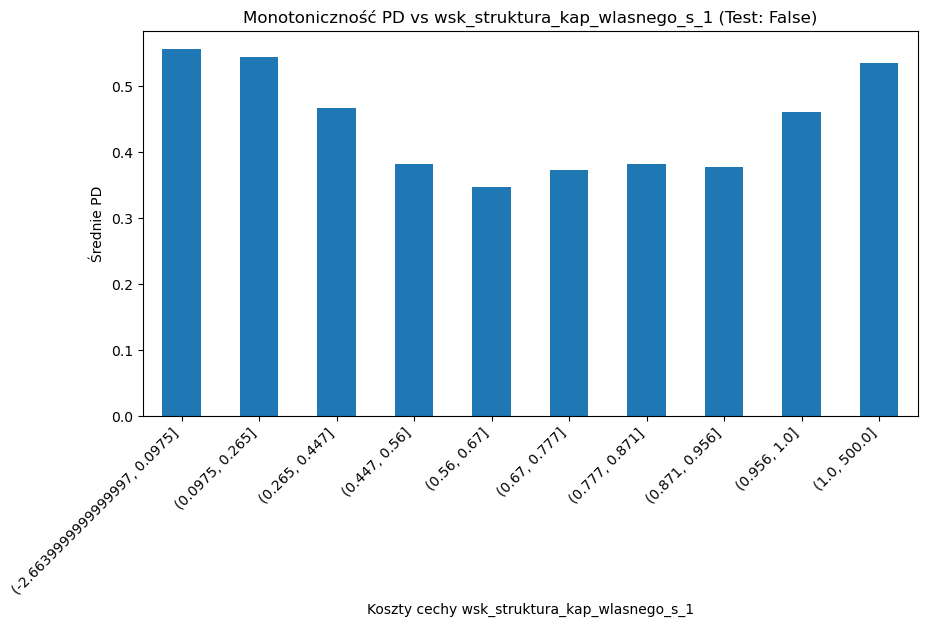

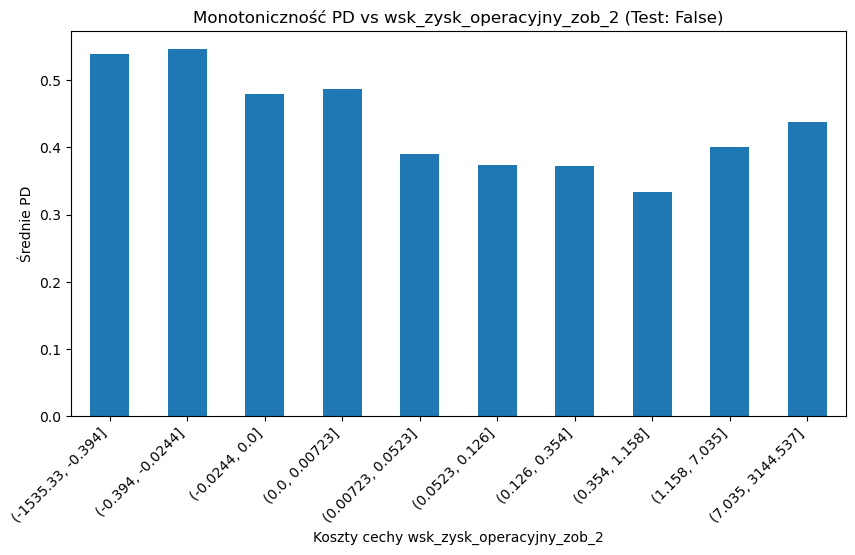

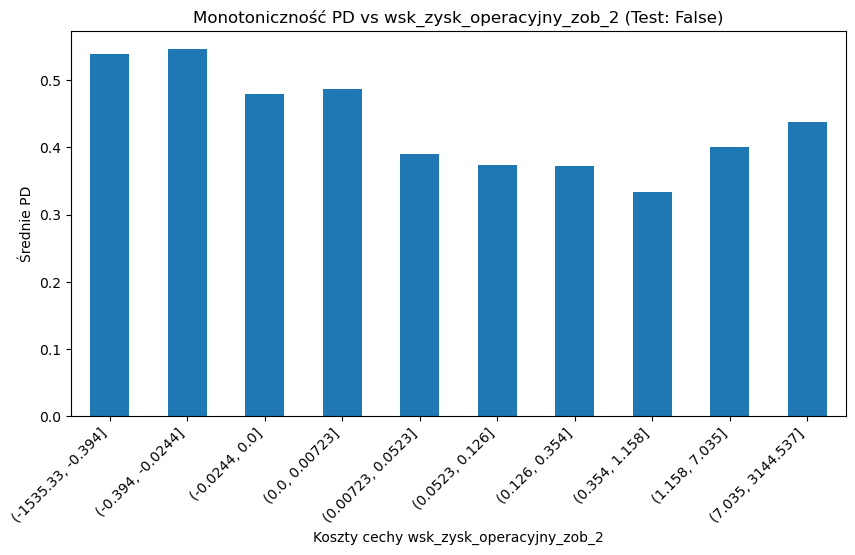

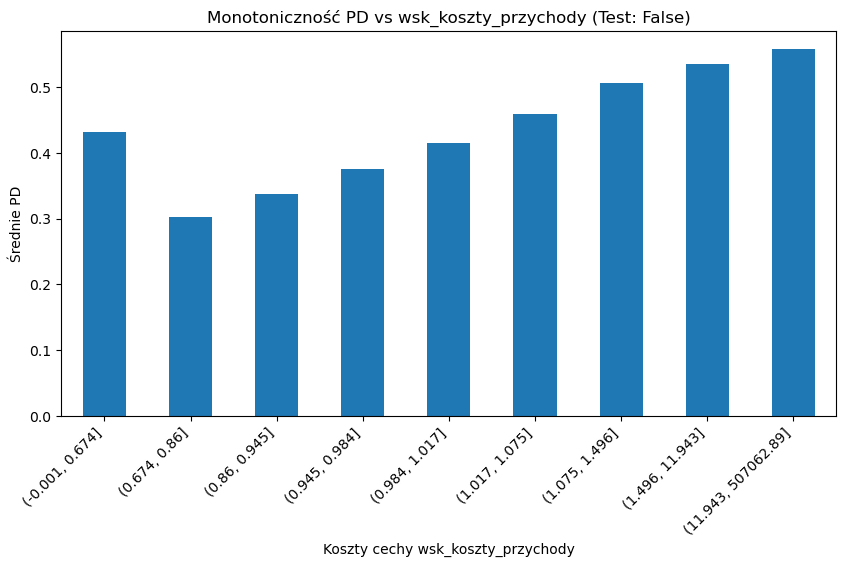

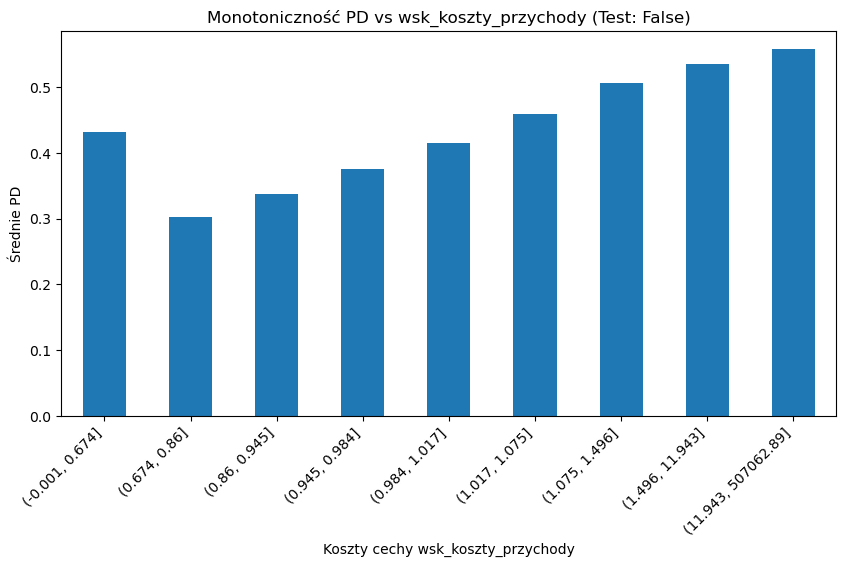

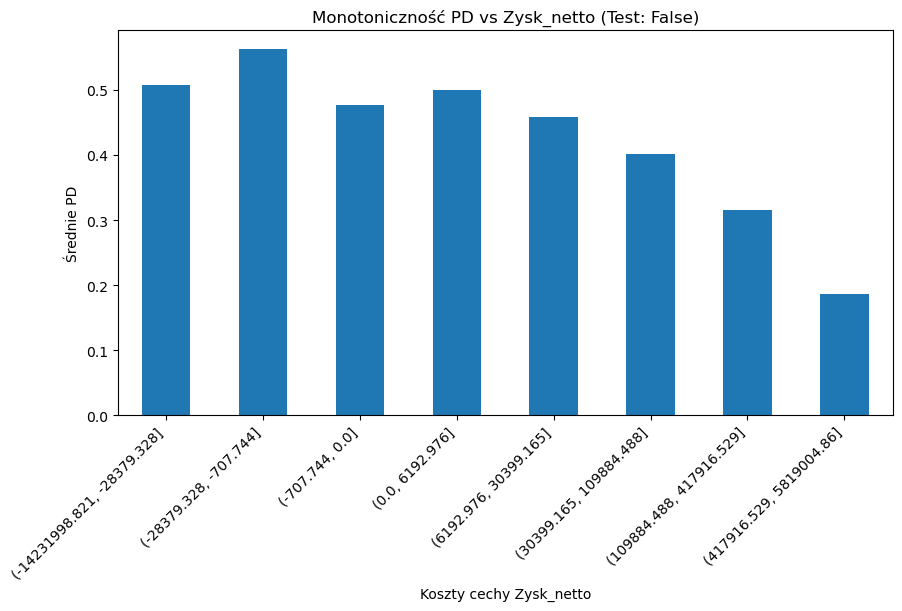

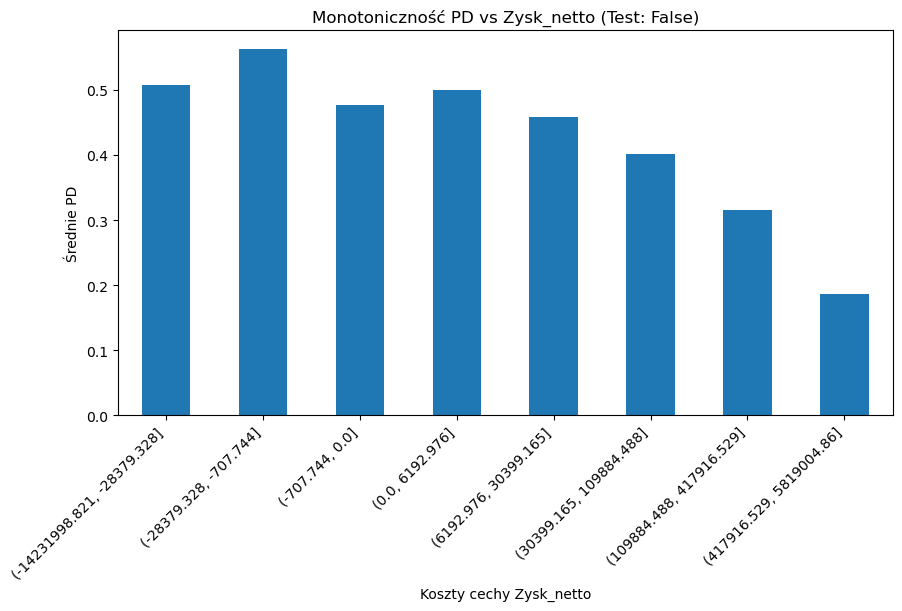

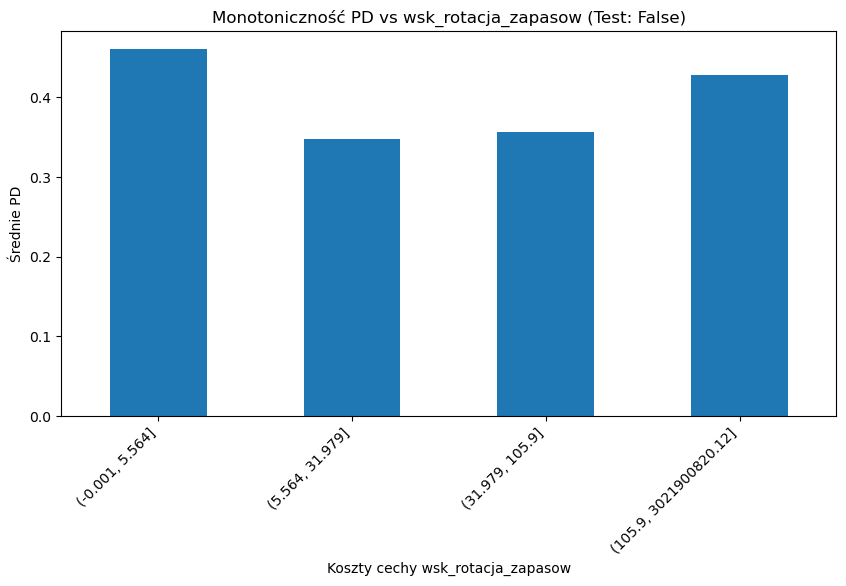

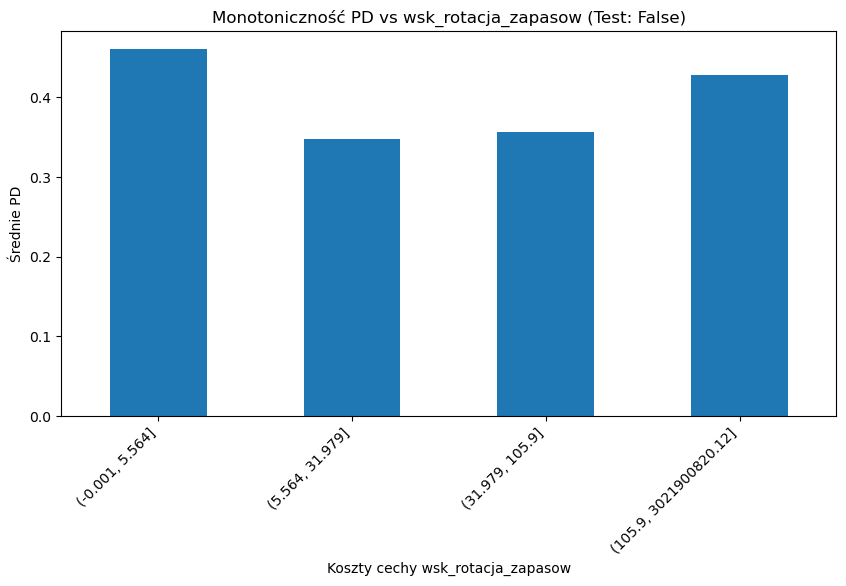

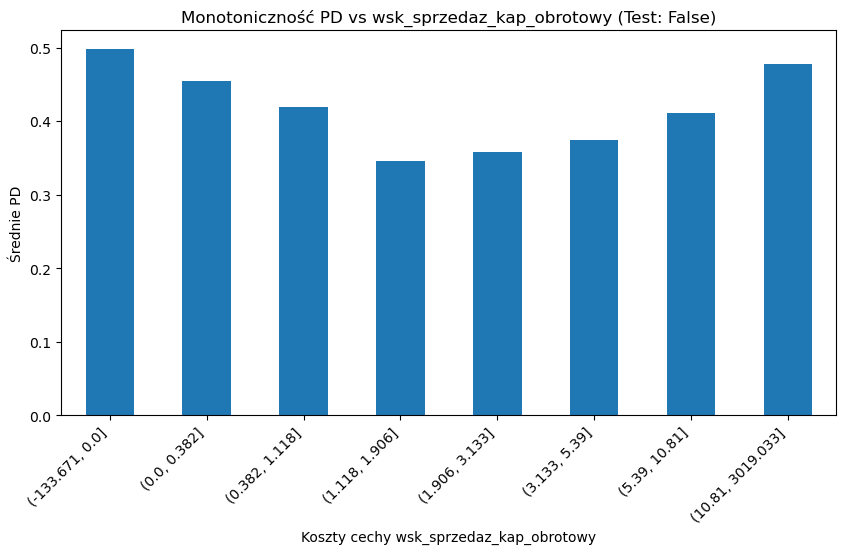

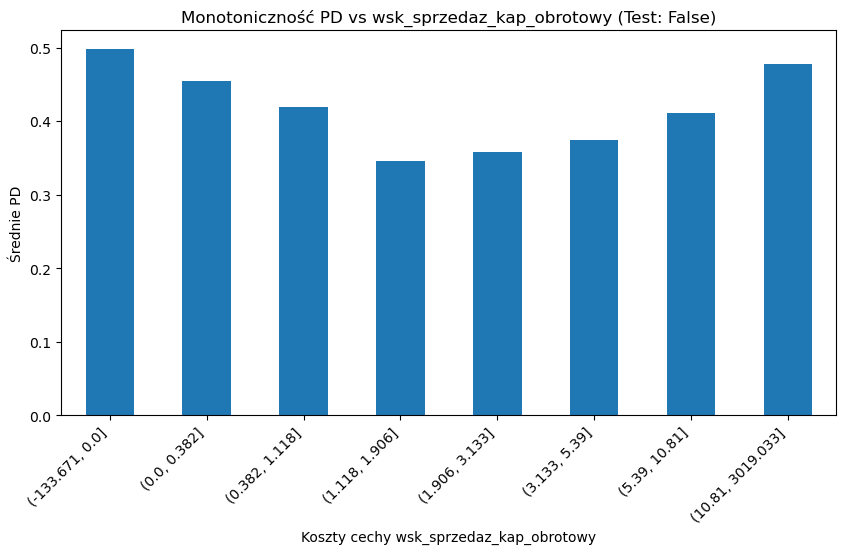

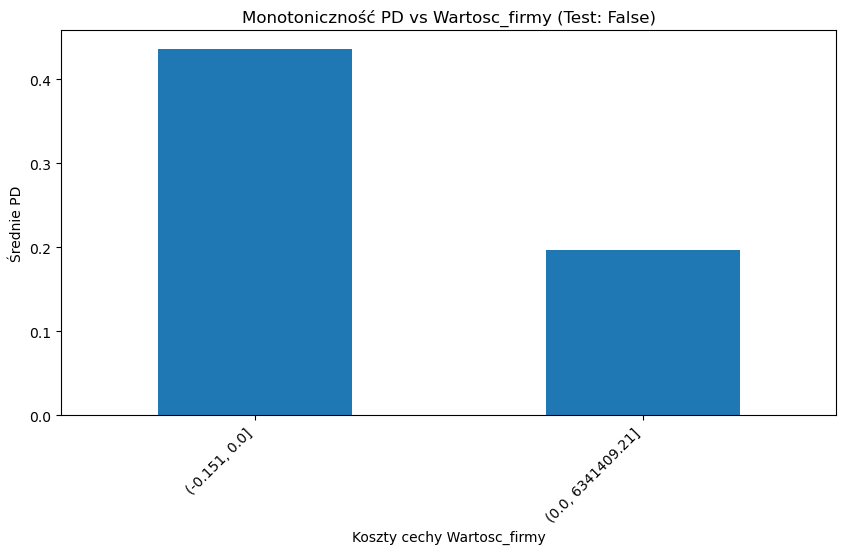

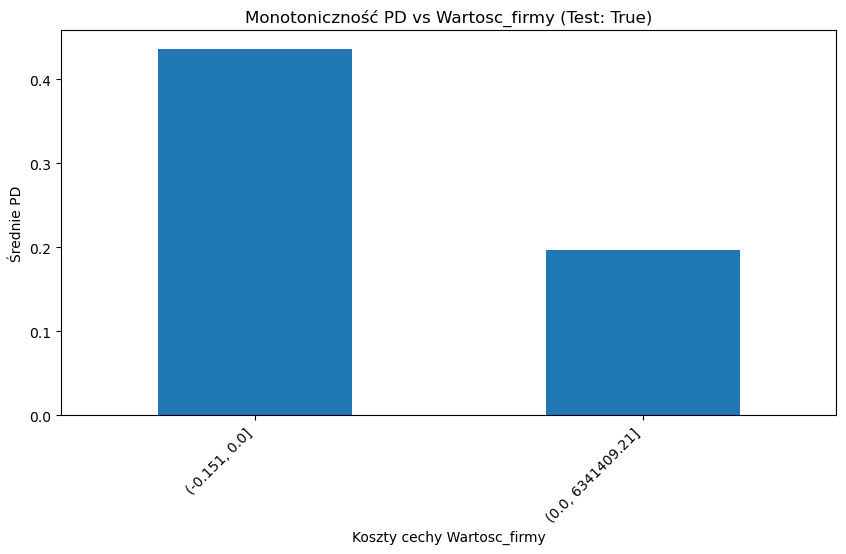

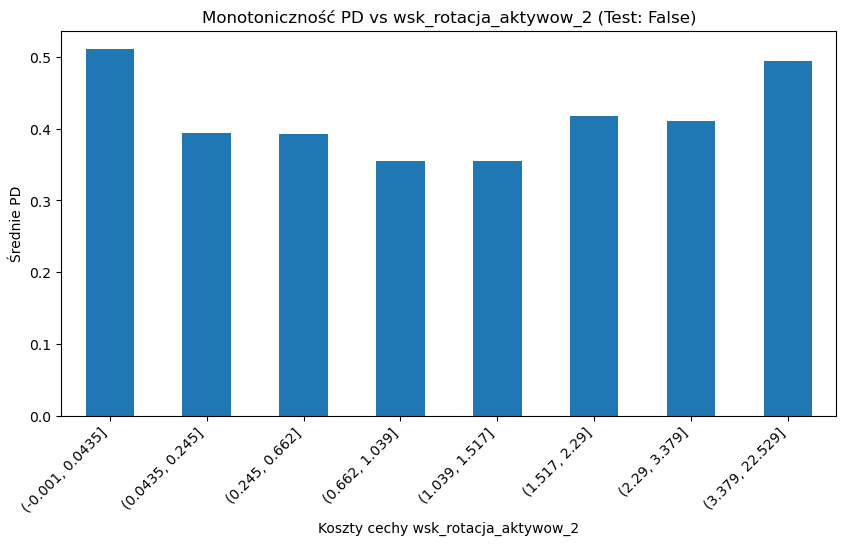

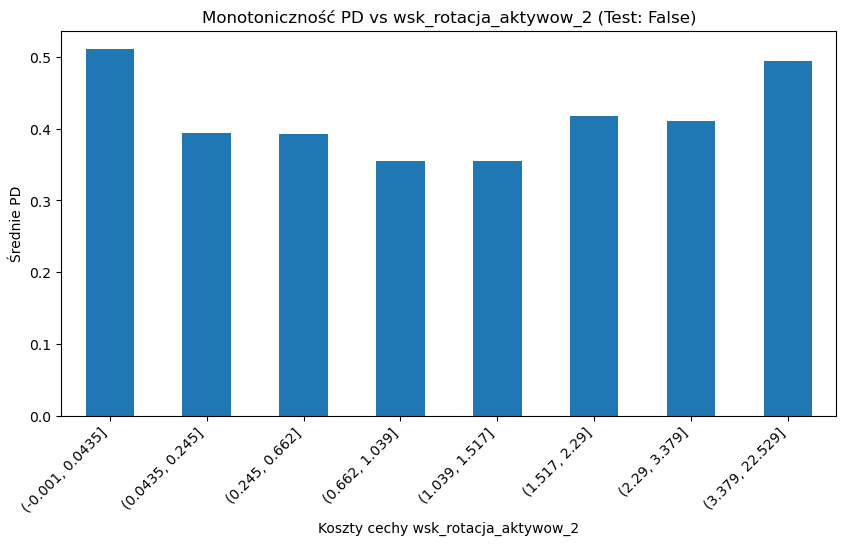

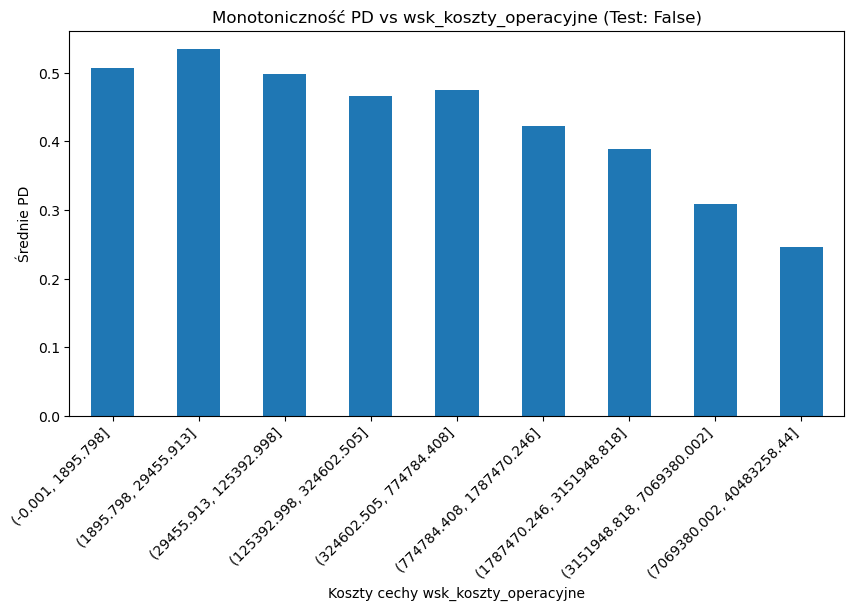

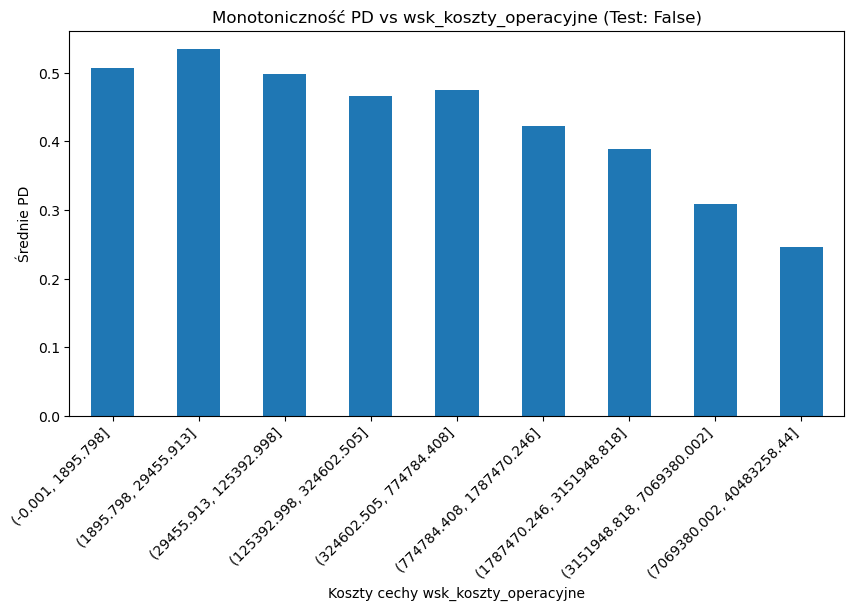

WYNIKI TESTU MONOTONICZNOŚCI TOP 10 CECH
| Cecha                              | Monotoniczność   | Kierunek_Rosnący   | Kierunek_Malejący   |
|:-----------------------------------|:-----------------|:-------------------|:--------------------|
| Rozliczenia_miedzyokresowe_krotkie | NIE              | NIE                | NIE                 |
| wsk_struktura_kap_wlasnego_s_1     | NIE              | NIE                | NIE                 |
| wsk_zysk_operacyjny_zob_2          | NIE              | NIE                | NIE                 |
| wsk_koszty_przychody               | NIE              | NIE                | NIE                 |
| Zysk_netto                         | NIE              | NIE                | NIE                 |
| wsk_rotacja_zapasow                | NIE              | NIE                | NIE                 |
| wsk_sprzedaz_kap_obrotowy          | NIE              | NIE                | NIE                 |
| Wartosc_firmy                      | TAK        

In [50]:
results = []

for feature in top_10_features:
    
    # Testujemy, czy PD konsekwentnie rośnie (Oczekiwany: rosnący)
    is_mono_increasing, _ = check_monotonicity(
        X_val, y_val.values, y_proba_val_lr, feature, ascending=True
    )
    
    # Testujemy, czy PD konsekwentnie maleje (Oczekiwany: malejący)
    is_mono_decreasing, _ = check_monotonicity(
        X_val, y_val.values, y_proba_val_lr, feature, ascending=False
    )
    
    # Akceptujemy, jeśli cecha jest monotoniczna w dowolnym kierunku
    is_monotonic = is_mono_increasing or is_mono_decreasing
    
    results.append({
        'Cecha': feature,
        'Monotoniczność': 'TAK' if is_monotonic else 'NIE',
        'Kierunek_Rosnący': 'TAK' if is_mono_increasing else 'NIE',
        'Kierunek_Malejący': 'TAK' if is_mono_decreasing else 'NIE'
    })

# 2. Wyświetlenie i Analiza Wyników

df_mono_results = pd.DataFrame(results)

print("WYNIKI TESTU MONOTONICZNOŚCI TOP 10 CECH")
print(df_mono_results.to_markdown(index=False))

# Kluczowy wniosek:
monotonous_count = df_mono_results['Monotoniczność'].value_counts()
print(f"\nLiczba cech monotonicznych: {monotonous_count.get('TAK', 0)} / {len(top_10_features)}")

Testy monotoniczności wykazały, że tylko jedna (wizualnie dwie) z Top 10 cech ma prosty, liniowy związek z ryzykiem. 
Pozostałe dziewięć cech wykazuje złożone, nieliniowe zależności, co dowodzi ograniczeń przyjętego modelu regresji logistycznej.
Przy tworzeniu modelu nie daliśmy żadnych ograniczeń o monotoniczości, więc jest to oczekiwany wynik.

### Interpretacja lokalna: dekompozycja logitu dla wybranego klienta

In [51]:
# klient do analizyS
client_index = 0

# 1. ODTWORZENIE NAZW CECH PO WSZYSTKICH TRANSFORMACJACH

# A. Nazwy po ColumnTransformer
feature_names_all = best_lr['preprocessing'].get_feature_names_out()

# B. Po VarianceThreshold
variance_mask = best_lr['variance_filter'].get_support()
feature_names_retained = feature_names_all[variance_mask]

# C. Po SelectFpr (ostateczne wejście do modelu)
selector = best_lr['stat_feature_selector']
support_mask_final = selector.get_support()
feature_names_final = feature_names_retained[support_mask_final]

# 2. TRANSFORMACJA CECH KLIENTA

pipeline_transformer = best_lr[:-1]
client_original_features = X_val.iloc[[client_index]]
client_transformed_array = pipeline_transformer.transform(client_original_features)

client_features_scaled = pd.DataFrame(
    client_transformed_array,
    columns=feature_names_final
)


# 3. DEKOMPOZYCJA LOGITU

final_model = best_lr['model']

intercept = final_model.intercept_[0]
coefficients = pd.Series(final_model.coef_[0], index=client_features_scaled.columns)

feature_contributions = coefficients * client_features_scaled.iloc[0]

client_logit = intercept + feature_contributions.sum()
client_pd = 1 / (1 + np.exp(-client_logit))


# 4. MAPOWANIE NA ORYGINALNE NAZWY CECH

# Wyciągamy listę oryginalnych cech numerycznych
original_num_features_list = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
ID_TO_NAME_MAP = {str(i): name for i, name in enumerate(original_num_features_list)}

def map_name(row):
    key = row['Numeric_ID_Str']
    if key.isdigit():          # numeryczne
        return ID_TO_NAME_MAP.get(key, key)
    return key                 # kategoryczne (np. WoE)

# Dekodowanie nazw cech z ColumnTransformer - Variance - SelectFpr
decomposition_df = pd.DataFrame({
    'Feature': feature_contributions.index,
    'Coefficient': feature_contributions.values
})

# Dodanie interceptu
decomposition_df.loc[len(decomposition_df)] = ['Intercept', intercept]

# ID ze ścieżki transformacji
decomposition_df['Numeric_ID_Str'] = (
    decomposition_df['Feature']
    .str.replace('numeric_preprocessing__', '', regex=False)
    .str.replace('categorical_preprocessing__', '', regex=False)
)

# Zastosowanie mapowania
decomposition_df['Final_Feature_Name'] = decomposition_df.apply(map_name, axis=1)

# Sortowanie po |wkład|
decomposition_df = decomposition_df.sort_values(
    by='Coefficient',
    key=lambda x: np.abs(x),
    ascending=False
)

# 5. WYNIKI

print(f"ANALIZA LOKALNA KLIENTA ID (z X_val): {client_index}")
print(f"Rzeczywista etykieta (Default?): {y_val.iloc[client_index]}")
print(f"Przewidywane PD: {client_pd:.4f}")
print(f"Przewidywany Logit (suma wkładów): {client_logit:.4f}")

print("\nDEKOMPOZYCJA LOGITU NA WKŁADY CECH")
print(
    decomposition_df[['Final_Feature_Name', 'Coefficient']]
    .head(12)
    .to_markdown(index=False, floatfmt=".4f")
)


ANALIZA LOKALNA KLIENTA ID (z X_val): 0
Rzeczywista etykieta (Default?): 0
Przewidywane PD: 0.4809
Przewidywany Logit (suma wkładów): -0.0766

DEKOMPOZYCJA LOGITU NA WKŁADY CECH
| Final_Feature_Name                 |   Coefficient |
|:-----------------------------------|--------------:|
| Intercept                          |       -0.2822 |
| wsk_struktura_kap_wlasnego_s_1     |       -0.2071 |
| Rozliczenia_miedzyokresowe_krotkie |        0.2041 |
| wsk_zysk_operacyjny_zob_2          |       -0.1174 |
| Zysk_netto                         |        0.0900 |
| wsk_rotacja_zapasow                |        0.0829 |
| Wartosc_firmy                      |        0.0549 |
| wsk_zob_oprocentowanych            |       -0.0494 |
| wsk_koszty_przychody               |       -0.0492 |
| wsk_rotacja_aktywow_2              |        0.0490 |
| wsk_sprzedaz_kap_obrotowy          |       -0.0487 |
| wsk_koszty_operacyjne              |        0.0429 |


$$
\text{logit} = \beta_0 + \sum_i \beta_i x_i
$$

(Wartość dla pojedynczego klienta)


logit = 0, PD = 0.5 - granica decyzji, domyślny próg klasyfikacji.

logit > 0, PD > 0.5 - model wskazuje default.

logit < 0, PD < 0.5 - model wskazuje brak defaultu.

#### Wnioski

Klient został prawidłowo sklasyfikowany jako niewymagający alertu (TN), ale poziom ryzyka wyliczony przez model – ok. 48% – jest bardzo wysoki jak na przypadek bezdefaultowy. To typowy sygnał słabej kalibracji: model nie potrafi właściwie odwzorować poziomu absolutnego ryzyka, mimo że kierunek predykcji jest poprawny.

Lokalna dekompozycja logitu (–0.0766) potwierdza, że ocena ryzyka balansuje na granicy decyzji. (Logit=0 oznacza PD = 0.5 w przypadku domyślnego progu. Tutaj logit jest blisko 0, ale już na minusie, zgadza się z tym, że PD=48%). Bazowy wkład (Intercept –0.28) obniża ryzyko, natomiast kilka cech istotnie je podnosi – w szczególności: Rozliczenia_miedzyokresowe_krotkie, Zysk_netto, wsk_rotacja_zapasow.


## PDP i ICE
Badamy globalnie, czyli powinnismy zbadac dla wszystkich cech, zbadamy dla najważniejszych wzgledem permutation_importance

In [52]:
from sklearn.inspection import PartialDependenceDisplay, partial_dependence

In [53]:
from sklearn.inspection import permutation_importance
#szukamy najbardziej wpływowych cech dla regresji logistycznej za pomoca permutation_importance

#Obliczamy ważność permutacji na zbiorze walidacyjnym (lub próbce treningowej)
#Używamy dopasowanego Pipeline'u - best_lr i surowych danych X_val
perm_result = permutation_importance(
    best_lr, 
    X_val,      
    y_val, 
    n_repeats=5, 
    random_state=42, 
    n_jobs=-1)

#ranking
perm_importance_df = pd.DataFrame({
    'Feature': X_val.columns,
    'Importance': perm_result.importances_mean,
    'Std': perm_result.importances_std
}).sort_values(by='Importance', ascending=False)

print("\nNajważniejsze cechy wg Permutation Importance:")
print(perm_importance_df.head(10))

cechy_do_pdp = perm_importance_df['Feature'].head(3).tolist()


Najważniejsze cechy wg Permutation Importance:
                                 Feature  Importance       Std
128             wsk_koszty_fin_przychody    0.040333  0.007846
204                       wsk_zadluzenia    0.031667  0.010111
208           wsk_struktura_kap_obcego_s    0.013667  0.006092
117                    wsk_rent_kapitalu    0.009667  0.010614
203       wsk_struktura_kap_wlasnego_s_2    0.004000  0.000816
142                       wsk_ROE_brutto    0.003333  0.006055
85       wsk_Zobowiazania_dlugoterminowe    0.002333  0.002261
124      wsk_pokrycie_zob_kr_gotowkowe_1    0.002000  0.003232
96                    wsk_mnoznik_kap_wl    0.001333  0.000667
166  wsk_rotacja_naleznosci_dostaw_uslug    0.001000  0.004422


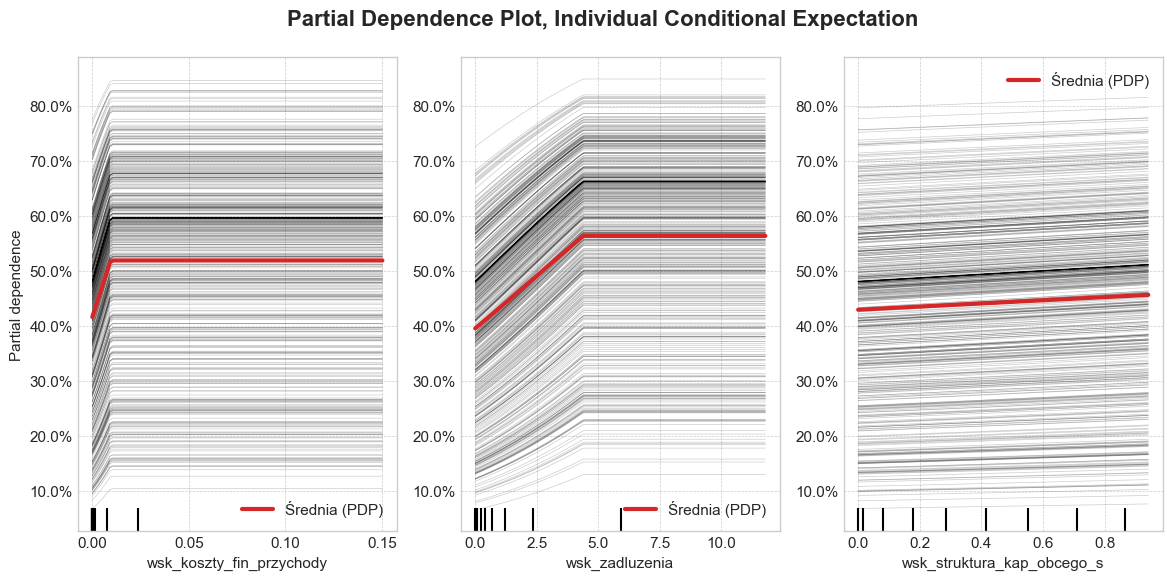

In [54]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.size'] = 11 
pdp_style = {
    'color': '#D62728',   
    'linewidth': 3,        
    'linestyle': '-',      
    'label': 'Średnia (PDP)'
}
ice_style = {
    'color': 'black',   
    'alpha': 0.2,
    'linewidth': 0.5
}

# 3. Rysowanie
fig, ax = plt.subplots(figsize=(14, 6))

display = PartialDependenceDisplay.from_estimator(
    estimator=best_lr,                      #pipeline z najlepszym modelem
    X=X_train.sample(500, random_state=42), #probka surowych danych
    features=cechy_do_pdp,    
    kind='both',                            #pdp i ice
    response_method='predict_proba', 
    centered=False,            
    line_kw=pdp_style,              
    ice_lines_kw=ice_style, 
    ax=ax
)

plt.suptitle('Partial Dependence Plot, Individual Conditional Expectation', fontsize=16, weight='bold')
plt.subplots_adjust(top=0.9)
import matplotlib.ticker as mtick
for ax_sub in display.axes_.flatten():
    ax_sub.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=1))
    ax_sub.grid(True, which='both', linestyle='--', linewidth=0.5)
#plt.savefig('PDP.png', dpi=300, bbox_inches='tight')
plt.show()

## Kalibracja prawdopdobieństw

Tu będziemy potrzebować zbioru walidacyjnego - nie kalibrujemy na danych treningowych bo jest data leak!

PD (Prawdopodobieństwo Defaultu) - prognozowane ryzyko, że dany klient nie spłaci swojego zobowiązania w określonym czasie.

ECE (Expected Calibration Error): Mierzy błąd nieskalibrowania modelu, który powinien dążyć do zera, aby predykcje były wiarygodne.

Krzywa Reliability - wizualnie porównuje przewidywane prawdopodobieństwo defaultu z rzeczywistą częstotliwością zdarzeń, pokazując, jak bardzo model odbiega od idealnej wiarygodności.

Histogram predykcji - pokazuje rozkład surowych prawdopodobieństw defaultu (jak często model przewidział daną wartość ryzyka dla każdego klienta)

#### ECE - Expected Calibration Error

In [55]:
def expected_calibration_error(y_true, p, n_bins=10):
    quantiles = np.linspace(0, 1, n_bins+1)
    bins = np.quantile(p, quantiles)
    bins = np.unique(bins)
    
    if len(bins) == 1:
        return float(np.abs(y_true.mean() - p.mean()))
    
    idx = np.digitize(p, bins[1:-1], right=True)
    ece = 0.0
    
    for b in range(len(bins)-1):
        mask = idx == b
        if np.sum(mask) == 0:
            continue
        conf = p[mask].mean()
        acc = y_true[mask].mean()
        w = np.mean(mask)
        ece += w * np.abs(acc - conf)
    
    return float(ece)

ece_lr = expected_calibration_error(y_val, y_proba_val_lr)
print(f"ECE: {ece_lr:.4f}")

ECE: 0.3770


ECE jest bardzo duże (dążymy do wartości poniżej 0.05 lub chociaż poniżej 0.1) - kalibracja jest konieczna.

#### Krzywa Reliability
Wizualnie ocenia wiarygodność surowych prawdopodobieństw modelu. Pokazuje, jak daleko model odbiega od idealnej kalibracji.

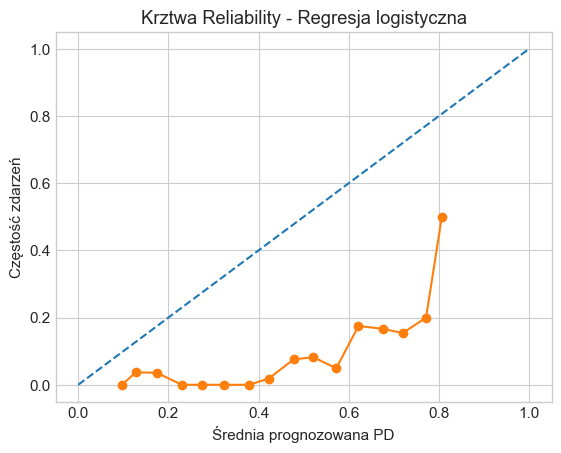

In [130]:
from sklearn.calibration import calibration_curve

def reliability_plot(y_true, p, title):
    frac_pos, mean_pred = calibration_curve(y_true, p, n_bins=20, strategy='uniform')
    plt.figure()
    plt.plot([0,1],[0,1], '--')
    plt.plot(mean_pred, frac_pos, marker='o')
    plt.title(title)
    plt.xlabel("Średnia prognozowana PD")
    plt.ylabel("Częstość zdarzeń")
    plt.show()


reliability_plot(y_val, y_proba_val_lr, "Krztwa Reliability - Regresja logistyczna")

Krzywa leży poniżej linii idealnej kalibracji - underconfidence (niedoszacowanie ryzyka) - model jest zbyt ostrożny

#### Histogram predykcji

In [131]:
def hist_predictions(p, title):
    plt.figure()
    plt.hist(p, bins=20)
    plt.xlim([0.0, 1.0])
    plt.title(title)
    plt.xlabel("PD")
    plt.ylabel("Liczność")
    plt.show()

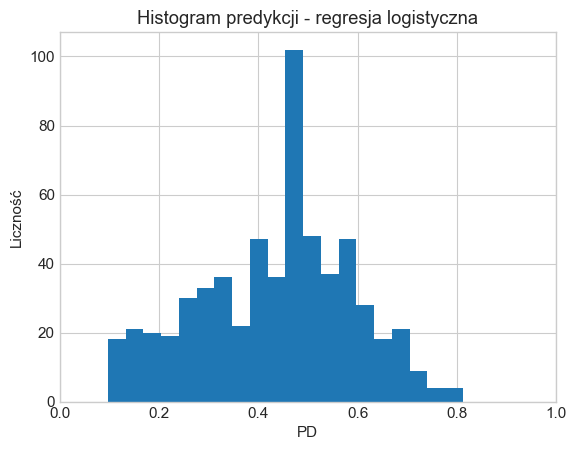

In [132]:
hist_predictions(y_proba_val_lr, "Histogram predykcji - regresja logistyczna")

Najwięcej obserwacji ma prognozowane ryzyko defaultu ok 50%, czyli model jest bardzo niepewny. Nie potrafi on z dużą pewnością zidentyfikować ani klientów bardzo bezpiecznych, ani bardzo ryzykownych.

#### Brier Score - dekompozycja

In [59]:
def brier_decomposition(y_true, y_prob, n_bins=10):
    """
    Rozkłada Brier Score na trzy komponenty:
    1. Uncertainty (Niepewność)
    2. Resolution (Rozdzielczość)
    3. Reliability (Nieskalibrowanie)
    Brier_Score = Uncertainty - Resolution + Reliability
    """

    # Wymuszamy konwersję WSZYSTKICH wejść na czyste tablice NumPy.
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    
    # 1. Obliczenie Frakcji Pozytywnych i Średnich Predykcji na Koszykach
    # Dzielimy prawdopodobieństwa na koszyki (tak jak w calibration_curve)
    
    # Sortowanie obserwacji według prawdopodobieństwa
    order = np.argsort(y_prob)
    y_prob_sorted = y_prob[order]
    y_true_sorted = y_true[order]
    
    # Podział na n_bins równych koszyków (licząc po liczbie obserwacji)
    bins = np.array_split(np.arange(len(y_true)), n_bins)
    
    # Inicjalizacja
    n_k = np.zeros(n_bins)  # Liczba obserwacji w koszyku
    p_k = np.zeros(n_bins)  # Średnia predykcja w koszyku
    o_k = np.zeros(n_bins)  # Rzeczywista frekwencja (observed frequency) w koszyku
    
    for i in range(n_bins):
        indices = bins[i]
        n_k[i] = len(indices)
        if n_k[i] > 0:
            p_k[i] = np.mean(y_prob_sorted[indices])
            o_k[i] = np.mean(y_true_sorted[indices])
        else:
            n_k[i] = 0
            
    # Usuwamy puste koszyki (jeśli są)
    valid_bins = n_k > 0
    n_k = n_k[valid_bins]
    p_k = p_k[valid_bins]
    o_k = o_k[valid_bins]

    # 2. Obliczenie Komponentów
    
    # Globalna frekwencja defaultu (Niepewność)
    # Rzeczywisty Brier Score
    N = len(y_true)
    y_mean = np.mean(y_true)
    
    # Uncertainty (Niepewność) - Błąd, jaki miałby model zgadujący średnią frekwencję
    uncertainty = y_mean * (1 - y_mean)
    
    # Reliability (Nieskalibrowanie) - Jak daleki jest model od idealnej kalibracji
    reliability = np.sum(n_k * (p_k - o_k)**2) / N
    
    # Resolution (Rozdzielczość) - Zdolność modelu do grupowania obserwacji
    resolution = np.sum(n_k * (o_k - y_mean)**2) / N
    
    # Suma: Brier Score = Uncertainty - Resolution + Reliability
    # Sprawdzenie poprawności:
    # brier_decomposition = uncertainty - resolution + reliability
    
    return {
        'Brier_Score': brier_score_loss(y_true, y_prob),
        'Uncertainty': uncertainty,
        'Resolution': resolution,
        'Reliability_Error': reliability,
    }

In [60]:
print("Dekompozycja Brier Score Pre-Cal")
decomposition_lr = brier_decomposition(y_val.values, y_proba_val_lr)
print(pd.Series(decomposition_lr))

Dekompozycja Brier Score Pre-Cal
Brier_Score          0.206994
Uncertainty          0.054931
Resolution           0.003069
Reliability_Error    0.154972
dtype: float64


- Brier Score: Mierzy całkowity błąd kwadratowy prognoz probabilistycznych.
- Uncertainty (Niepewność): Jest to najmniejszy możliwy błąd dla danego zbioru; zależy tylko od globalnej frekwencji defaultu (np. $4\%$).
- Resolution (Rozdzielczość): Mierzy zdolność modelu do rankowania klientów; im wyższa wartość, tym lepiej model rozróżnia grupy ryzyka.
- Reliability Error (Nieskalibrowanie): Mierzy, jak bardzo prognozy modelu są nieuczciwe (niezgodne z rzeczywistą frekwencją); jest to błąd, który usuwamy poprzez kalibrację.

  
Duzy Brier_Score i Reliability_Error - model wymaga kalibracji

#### Kaibracja lokalna - Metoda Platt (sigmoid) 
- Zbiór walidacyjny ma 600 obserwacji (poniżej 1000 zalecana ta metoda)
- Dobra dla regresji logistycznej
- Stabilniejsza i szybsza do implementacji

In [61]:
from sklearn.calibration import CalibratedClassifierCV

lr_model_cal = CalibratedClassifierCV(estimator=best_lr, method="sigmoid", cv="prefit")
lr_model_cal.fit(X_val, y_val)

p_train_lr_cal = lr_model_cal.predict_proba(X_train)[:,1]
p_val_lr_cal = lr_model_cal.predict_proba(X_val)[:,1]
p_test_lr_cal = lr_model_cal.predict_proba(X_test)[:,1]

ece_lr_cal = expected_calibration_error(y_val.values, p_val_lr_cal)

print(f"ECE: {ece_lr_cal:.4f}")

C:\Users\Uzytkownik\anaconda3\Lib\site-packages\sklearn\calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


ECE: 0.0185


#### Calibration-in-the-large

In [62]:
def logit_fn(p, eps=1e-12):
    p = np.clip(p, eps, 1-eps)
    return np.log(p/(1-p))

def inv_logit(z):
    return 1/(1+np.exp(-z))

def shift_to_target_mean(p, target_mean=0.04, tol=1e-6, max_iter=100):
    z = logit_fn(p)
    lo, hi = -10.0, 10.0
    for _ in range(max_iter):
        mid = (lo+hi)/2
        m = inv_logit(z + mid).mean()
        if abs(m - target_mean) < tol:
            return inv_logit(z + mid)
        if m < target_mean:
            lo = mid
        else:
            hi = mid
    return inv_logit(z + (lo+hi)/2)

In [63]:
def get_global_shift(p, target_mean=0.04, tol=1e-6, max_iter=100):
    z = logit_fn(p)
    lo, hi = -10.0, 10.0
    
    for _ in range(max_iter):
        mid = (lo + hi) / 2
        m = inv_logit(z + mid).mean()
        if abs(m - target_mean) < tol:
            return mid
        if m < target_mean:
            lo = mid
        else:
            hi = mid
    return (lo + hi) / 2 
    # Zwraca obliczoną stałą przesunięcia

# Obliczenie stałej przesunięcia na podstawie zbioru walidacyjnego
global_shift = get_global_shift(p_val_lr_cal, target_mean=0.04)
print(f"Obliczone globalne przesunięcie (Shift) w logitach: {global_shift:.4f}")

# Zastosowanie tego samego stałego przesunięcia do wszystkich zbiorów

# Aplikacja na zbiorze Treningowym
z_train = logit_fn(p_train_lr_cal)
p_train_lr_final = inv_logit(z_train + global_shift)

# Aplikacja na zbiorze Walidacyjnym
z_val = logit_fn(p_val_lr_cal)
p_val_lr_final = inv_logit(z_val + global_shift)

# Aplikacja na zbiorze Testowym
z_test = logit_fn(p_test_lr_cal)
p_test_lr_final = inv_logit(z_test + global_shift)

Obliczone globalne przesunięcie (Shift) w logitach: -0.4135


Średnie PD (Cel: 4.00%): 0.039999
ECE (Post-Cal): 0.0277
Dekompozycja Brier Score Post-Cal
Brier_Score          0.052761
Uncertainty          0.054931
Resolution           0.003069
Reliability_Error    0.001128
dtype: float64


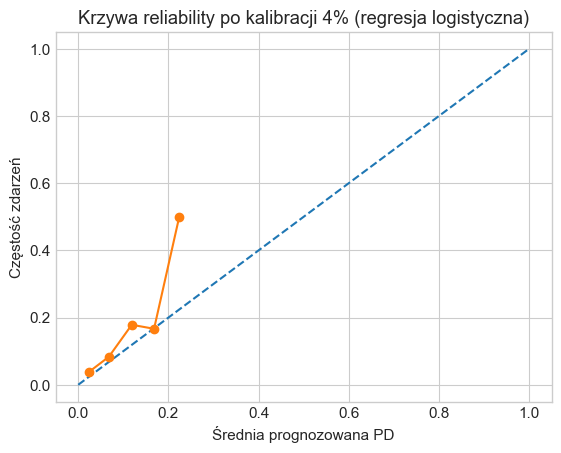

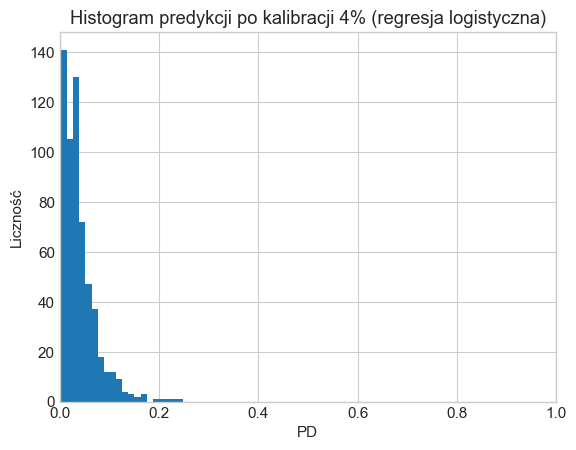

In [110]:
# Walidacja (Post-Cal)

# Średnie prawdopodobieństwo defaultu (oczekujemy 4%)
print(f"Średnie PD (Cel: 4.00%): {p_val_lr_final.mean():.6f}")

# ECE - Expexted Calibration Error
ece_post_cal = expected_calibration_error(y_val.values, p_val_lr_final)
print(f"ECE (Post-Cal): {ece_post_cal:.4f}")

# Brier Score
print("Dekompozycja Brier Score Post-Cal")
decomposition_lr_cal = brier_decomposition(y_val.values, p_val_lr_final)
print(pd.Series(decomposition_lr_cal))

# Kzywa reliabaility i histogram predykcji
reliability_plot(y_val, p_val_lr_final, "Krzywa reliability po kalibracji 4% (regresja logistyczna)")
hist_predictions(p_val_lr_final, "Histogram predykcji po kalibracji 4% (regresja logistyczna)")

#### Stabilność per podgrupa (Post-Cal)
- Mierzy ECE i Średnie PD dla dwóch podgrup na podstawie podziału cechy bazowej.
- Podział na 2 grupy według mediany - < i > niż mediana danej cechy
- Oczekujemy dla każdej podgrupy PD ok 4% i małego ECE - żeby te dobre wyniki były nie tylko globalne
- Bierzemy top 10 najważniejszych cech z regresji logistycznej
- Na zbiorze walidacyjnym

In [65]:
def check_subgroup_stability(model_predictions, X_val, y_val, target_feature):
    
    split_value = X_val[target_feature].median()
    
    # Podział danych na dwie grupy (mniejsze/większe niż mediana) (maski logiczne - True/False)
    group_1_mask = X_val[target_feature] <= split_value
    
    # Grupa 1
    y_g1 = y_val[group_1_mask.values]
    p_g1 = model_predictions[group_1_mask.values]
    
    # Grupa 2
    y_g2 = y_val[~group_1_mask.values]
    p_g2 = model_predictions[~group_1_mask.values]

      
    results = {}
    
    for name, y_g, p_g in [
        (f'{target_feature} <= {split_value:.4f}', y_g1, p_g1),
        (f'{target_feature} > {split_value:.4f}', y_g2, p_g2)]:
        
        if len(y_g) > 0:
            ece = expected_calibration_error(y_g, p_g)
            avg_pd = np.mean(p_g)
            
            results[name] = {'Średnie PD': avg_pd, 'ECE': ece}
            
    return pd.DataFrame.from_dict(results, orient='index')

for feature in top_10_features:

    subgroup_stability_lr = check_subgroup_stability(
        p_val_lr_final, 
        X_val, 
        y_val.values, 
        feature)

    print(subgroup_stability_lr.apply(lambda x: x.map('{:.4f}'.format)), '\n')

                                             Średnie PD     ECE
Rozliczenia_miedzyokresowe_krotkie <= 0.0000     0.0483  0.0335
Rozliczenia_miedzyokresowe_krotkie > 0.0000      0.0295  0.0341 

                                         Średnie PD     ECE
wsk_struktura_kap_wlasnego_s_1 <= 0.6702     0.0473  0.0307
wsk_struktura_kap_wlasnego_s_1 > 0.6702      0.0327  0.0290 

                                    Średnie PD     ECE
wsk_zysk_operacyjny_zob_2 <= 0.0523     0.0496  0.0417
wsk_zysk_operacyjny_zob_2 > 0.0523      0.0304  0.0250 

                               Średnie PD     ECE
wsk_koszty_przychody <= 0.9844     0.0269  0.0315
wsk_koszty_przychody > 0.9844      0.0531  0.0287 

                     Średnie PD     ECE
Zysk_netto <= 0.0000     0.0509  0.0417
Zysk_netto > 0.0000      0.0268  0.0151 

                              Średnie PD     ECE
wsk_rotacja_zapasow <= 0.0000     0.0453  0.0459
wsk_rotacja_zapasow > 0.0000      0.0319  0.0159 

                                  

Wnioski:
- Wyniki są dobre, model po kalibracji jest stabilny
- ECE: Maksymalny zaobserwowany błąd ECE wynosi 0.0591 (dla wsk_sprzedaz_kap_obrotowy), co mieści się w akceptowalnym zakresie. Świadczy to o stabilności kalibracji.
- Średnie PD dla wszystkich podgrup są bliskie globalnemu celowi 4\%,

## Progi decyzji

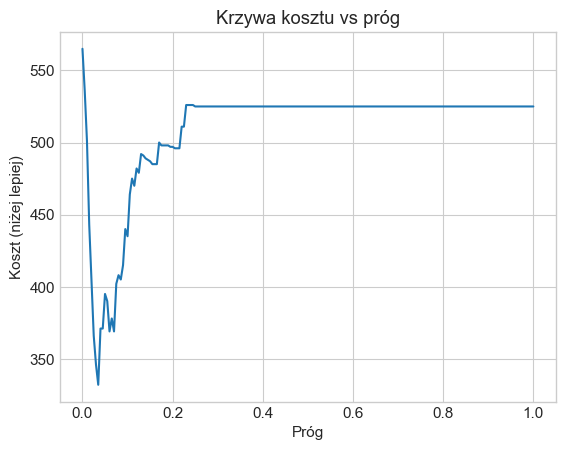

Najlepszy próg: 0.035
TP, FP, FN, TN: 31 272 4 293


In [66]:
# Parametry kosztów 
# True Positive i True Negative traktujemy neutralnie (koszt=0), skupiamy się na stracie, które dadzą nam False Positive (mała) i False Negative (duża)
COST_TP = 0.0     # Zysk z przyznania kredytu bezpiecznemu, ale prognozujemy default (0)
COST_FP = 1.0     # Koszt FP: Utrata zysku z odrzuconego dobrego klienta (niewielki)
COST_FN = 15.0    # Koszt FN: Duża strata z defaultu (klient ryzykowny, przyjęty)
COST_TN = 0.0     # Zysk z poprawnego odrzucenia ryzyka (neutralny)

def cost_for_threshold(y_true, p, thr):
    yhat = (p >= thr).astype(int)
    tp = np.sum((yhat==1) & (y_true==1))
    fp = np.sum((yhat==1) & (y_true==0))
    fn = np.sum((yhat==0) & (y_true==1))
    tn = np.sum((yhat==0) & (y_true==0))
    return tp*COST_TP + fp*COST_FP + fn*COST_FN + tn*COST_TN, tp, fp, fn, tn

def sweep_costs(y_true, p, n=101):
    thrs = np.linspace(0,1,n)
    costs, details = [], []
    for t in thrs:
        c, tp, fp, fn, tn = cost_for_threshold(y_true, p, t)
        costs.append(c); details.append((tp,fp,fn,tn))
    return thrs, np.array(costs), details

thrs, costs, details = sweep_costs(y_val, p_val_lr_final, n=201)
best_idx = int(np.argmin(costs))
best_thr = float(thrs[best_idx])
best_tp, best_fp, best_fn, best_tn = details[best_idx]

plt.figure()
plt.plot(thrs, costs)
plt.title("Krzywa kosztu vs próg")
plt.xlabel("Próg")
plt.ylabel("Koszt (niżej lepiej)")
plt.show()

print("Najlepszy próg:", best_thr)
print("TP, FP, FN, TN:", best_tp, best_fp, best_fn, best_tn)

### Mapowanie PD i rating

col_0,count
row_0,
AAA,96
AA,96
A,250
BBB,99
BB,38
B,17
CCC,4


C:\Users\Uzytkownik\AppData\Local\Temp\ipykernel_3720\934492402.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_pd = pd.DataFrame({"mean_PD": pd.Series(p_val_lr_final).groupby(ratings).mean()})


,mean_PD
AAA,0.005686
AA,0.014477
A,0.034725
BBB,0.063189
BB,0.099241
B,0.144661
CCC,0.224098


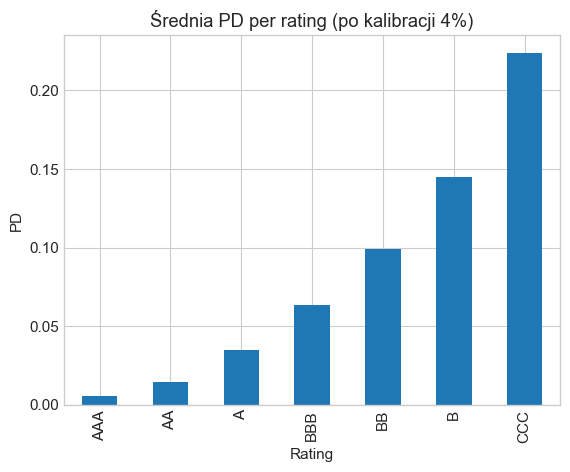

In [67]:
from IPython.display import display
# Progi ratingowe
rating_bins = [0.00, 0.01, 0.02, 0.05, 0.08, 0.12, 0.20, 1.01]
rating_labels = ["AAA","AA","A","BBB","BB","B","CCC"]

def pd_to_rating(p):
    return pd.cut(p, bins=rating_bins, labels=rating_labels, right=False, include_lowest=True)

ratings = pd_to_rating(p_val_lr_final)
tab = pd.crosstab(ratings, columns="count")
display(tab)

# Średnie PD per rating
mean_pd = pd.DataFrame({"mean_PD": pd.Series(p_val_lr_final).groupby(ratings).mean()})
display(mean_pd)

plt.figure()
mean_pd['mean_PD'].plot(kind='bar')
plt.title("Średnia PD per rating (po kalibracji 4%)")
plt.xlabel("Rating")
plt.ylabel("PD")
plt.show()

AAA	- Najbezpieczniejsza grupa

AA - Bardzo bezpieczna

A - Grupa bezpieczna, ale z umiarkowanym PD

BBB	- Pierwsza klasa umiarkowanego/podwyższonego ryzyka

BB - Grupa wyraźnie ryzykowna

B - Grupa wysokiego ryzyka

CCC	- Grupa najwyższego ryzyka (default jest niemal pewny)


Rozkład jest naturalny. Większość klientów trafia do klas bezpiecznych (A i lepsze), najmniejsza liczba obserwacji (4) trafia do najgorszej klasy (CCC).

Kluczowy wymóg monotoniczności został spełniony, średnie PD konsekwentnie rośnie (jak widać na wykresie).

### Ocena jakości modelu po kalibracji i z wyznaczonym progiem decyzyjnym (0.035)

In [68]:
print('Jakość modelu regresji liniowej po kalibracji na zbiorze treningowym')
metryki(y_train, p_train_lr_final, best_thr)

Jakość modelu regresji liniowej po kalibracji na zbiorze treningowym
AUC/ROC:       0.7414
PR-AUC:        0.2034
KS:            0.3506
---------------------------------
Log-Loss:      0.2251
Brier Score:   0.0594
---------------------------------
Accuracy:      0.5433
Recall:        0.8167
Precision:     0.1091


In [69]:
print('Jakość modelu regresji liniowej po kalibracji na zbiorze walidacyjnym')
metryki(y_val, p_val_lr_final, best_thr)

Jakość modelu regresji liniowej po kalibracji na zbiorze walidacyjnym
AUC/ROC:       0.7452
PR-AUC:        0.1750
KS:            0.4220
---------------------------------
Log-Loss:      0.2060
Brier Score:   0.0528
---------------------------------
Accuracy:      0.5400
Recall:        0.8857
Precision:     0.1023


In [70]:
print('Jakość modelu regresji liniowej po kalibracji na zbiorze testowym')
metryki(y_test, p_test_lr_final, best_thr)

Jakość modelu regresji liniowej po kalibracji na zbiorze testowym
AUC/ROC:       0.7471
PR-AUC:        0.2661
KS:            0.3772
---------------------------------
Log-Loss:      0.2181
Brier Score:   0.0574
---------------------------------
Accuracy:      0.5517
Recall:        0.7436
Precision:     0.1007


### Wnioski
- Brak Overfittingu, AUC jest  stabilne na wszystkich trzech zbiorach. Model jest wiarygodny i dobrze uogólnia wiedzę na nowe dane.
- Sukces Kalibracji, Brier Score i Log-Loss są niskie na wszystkich zbiorach, co potwierdza, że kalibracja Platt + korekta 4% zadziałały stabilnie.

Optymalizacja kosztów:
- Wysoki Recall - model jest  dobry w identyfikowaniu i łapaniu przypadków ryzyka (defaultu).
- Niskie Precision - odrzucamy dużo bezpiecznych klientów (więc Precision jest niskie), ale wynika to z ustawionych parametrów kosztu (ustaliliśmy, że przyjęcie ryzykownego klienta jest dużo bardziej kosztowne, niż odrzucenie bezpiecznego).
- Dosyć niskie PR-AUC jest również konsekwencją minimalizacji kosztów oraz nierównowagi klas y

# Ocena jakości XGBoost

In [42]:
y_proba_train_xgb = best_xgb.predict_proba(X_train)[:, 1]
y_proba_test_xgb = best_xgb.predict_proba(X_test)[:, 1]
y_proba_val_xgb = best_xgb.predict_proba(X_val)[:, 1]

y_pred_train_xgb = best_xgb.predict(X_train)
y_pred_test_xgb = best_xgb.predict(X_test)
y_pred_test_xgb = best_xgb.predict(X_val)

In [43]:
print('Jakość modelu XGBoost na zbiorze treningowym')
metryki(y_train, y_proba_train_xgb, 0.5)

Jakość modelu XGBoost na zbiorze treningowym
AUC/ROC:       0.9568
PR-AUC:        0.6324
KS:            0.8190
---------------------------------
Log-Loss:      0.3913
Brier Score:   0.1162
---------------------------------
Accuracy:      0.8756
Recall:        0.9417
Precision:     0.3424


In [44]:
print('Jakość modelu XGBoost na zbiorze walidacyjnym')
metryki(y_val, y_proba_val_xgb, 0.5)

Jakość modelu XGBoost na zbiorze walidacyjnym
AUC/ROC:       0.7328
PR-AUC:        0.1752
KS:            0.4106
---------------------------------
Log-Loss:      0.4361
Brier Score:   0.1364
---------------------------------
Accuracy:      0.8183
Recall:        0.3714
Precision:     0.1300


In [45]:
print('Jakość modelu XGBoost na zbiorze testowym')
metryki(y_test, y_proba_test_xgb, 0.5)

Jakość modelu XGBoost na zbiorze testowym
AUC/ROC:       0.7447
PR-AUC:        0.2353
KS:            0.4295
---------------------------------
Log-Loss:      0.4240
Brier Score:   0.1311
---------------------------------
Accuracy:      0.8317
Recall:        0.3590
Precision:     0.1556


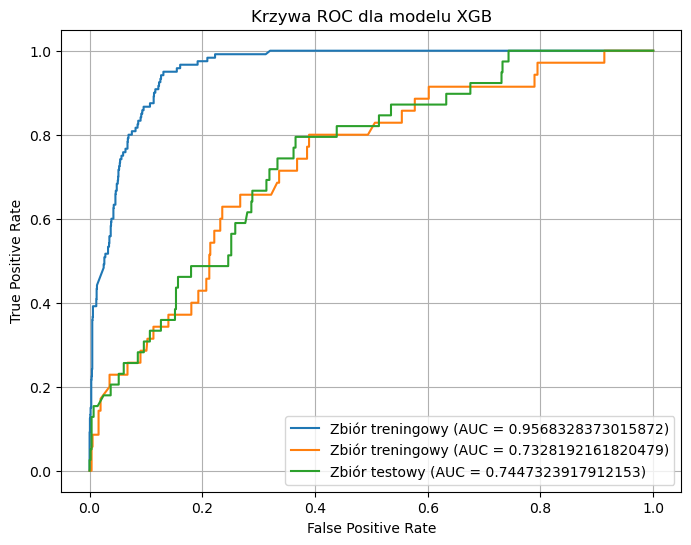

In [49]:
# Wykres krzywej ROC
plt.figure(figsize=(8,6))
plt.plot(roc_curve(y_train, y_proba_train_xgb)[0], roc_curve(y_train, y_proba_train_xgb)[1], label=f"Zbiór treningowy (AUC = {roc_auc_score(y_train, y_proba_train_xgb)})")
plt.plot(roc_curve(y_val, y_proba_val_xgb)[0], roc_curve(y_val, y_proba_val_xgb)[1], label=f"Zbiór treningowy (AUC = {roc_auc_score(y_val, y_proba_val_xgb)})")
plt.plot(roc_curve(y_test, y_proba_test_xgb)[0], roc_curve(y_test, y_proba_test_xgb)[1], label=f"Zbiór testowy (AUC = {roc_auc_score(y_test, y_proba_test_xgb)})")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Krzywa ROC dla modelu XGB')
plt.legend()
plt.grid(True)
plt.savefig('ROC_new.png', dpi=300, bbox_inches='tight')
plt.show()

## Wnioski i ocena modelu
- Model jest przeuczony (widać po różnicy AUC na zbiorze treningowym, walidacyjnym i testowym). Jednak AUC na walidacyjny i testowym jest nadal dosyć duże.
- Duże Log-Loss i Brier-Score - model jest nieskalibrowany, poprawimy to podczas kalibracji i ustalania progu decyzyjnego.
- Priorytetem jest Recall (umiejętność wyłapywania ryzykownych klientów) - na razie niestety dosyć małe.




### XGBoost - najważniejsze cechy (feature_importance)

In [47]:
# Analogicznie jak w regresji logistycznej, trzeba też odzyskać oryginalne nazwy

# Pobranie listy wszystkich cech po ColumnTransformer
feature_names_all_xgb = best_xgb['preprocessing'].get_feature_names_out()

# Filtrowanie przez VarianceThreshold 
# Mogło powstać dużo stałych kolumn w wyniku onehotencoder
variance_filter_xgb = best_xgb['variance_filter']
variance_mask_xgb = variance_filter_xgb.get_support()
feature_names_retained_xgb = feature_names_all_xgb[variance_mask_xgb]
len(feature_names_retained_xgb)

# Filtrowanie przez SelectFpr
selector_xgb = best_xgb['stat_feature_selector']
support_mask_final_xgb = selector_xgb.get_support()
feature_names_final_xgb = feature_names_retained_xgb[support_mask_final_xgb]
len(feature_names_final_xgb)

# Ważność cech
importances = best_xgb['model'].feature_importances_

xgb_importance_df = pd.DataFrame({
    'Feature': feature_names_final_xgb, # Wewnętrzne nazwy, np. 'numeric_preprocessing__12'
    'Importance': importances           # Wagi ważności XGBoost
}).sort_values('Importance', ascending=False)

# Używam tego samego słownika ID_TO_NAME_MAP stworzonego dla LogReg

xgb_importance_df['Numeric_ID_Str'] = (
    xgb_importance_df['Feature']
    .astype(str)
    # Usuwamy prefiksy
    .str.replace('numeric_preprocessing__', '')
    .str.replace('categorical_preprocessing__', '')
)

# Mapowanie na Nazwy Słowne
xgb_importance_df['Final_Feature_Name'] = xgb_importance_df.apply(map_name, axis=1)


# Finalne top 10 cech
print("\nTOP 10 WAŻNOŚCI CECH XGBOOST (Oryginalne Nazwy)")
# Sortowanie według ważności (Importance) XGBoost
print(xgb_importance_df[['Final_Feature_Name', 'Importance']].sort_values(
    by='Importance', 
    ascending=False
).head(10))

NameError: name 'map_name' is not defined

In [77]:
# lista top 10 cech (przyda się później)
top_10_features_xgb = xgb_importance_df[['Final_Feature_Name', 'Importance']].sort_values(
    by='Importance', 
    key=lambda x: np.abs(x), 
    ascending=False
).head(10)['Final_Feature_Name'].tolist()

In [78]:
top_10_features_xgb

['wsk_koszty_przychody',
 'Rozliczenia_miedzyokresowe_krotkie',
 'wsk_rent_kapitalu',
 'koszty_finansowe',
 'wsk_zadluzenia_dlugie',
 'koszty_odsetki',
 'wsk_zob_oprocentowanych',
 'wsk_struktura_kap_wlasnego_2',
 'wsk_rotacja_aktywow_2',
 'Inwestycje_krotkoterminowe']

# Kalibracja modelu XGBoost

In [79]:
# Różne potrzebne funkcje utworzone wcześniej przy kalibracji regresji

ECE: 0.2615


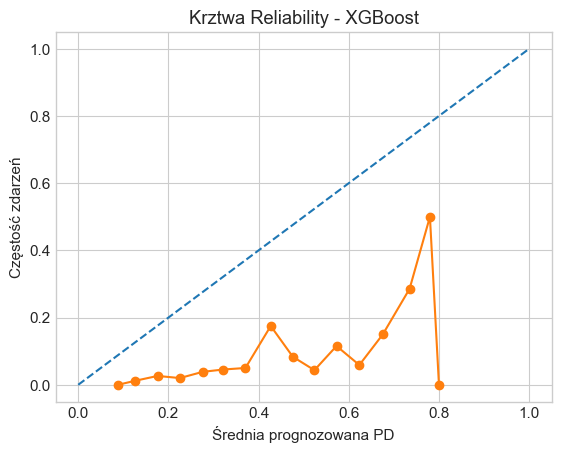

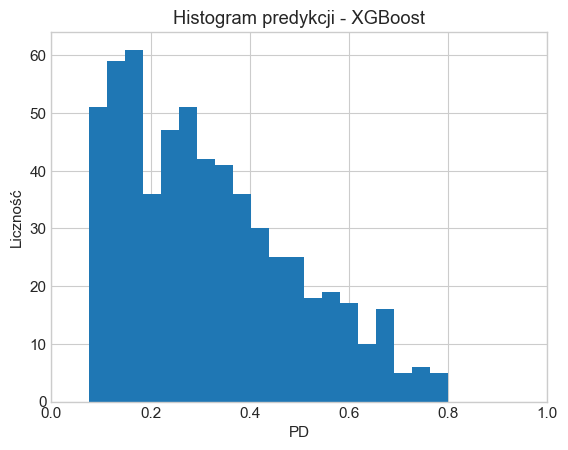

Dekompozycja Brier Score Pre-Cal
Brier_Score          0.136431
Uncertainty          0.054931
Resolution           0.002514
Reliability_Error    0.085398
dtype: float64


In [113]:
# ECE - Expected Calibration Error
ece_xgb = expected_calibration_error(y_val, y_proba_val_xgb)
print(f"ECE: {ece_xgb:.4f}")

# Krzywa reliability
reliability_plot(y_val, y_proba_val_xgb, "Krztwa Reliability - XGBoost")

# Histogram predykcji
hist_predictions(y_proba_val_xgb, "Histogram predykcji - XGBoost")

# Brier Score
print("Dekompozycja Brier Score Pre-Cal")
decomposition_xgb = brier_decomposition(y_val, y_proba_val_xgb)
print(pd.Series(decomposition_xgb))

- ECE wysoki, ale lepszy niż w regresji. Nadal konieczność kalibracji
- Krzywa reliability: Tak jak w przypadku regresji leży poniżej linii idealnej kalibracji - niedoszacowanie ryzyka, model bardzo ostrożny.
- Histogram predykcji: lepszy niż w pzypadku regresji liniowej - większość predykcji skoncentrowana blisko 0.1, 0.2
- Brier Score i Reliability_Error duże, ale lepsze niż dla regresji

Model wejściowy jest nieco lepszy niż regresja, ale i tak trzeba go koniecznie skalibrować.

#### Kalibracja lokalna isotonic
W tym przypadku będzie lepsza niż Platt (sigmoid), bo XGBoost jest modelem nieliniowym.

In [81]:
xgb_model_cal = CalibratedClassifierCV(estimator=best_xgb, method="isotonic", cv="prefit")
xgb_model_cal.fit(X_val, y_val)

p_train_xgb_cal = xgb_model_cal.predict_proba(X_train)[:,1]
p_val_xgb_cal = xgb_model_cal.predict_proba(X_val)[:,1]
p_test_xgb_cal = xgb_model_cal.predict_proba(X_test)[:,1]

ece_iso = expected_calibration_error(y_val, p_val_xgb_cal)

print(f"ECE isotonic: {ece_iso:.4f}")

C:\Users\Uzytkownik\anaconda3\Lib\site-packages\sklearn\calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


ECE isotonic: 0.0000


#### Calibration-in-the-large i walidacja Post-Cal

In [82]:
# Obliczenie stałej przesunięcia na podstawie zbioru walidacyjnego
global_shift_xgb = get_global_shift(p_val_xgb_cal, target_mean=0.04)

# Zastosowanie tego sameo stałego przesunięcia do wszystkich zbiorów

# Aplikacja na zbiorze Treningowym
z_train_xgb = logit_fn(p_train_xgb_cal)
p_train_xgb_final = inv_logit(z_train_xgb + global_shift_xgb)

# Aplikacja na zbiorze Walidacyjnym
z_val_xgb = logit_fn(p_val_xgb_cal)
p_val_xgb_final = inv_logit(z_val_xgb + global_shift_xgb)

# Aplikacja na zbiorze Testowym
z_test_xgb = logit_fn(p_test_xgb_cal)
p_test_xgb_final = inv_logit(z_test_xgb + global_shift_xgb)

Średnie PD (Cel: 4.00%): 0.040000
ECE (Post-Cal): 0.0183
Dekompozycja Brier Score Post-Cal
Brier_Score          0.050996
Uncertainty          0.054931
Resolution           0.004125
Reliability_Error    0.001236
dtype: float64


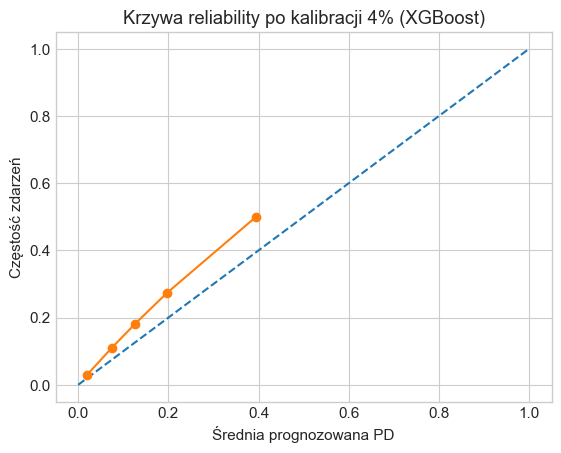

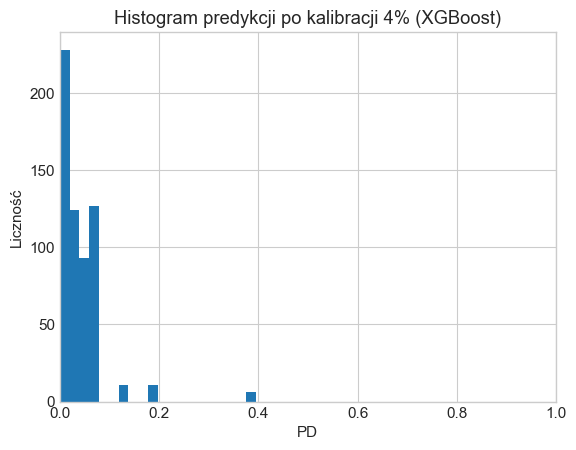

In [116]:
# Walidacja (Post-Cal)

# Średnie prawdopodobieństwo defaultu (4%)
print(f"Średnie PD (Cel: 4.00%): {p_val_xgb_final.mean():.6f}")

# ECE - Expexted Calibration Error
ece_post_cal = expected_calibration_error(y_val.values, p_val_xgb_final)
print(f"ECE (Post-Cal): {ece_post_cal:.4f}")

# Brier Score - dekompozycja
print("Dekompozycja Brier Score Post-Cal")
decomposition_xgb = brier_decomposition(y_val, p_val_xgb_final)
print(pd.Series(decomposition_xgb))

# Kzywa reliabaility i histogram predykcji
reliability_plot(y_val, p_val_xgb_final, "Krzywa reliability po kalibracji 4% (XGBoost)")
hist_predictions(p_val_xgb_final, "Histogram predykcji po kalibracji 4% (XGBoost)")

#### Stabilność per podgrupa (Post-Cal)
- Mierzy ECE i Średnie PD dla dwóch podgrup na podstawie podziału cechy bazowej.
- Podział na 2 grupy według mediany - < i > niż mediana danej cechy
- Oczekujemy dla każdej podgrupy PD ok 4% i małego ECE - żeby te dobre wyniki były nie tylko globalne
- Bierzemy top 10 najważniejszych cech dla modelu XGBost
- Mamy już wcześniej zdefiniowaną funkcję check_subgroupstability i mamy top_10_features_xgb
- Zbiór walidacyjny

In [84]:
for feature in top_10_features_xgb:

    subgroup_stabilty_xgb = check_subgroup_stability(
        p_val_xgb_final, 
        X_val, 
        y_val.values, 
        feature)

    print(subgroup_stabilty_xgb.apply(lambda x: x.map('{:.4f}'.format)), '\n')

                               Średnie PD     ECE
wsk_koszty_przychody <= 0.9844     0.0259  0.0231
wsk_koszty_przychody > 0.9844      0.0541  0.0239 

                                             Średnie PD     ECE
Rozliczenia_miedzyokresowe_krotkie <= 0.0000     0.0518  0.0213
Rozliczenia_miedzyokresowe_krotkie > 0.0000      0.0251  0.0236 

                            Średnie PD     ECE
wsk_rent_kapitalu <= 0.5238     0.0472  0.0262
wsk_rent_kapitalu > 0.5238      0.0328  0.0165 

                           Średnie PD     ECE
koszty_finansowe <= 1.8400     0.0479  0.0254
koszty_finansowe > 1.8400      0.0321  0.0179 

                                Średnie PD     ECE
wsk_zadluzenia_dlugie <= 0.0000     0.0449  0.0240
wsk_zadluzenia_dlugie > 0.0000      0.0237  0.0230 

                         Średnie PD     ECE
koszty_odsetki <= 0.0000     0.0470  0.0264
koszty_odsetki > 0.0000      0.0294  0.0187 

                                  Średnie PD     ECE
wsk_zob_oprocentowanych <= 0.

To są dobre wyniki, takie jakie chcieliśmy mieć po kalibracji, model jest stabilny.

## Progi decyzji

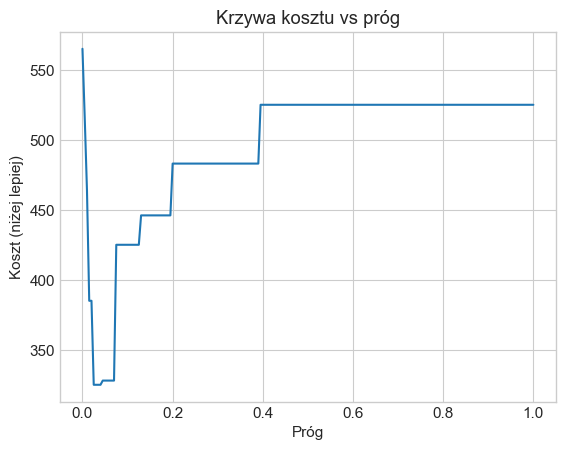

Najlepszy próg: 0.025
TP, FP, FN, TN: 28 220 7 345


In [85]:
# Parametry kosztów takie same jak dla regresji, funkcje zdefiniowane wcześniej

thrs2, costs2, details2 = sweep_costs(y_val, p_val_xgb_final, n=201)
best_idx2 = int(np.argmin(costs2))
best_thr2 = float(thrs2[best_idx2])
best_tp2, best_fp2, best_fn2, best_tn2 = details2[best_idx2]

plt.figure()
plt.plot(thrs2, costs2)
plt.title("Krzywa kosztu vs próg")
plt.xlabel("Próg")
plt.ylabel("Koszt (niżej lepiej)")
plt.show()

print("Najlepszy próg:", best_thr2)
print("TP, FP, FN, TN:", best_tp2, best_fp2, best_fn2, best_tn2)

### Mapowanie PD i rating

col_0,count
row_0,
AAA,117
AA,111
A,217
BBB,127
B,22
CCC,6


C:\Users\Uzytkownik\AppData\Local\Temp\ipykernel_3720\2128553502.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_pd2 = pd.DataFrame({"mean_PD": pd.Series(p_val_xgb_final).groupby(ratings2).mean()})


,mean_PD
AAA,0.005596
AA,0.011811
A,0.030569
BBB,0.074676
BB,NaN
B,0.161382
CCC,0.394447


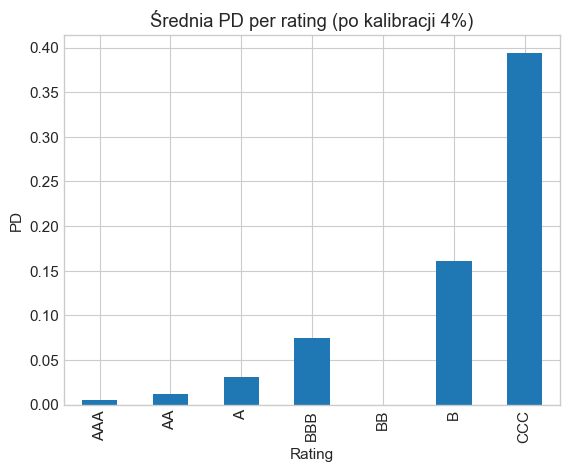

In [86]:
ratings2 = pd_to_rating(p_val_xgb_final)
tab2 = pd.crosstab(ratings2, columns="count")
display(tab2)

# Średnie PD per rating
mean_pd2 = pd.DataFrame({"mean_PD": pd.Series(p_val_xgb_final).groupby(ratings2).mean()})
display(mean_pd2)

plt.figure()
mean_pd2['mean_PD'].plot(kind='bar')
plt.title("Średnia PD per rating (po kalibracji 4%)")
plt.xlabel("Rating")
plt.ylabel("PD")
plt.show()

Monotoniczność ryzyka jest zachowana (ryzyko rośnie - widać na wykresie) - brak obserwacji w klasie BB tego nie wyklucza, po prostu model przekierował tych klientów do kolejnej klasy B, ale ryzyko nadal się zwiększa)

Podobnie jak w przypadku regresji większość klientów trafiła do klas bezpiecznych (A i lepsze). Tutaj jednak nieco więcej klientów trafiło do klas większego ryzyka niż w regresji.

### Ocena jakości modelu po kalibracji i z wyznaczonym progiem decyzyjnym (0.025)

In [87]:
print('Jakość modelu XGBoost po kalibracji na zbiorze treningowym')
metryki(y_train, p_train_xgb_final, best_thr2)

Jakość modelu XGBoost po kalibracji na zbiorze treningowym
AUC/ROC:       0.9349
PR-AUC:        0.4966
KS:            0.7708
---------------------------------
Log-Loss:      0.1665
Brier Score:   0.0493
---------------------------------
Accuracy:      0.6556
Recall:        1.0000
Precision:     0.1622


In [88]:
print('Jakość modelu XGBoost po kalibracji na zbiorze walidacyjnym')
metryki(y_val, p_val_xgb_final, best_thr2)

Jakość modelu XGBoost po kalibracji na zbiorze walidacyjnym
AUC/ROC:       0.7685
PR-AUC:        0.1812
KS:            0.4106
---------------------------------
Log-Loss:      0.1959
Brier Score:   0.0510
---------------------------------
Accuracy:      0.6217
Recall:        0.8000
Precision:     0.1129


In [89]:
print('Jakość modelu XGBoost po kalibracji na zbiorze testowym')
metryki(y_test, p_test_xgb_final, best_thr2)

Jakość modelu XGBoost po kalibracji na zbiorze testowym
AUC/ROC:       0.7399
PR-AUC:        0.1774
KS:            0.4063
---------------------------------
Log-Loss:      0.2230
Brier Score:   0.0579
---------------------------------
Accuracy:      0.6200
Recall:        0.7949
Precision:     0.1235


#### Wnioski

- Przeuczenie (overfitting) jest widoczne, model za bardzo dopasował się do danych treningowych (widać po dużej róznicy wartości AUC). Mimo to model dobrze uogólnia, wyniki na zbiorze walidacyjnym oraz testowym są dosiebie zbliżone i są dosyć dobre.
- Sukces kalibracji: mamy niskie Brier-Score oraz Log-Loss dla wszystkich zbiorów.
  
Optymalizacja kosztów:
- Podobnie jak w przypdku regresji logistycznej, priorytetem jest Recall, który jest wysoki na wszystkich trzech zbiorach. Oznacza to, że model jest skuteczny w identyfikowaniu i łapaniu przypadków ryzyka (defaultu), co było naszym priorytetem.
- Niskie Precision jest bezpośrednią konsekwencją minimalizacji kosztów.
- Z niskim progiem decyzyjnym (0.025) model świadomie akceptuje klasyfikację wielu bezpiecznych klientów jako ryzykownych (False Positives), aby tylko nie przegapić drogiego przypadku defaultu (False Negative)
- Niskie PR-AUC również jest konsekwencją tego kompromisu.

# Analiza wyjaśnialności i interpretowalności modelu black-box
### SHAP 
Do liczenia, jak każda cecha wpłynęła na predykcję.

In [ ]:
import shap
#shap robimy na danych przed kalibracja, zeby zrozumiec co mysli o danych zanim zostana one wygladzone przez kalibracje

In [ ]:
# 1. Wyciągamy preprocessor z modelu
preprocessor = best_xgb[:-1]

# 2. Tłumaczymy X_test na język liczb (Transformacja)
X_test_shap = pd.DataFrame(preprocessor.transform(X_test), columns=preprocessor.get_feature_names_out())

In [ ]:
# 1.Definiujemy funkcję, która robi predykcję
# SHAP będzie jej używał nie wnikając co jest w środku, metoda z 
# laboratorium nie dzialala przez blad z zamiana string na float
model_xgb_pipeline = best_xgb.steps[-1][1] #pobranie modelu
feature_names = preprocessor.get_feature_names_out()

def predict(X):
    #X to dane przetworzone, więc musimy je zamienić na format XGBoost
    #używamy predict_proba (dla klasy 1)
    return model_xgb_pipeline.predict_proba(X)[:, 1]

# 2.Używamy PermutationExplainer 
#podajemy małą próbkę tła (background), żeby było szybciej
bd_data = X_test_shap.sample(n=50, random_state=42) 
explainer = shap.Explainer(predict, bd_data)

# 3.Liczymy SHAP
shap_values = explainer(X_test_shap)

# 4.Wykresy
plt.figure()
shap.plots.beeswarm(shap_values, max_display=15)
plt.show()

#dostajemy nazwy zmiennych po preprocessingu, musimy zamienic je

In [ ]:
print(X_test_shap.columns.tolist()) #juz na etapie pipelineu zgubilismy nazwy zmiennych 

In [ ]:
 X_test.info()

In [ ]:
X_test_shap.info()

In [ ]:
#mamy rozne liczby kolumn

In [ ]:
#nazwy z pipeline'a bez numeric_preprocessing_
preprocessor = best_xgb[:-1]
raw_names = preprocessor.get_feature_names_out()
clean_names = [name.split('__')[-1] for name in raw_names]
print(clean_names)
shap_values.feature_names = clean_names

In [ ]:
kolumny_z_X = ['szczegolnaFormaPrawna_Symbol',
 'formaWlasnosci_Symbol',
 'pkdKod',
 'wsk_liczba_dni_istnienia',
 'Aktywa',
 'Aktywa_trwale',
 'Wartosci_niematerialne_prawne',
 'Wartosc_firmy',
 'Rzeczowe_aktywa_trwale',
 'Srodki_trwale',
 'Naleznosci_dlugoterminowe',
 'Inwestycje_dlugoterminowe',
 'Rozliczenia_miedzyokresowe_dlugie',
 'Aktywa_obrotowe',
 'Zapasy',
 'Naleznosci_krotkoterminowe',
 'Naleznosci_dostaw_uslug_12m_powiazane',
 'Naleznosci_dostaw_uslug_pow12m_powiazane',
 'Naleznosci_dostaw_uslug_12m_kapitale',
 'Naleznosci_dostaw_uslug_pow12m_kapitale',
 'Naleznosci_dostaw_uslug_12m_pozostale',
 'Naleznosci_dostaw_uslug_pow12m_pozostale',
 'Naleznosci_dostaw_uslug_pozostale_sadowe',
 'Inwestycje_krotkoterminowe',
 'Srodki_pieniezne',
 'Rozliczenia_miedzyokresowe_krotkie',
 'Kapital_wlasny',
 'Kapital_podstawowy',
 'Kapital_zapasowy',
 'Zysk_netto',
 'Zobowiazania_rezerwy',
 'Rezerwy_na_zobowiazania',
 'Rezerwa_z_tytulu_odroczonego_podatku_dochodowego',
 'Rezerwa_na_swiadczenia_emerytalne',
 'Rezerwa_na_swiadczenia_emerytalne_dlugie',
 'Rezerwa_na_swiadczenia_emerytalne_krotkie',
 'Pozostale_rezerwy',
 'Pozostale_rezerwy_krotkie',
 'Zobowiazania_dlugoterminowe',
 'Kredyty_pozyczki_dlugie',
 'Inne_zobowiazania_fin_dlugoterminowe',
 'Zobowiazania_krotkoterminowe',
 'Zobowiazania_dostaw_uslug_12m_powiazane',
 'Zobowiazania_dostaw_uslug_pow12m_powiazane',
 'Zobowiazania_dostaw_uslug_12m_kapitale',
 'Zobowiazania_dostaw_uslug_pow12m_kapitale',
 'Kredyty_pozyczki_krotkie',
 'Inne_zobowiazania_fin_krotkoterminowe',
 'Zobowiazania_dostaw_uslug_12m_pozostale',
 'Zobowiazania_dostaw_uslug_pow12m_pozostale',
 'Rozliczenia_miedzyokresowe_b',
 'Ujemna_wartosc_firmy',
 'Inne_rozliczenia_miedzyokresowe',
 'Inne_rozliczenia_miedzyokresowe_dlugie',
 'Inne_rozliczenia_miedzyokresowe_krotkie',
 'schemat_wsk_bilans',
 'Naleznosci_dostaw_uslug_12m',
 'Naleznosci_dostaw_uslug_pow12m',
 'Zobowiazania_dostaw_uslug_12m',
 'Zobowiazania_dostaw_uslug_pow12m',
 'Kredyty_pozyczki',
 'wsk_kapital_do_aktywa',
 'przychody_sprzedazy',
 'koszty_sprzedanych_produktow',
 'koszty_sprzedazy',
 'koszty_ogolnego_zarzadu',
 'zysk_sprzedazy',
 'pozostale_przychody_oper',
 'dotacje',
 'koszty_operacyjne_pozostale',
 'zysk_operacyjny',
 'przychody_finansowe',
 'dywidendy_udzialy',
 'przychody_odsetki',
 'koszty_finansowe',
 'koszty_odsetki',
 'zysk_brutto',
 'podatek_dochodowy',
 'zysk_netto',
 'koszty_operacyjne',
 'amortyzacja',
 'przychody',
 'wsk_amortyzacja',
 'wsk_koszty_operacyjne',
 'wsk_Zobowiazania_krotkoterminowe',
 'wsk_Zobowiazania_dlugoterminowe',
 'wsk_marza_brutto_1',
 'wsk_marza_brutto_2',
 'wsk_stopa_marzy_brutto',
 'wsk_rent_operacyjna',
 'wsk_ROS',
 'wsk_ROA',
 'wsk_s_ROA',
 'wsk_rent_operacyjna_aktywow',
 'wsk_ROE',
 'wsk_s_ROE',
 'wsk_mnoznik_kap_wl',
 'wsk_zwrot_aktywa_trwale',
 'wsk_rent_kaptial_podstawowy',
 'wsk_akt_generowania_got_1',
 'wsk_rent_sprzedazy',
 'wsk_ebit',
 'wsk_ebitda_1',
 'wsk_ebitda_2',
 'wsk_ebitda_3',
 'wsk_marza_ebitda_1',
 'wsk_marza_ebitda_2',
 'wsk_marza_ebitda_3',
 'wsk_marza_ebit',
 'wsk_ebitda_aktywa_1',
 'wsk_ebitda_aktywa_2',
 'wsk_ebitda_aktywa_3',
 'wsk_zwrot_aktywa_mat',
 'wsk_zysk_zobowiazania',
 'wsk_zysk_op_zobowiazania',
 'wsk_sprzedaz_kap_obrotowy',
 'wsk_koszty_przychody',
 'wsk_rent_kapitalu',
 'wsk_stopa_zysku_sprzedaz',
 'wsk_pokrycie_wyd_fin_gotowkowe_1',
 'wsk_koszt_długu_1',
 'wsk_koszt_długu_2',
 'wsk_pokrycie_aktywow_tr_kapitalem_st',
 'wsk_struktury_finansowania',
 'wsk_pokrycie_zob_kr_gotowkowe_1',
 'wsk_zysk_operacyjny_zob_1',
 'wsk_zysk_operacyjny_zob_2',
 'wsk_zadluzenia_gotowki_1',
 'wsk_koszty_fin_przychody',
 'wsk_koszty_odsetki_przychody',
 'wsk_zadluzenie_gotowka',
 'wsk_udzial_kap_wlasnego_aktywa_1',
 'wsk_udzial_kap_wlasnego_aktywa_2',
 'wsk_ogolnego_zadluzenia_1',
 'wsk_ogolnego_zadluzenia_2',
 'wsk_pokrycie_aktywow_kap_stalym',
 'wsk_zadluzenie_kap_wlasnego',
 'wsk_ogolnego_zadluzenia_pozyczki',
 'wsk_zadluzenia_pozyczki_dlugie',
 'wsk_zadluzenia_dlugie',
 'wsk_zadluzenia_krotkie',
 'wsk_pokrycia_zobowiazan_rz_aktywami_trwalymi',
 'wsk_ROE_brutto',
 'wsk_ROA_operacyjny',
 'wsk_efekt_dzwigni_fin_1',
 'wsk_efekt_dzwigni_fin_2',
 'wsk_pokrycia_odsetek_zyskiem',
 'wsk_ebitda_koszty_odsetkowe_1',
 'wsk_ebitda_koszty_odsetkowe_2',
 'wsk_ebitda_koszty_odsetkowe_3',
 'wsk_ebitda_koszty_finansowe_1',
 'wsk_ebitda_koszty_finansowe_2',
 'wsk_ebitda_koszty_finansowe_3',
 'wsk_ebitda_zobowiazan_odsetki_1',
 'wsk_ebitda_zobowiazan_odsetki_2',
 'wsk_ebitda_zobowiazan_odsetki_3',
 'wsk_ebitda_zobowiazan_odsetki_4',
 'wsk_ebitda_zobowiazan_1',
 'wsk_ebitda_zobowiazan_2',
 'wsk_ebitda_zobowiazan_3',
 'wsk_rotacja_aktywow_1',
 'wsk_rotacja_aktywow_2',
 'wsk_rotacja_rz_aktywow_trwalych',
 'wsk_rotacja_wartosci_niewaterialnych',
 'wsk_rotacja_zapasow',
 'wsk_rotacja_naleznosci',
 'wsk_rotacja_naleznosci_dostaw_uslug',
 'wsk_cykl_operacyjny',
 'wsk_poziom_kosztow_operacyjnych',
 'wsk_poziom_kosztow_finansowych',
 'wsk_obrotowsci_naleznosci',
 'wsk_rotacja_zobowiazan',
 'wsk_rotacja_zobowiazan_dostaw_uslug',
 'wsk_cykl_konwersji_gotowki',
 'wsk_plynnosc_biez_1',
 'wsk_plynnosc_biez_2',
 'wsk_plynnosc_biez_3',
 'wsk_plynnosc_szybka_1',
 'wsk_plynnosc_szybka_2',
 'wsk_plynnosc_gotowkowa_1',
 'wsk_poziom_kapitalu_obrotowego_netto',
 'wsk_udzial_kapitalu_obrotowego_netto',
 'wsk_udzial_zob_biez_sprzedaz_1',
 'wsk_udzial_zob_biez_sprzedaz_2',
 'wsk_udzial_zob_biez_aktywa_1',
 'wsk_udzial_zob_biez_aktywa_2',
 'wsk_udzial_zapasy_zobowiazania',
 'wsk_udzial_zapasy_kap_obrotowy',
 'wsk_udzial_kap_obrotowego_w_fin',
 'wsk_zysk_ebitda_1',
 'wsk_zysk_ebitda_2',
 'wsk_zysk_ebitda_3',
 'wsk_obrotowosc_gotowkowa',
 'wsk_struktura_majatku',
 'wsk_struktury_kapitalu',
 'wsk_zast_kapitalu_wlasnego',
 'wsk_zast_kapitalu_podstawowego',
 'wsk_zast_kapitalu_stalego',
 'wsk_zast_kapitalu_obcego',
 'wsk_sytuacji_fin',
 'wsk_struktura_kap_wlasnego_1',
 'wsk_struktura_kap_wlasnego_2',
 'wsk_struktura_kap_wlasnego_s_1',
 'wsk_struktura_kap_wlasnego_s_2',
 'wsk_zadluzenia',
 'wsk_zob_dlugoterminowe_aktywa_rzeczowe',
 'wsk_zob_oprocentowanych',
 'wsk_zob_oprocentowanych_aktywa_rzeczowe',
 'wsk_struktura_kap_obcego_s',
 'wsk_zob_s_aktywa_rzeczowe',
 'wsk_fin_majatku_kapitalem']

In [ ]:
#podmieniamy nazwy w shap
current_names = shap_values.feature_names
real_names = []

for name in current_names:
    idx = int(name)
    real = kolumny_z_X[idx]
    real_names.append(real)

shap_values.feature_names = real_names

In [ ]:
#mamy juz pomienione nazwy to teraz te wykresy z shap jeszcze
# Beeswarm - pokazuje kierunek (czy cecha podnosi, czy obniża ryzyko) i rozkład (jak działają wartości skrajne)
plt.figure(figsize=(12, 10))
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.title("Wpływ cech na ryzyko", fontsize=16)
plt.tight_layout()
#plt.savefig('beeswarm.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Dependence plot dla najważniejszej cechy
#szukanie cechy o najwazniejszym wplywie
top_idx = shap_values.abs.mean(0).values.argsort()[-1]
top_name = real_names[top_idx]

print(f"Wykres zależności będzie dla dla: {top_name}")
plt.figure(figsize=(12, 10))
shap.plots.scatter(shap_values[:, top_name], color=shap_values)
#plt.savefig('dependence.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Summary - czysty ranking ważności
plt.figure(figsize=(10, 8))
shap.plots.bar(shap_values, max_display=15, show=False)
plt.title("Globalna Ważność Cech (SHAP Bar Plot)", fontsize=16)
plt.tight_layout()
#plt.savefig('summary.png', dpi=300, bbox_inches='tight')
plt.show()

### Wnioski z analizy ważności cech (SHAP Global)
1. Hierarchia czynników ryzyka (Top Features) Model zidentyfikował efektywność zarządzania kapitałem obrotowym jako absolutnie kluczowy predyktor ryzyka.

Lider (wsk_sprzedaz_kap_obrotowy): Najważniejszą zmienną jest relacja sprzedaży do kapitału obrotowego. Oznacza to, że model premiuje firmy, które  generują wysoką sprzedaż przy zaangażowaniu optymalnych zasobów. Jest to miara sprawności operacyjnej.

Co to oznacza biznesowo? Dla modelu ważniejsze od tego, "ile firma ma majątku", jest to, "jak sprawnie tym majątkiem obracaja". Firmy z zamrożonym kapitałem (zatory płatnicze, zalegające zapasy) są oceniane jako bardziej ryzykowne.

2. Kierunek wpływu (Beeswarm Plot) Analizując rozkład punktów dla lidera (wsk_sprzedaz_kap_obrotowy):

Wysoka efektywność (Czerwone punkty): Zazwyczaj znajdują się po lewej stronie (ujemny SHAP).

Wniosek: Firmy, które efektywnie wykorzystują kapitał obrotowy (wysoki wskaźnik), otrzymują niższą ocenę ryzyka (PD). Model nagradza płynność operacyjną.

Niska efektywność (Niebieskie punkty): Znajdują się po prawej stronie.

Wniosek: Niski obrót kapitałem (czyli np. pieniądze zamrożone w niesprzedanych towarach lub u dłużników) jest silnym sygnałem ostrzegawczym, drastycznie podnoszącym przewidywane ryzyko upadłości.

3. Profil Modelu Twój model ma charakter efektywnościowy. W odróżnieniu od prostych modeli bazujących tylko na zadłużeniu, ten "black-box" (XGBoost) nauczył się wyłapywać subtelniejsze problemy operacyjne. Firma może być rentowna "na papierze", ale jeśli jej kapitał obrotowy stoi w miejscu (wsk_sprzedaz_kap_obrotowy niski), model słusznie podniesie alarm przed potencjalną utratą płynności.

### LIME
Też wykonujemy na modelu przed kalibracją

In [ ]:
import lime
import lime.lime_tabular

In [ ]:
# 1. Wyciągamy Preprocessor i Klasyfikator
preprocessor = best_xgb[:-1]       
classifier = best_xgb.steps[-1][1] 

# 2. Przetwarzamy dane na liczby, LIME musi dostać macierz liczb, żeby móc generować szum
X_train_lime = preprocessor.transform(X_train)
X_test_lime = preprocessor.transform(X_test)

# 3. Czyscimy nazwy cech 
raw_names = preprocessor.get_feature_names_out()
feature_names_lime_mapped = []

for name in raw_names:
    #czyscimy nazwy tak zeby zostaly tylko liczby w nich
    clean_name_temp = name.split('__')[-1]
    
    idx = int(clean_name_temp)
    real_name = kolumny_z_X[idx]
    feature_names_lime_mapped.append(real_name)


# 4. Inicjalizacja Explainera LIME 
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_lime,        # Podajemy przetworzone liczby
    feature_names=feature_names_lime_mapped,  # Podajemy wyczyszczone nazwy
    class_names=['Spłaca (0)', 'Default (1)'], 
    mode='classification',
    random_state=42
)

# 5. Funkcja predykcji
# Ponieważ dane są już przetworzone, podajemy je prosto do klasyfikatora
predict_lime = classifier.predict_proba

# Wybór ciekawych przypadków (tak jak wcześniej)
probs = classifier.predict_proba(X_test_lime)[:, 1]
idx_risky = probs.argmax()                  # Najbardziej ryzykowny
idx_safe = probs.argmin()                   # Najbezpieczniejszy
idx_border = (np.abs(probs - 0.04)).argmin() # Graniczny (blisko 4%)

przypadki = [
    (idx_border, "Klient Graniczny (Borderline)"),
    (idx_risky, "Klient Ryzykowny (High Risk)")
]

In [ ]:
for idx, opis in przypadki:
    #Generujemy wyjaśnienie
    exp = explainer.explain_instance(
        data_row=X_test_lime[idx], 
        predict_fn=predict_lime, 
        num_features=10  #pokaż 10 najważniejszych cech wplywajacych na predykcje
    )
    
    fig = exp.as_pyplot_figure()
    
    #PD (Prawdopodobieństwo Defaultu)
    pd_value = probs[idx]
    plt.title(f"{opis}\nPD: {pd_value:.2%} (LIME Explanation)", fontsize=12)
    plt.xlabel("Wpływ na wynik (W lewo=Spłaca, W prawo=Default)", fontsize=10)
    plt.tight_layout() # Żeby napisy się nie ucinały
    #plt.savefig(f'{opis}.png', dpi=300, bbox_inches='tight')
    plt.show()

### Analiza wyników LIME (Interpretacja Biznesowa)
LIME jest z definicji metodą interpretacji lokalnej. 

To znaczy, że tłumaczy decyzję dla jednego konkretnego klienta

PD = Probability of Default, czyli prawdopodobieństwo niewypłacalności.

Mamy Lime dla dwóch klientów:
1. Klient Graniczny (Borderline) – PD ≈ 7.45%
2. Klient Ryzykowny (High Risk) – PD ≈ 80.78%

Wykres ten pokazuje wpływy cech (feature contributions) w bardziej klasycznym stylu „LIME bar plot”. Czyli analizujemy wpływ na predykcje modelu 10 najwazniejszych cech.

Każdy wykres to zestawienie:
* cech modelu,

* wartości, które te cechy przyjmują dla danego klienta oraz ich wpływ na wynik (czy przesuwają predykcję w stronę Spłaca (0), czy Default (1)).

Interpretacja osi:
* Lewo → zmniejsza ryzyko defaultu / zwiększa szansę spłaty
* Prawo → zwiększa ryzyko defaultu

Kolorystyka:
* Zielone → cechy popychające w kierunku spłaty (0)
* Czerwone → cechy popychające w kierunku defaultu (1)

##### Klient Graniczny (Borderline)

PD = 7.45% – model uważa, że klient najprawdopodobniej spłaci.

Cechy negatywnie wpływające na default (zielone):

* wysoka rotacja kapitału obrotowego

* wysoka rotacja aktywów niematerialnych

* dodatni zysk netto

* korzystne wskaźniki kosztów vs przychody

To wszystko zmniejsza ryzyko defaultu.

Cechy delikatnie zwiększające ryzyko (czerwone):

* długoterminowe zobowiązania rzeczowe lekko rosną

* niska wartość operacyjna zysku

Ale te negatywy są słabe — pozytywne cechy je „przykrywają”.

##### Klient Ryzykowny (High Risk)

PD = 80.78% – model ocenia wysokie ryzyko.

Najsilniejsze czynniki zwiększające ryzyko defaultu:

* bardzo niska sprzedaż w stosunku do kapitału obrotowego

* wysoki poziom długoterminowych zobowiązań

* słaba rotacja aktywów

* niska struktura kapitału własnego

* wysoki koszt sprzedaży vs przychody

To logiczne biznesowo: firma z dużym zadłużeniem i niską rotacją aktywów jest bardziej ryzykowna.

Jedyna cecha, która „ciągnie w stronę bezpieczeństwa”, to:

* wysoki wskaźnik zysku operacyjnego

Ale jej siła jest zbyt mała, aby przeciwdziałać negatywom.

### Analiza what-if

In [ ]:
# 1. Konfiguracja - wybieramy klienta i cechę
idx_klienta = idx_border  # Ten sam klient "na granicy" co w LIME
klient_dane = X_test_lime[idx_klienta].copy() # Kopia danych klienta (liczby)
aktualne_pd = probs[idx_klienta]

# Wybieramy cechę do symulacji - ta najwazniejsza z shap
top_feature_idx = np.abs(shap_values.values).mean(0).argsort()[-1]
nazwa_cechy = feature_names_lime_mapped[top_feature_idx]

print(f"--- Analiza What-If dla klienta {idx_klienta} ---")
print(f"Symulujemy zmiany cechy: {nazwa_cechy}")
print(f"Aktualne PD klienta: {aktualne_pd:.2%}")

# 2. Tworzymy zakres zmian (Symulacja)
# Sprawdzamy min i max tej cechy w całym zbiorze, żeby zakres był realistyczny
min_val = X_test_lime[:, top_feature_idx].min()
max_val = X_test_lime[:, top_feature_idx].max()

# Tworzymy 100 punktów od min do max
zakres_wartosci = np.linspace(min_val, max_val, 100)
symulowane_pd = []

# 3. Pętla symulacyjna
for val in zakres_wartosci:
    # Podmieniamy wartość tylko tej jednej cechy
    temp_row = klient_dane.copy()
    temp_row[top_feature_idx] = val
    
    # Robimy predykcję dla zmienionych danych
    nowe_pd = classifier.predict_proba(temp_row.reshape(1, -1))[:, 1][0]
    symulowane_pd.append(nowe_pd)

# 4. Wykres
plt.figure(figsize=(10, 6))

# Linia symulacji
plt.plot(zakres_wartosci, symulowane_pd, color='blue', linewidth=2, label='Zmiana ryzyka (Symulacja)')

# Punkt aktualny klienta
aktualna_wartosc_cechy = klient_dane[top_feature_idx]
plt.plot(aktualna_wartosc_cechy, aktualne_pd, 'ro', markersize=10, label='Aktualna pozycja klienta', zorder=5)

# Linie pomocnicze (Twój próg 4%)
plt.axhline(y=0.04, color='red', linestyle='--', label='Próg Decyzji (4%)')
plt.axvline(x=aktualna_wartosc_cechy, color='gray', linestyle=':', alpha=0.5)

# Opisy
plt.title(f"Analiza What-If: Jak '{nazwa_cechy}' wpływa na ryzyko?", fontsize=14)
plt.xlabel(f"Wartość cechy: {nazwa_cechy}", fontsize=12)
plt.ylabel("Prawdopodobieństwo Defaultu (PD)", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
#plt.savefig('whatif.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
#zauwazmy ze nawet ten optymalny klient jest bardzo daleko od progu decyzyjnego, ale zauwazmy tez ze to wlasnie ten klient
#ma najmniejsze pstwo defaultu
wszystkie_pd = classifier.predict_proba(X_test_lime)[:, 1]

# Szukamy indeksu klienta o PD najbliższym 0.04
target_pd = 0.04
idx_klienta = np.argmin(np.abs(wszystkie_pd - target_pd))

print("Wybrany klient ma index:", idx_klienta)
print("min:", min(wszystkie_pd))
#czyli faktycznie wzielismy to najmniejsze 

##### Wnioski:

Zauważmy, że po kalibracji będziemy mieć średnie PD wynoszące 4%. 

Analiza "What-If" na surowym modelu jest bezużyteczna, bo nigdy nie przetnie linii celu, ponieważ najniższe PD dla jakiegoś klienta wynosi 7,45%.

SHAP i LIME robi się przed kalibracją, bo one mają wyjaśnić model, a nie kalibrację modelu. What-if można robić na modelu przed kalibracją, ponieważ ta zmieni jedynie mapowanie, kształt zależności między cechą a wynikiem będzie ten sam. Zatem robienie samego what-if ma sens, ale porównywanie go z linią celu już nie. 

Przedstawiona analiza what-if to analiza wrażliwości dla jednej konkretnej zmiennej, przeprowadzona lokalnie dla jednego klienta. Pokazuje, jak zmieniałoby się PD klienta, gdybyśmy sztucznie zmieniali wartość jednej wybranej cechy.

Położenie punktu klienta na krzywej jest zaznaczone jako kropka na linii. Tam mamy przypisaną wartość zmiennej w problemie.

* jeśli krzywa rośnie → wyższa wartość cechy zwiększa PD

* jeśli krzywa opada → wyższa wartość cechy poprawia ocenę klienta

* jeśli krzywa jest płaska → zmienna słabo wpływa na ryzyko (lokalnie)

Na podstawie analizy odpowiedzi modelu można powiedzieć, że traktuje on tę zmienną w dużym zakresie monotonicznie.

Krzywa systematycznie opada wraz ze wzrostem wartości zmiennej wsk_zysk_operacyjny_zob_2 (oś X).

Nie widzimy tutaj żadnych dziwnych "górek i dołków". To bardzo dobra wiadomość. Oznacza to, że model zachowuje się logicznie: zawsze traktuje wzrost zysku operacyjnego jako czynnik obniżający ryzyko.

Potwierdza to stabilność modelu – nie ma sytuacji, w której "za duży zysk" nagle zwiększyłby ryzyko (co byłoby błędem modelu).

Charakter zależności (Kształt Sigmoidalny):

Krzywa ma kształt zbliżony do odwróconej litery "S" (typowe dla funkcji logistycznej/sigmoid w modelach ryzyka).

* Strefa Wysokiego Ryzyka (Lewa strona): Dla wartości ujemnych (poniżej -0.2), ryzyko jest wysokie i stabilne.

* Strefa Wrażliwości (Środek): W zakresie od ok. -0.2 do +0.2, krzywa gwałtownie spada. To jest strefa, w której walka się rozstrzyga. Każda mała poprawa zysku w tym przedziale drastycznie obniża ryzyko.

* Strefa Bezpieczeństwa (Prawa strona): Powyżej wartości +0.2, ryzyko spada i krzywa się wypłaszcza. Dalszy wzrost zysku już niewiele zmienia ("lepiej już być nie może").



### Porównanie jakości i spójności wyjaśnień modelu black-box z modelem interpretowalnym

1. Porównanie globalne

In [ ]:
# 1. WAŻNOŚĆ Z XGBOOST - pobieramy z SHAPA

xgb_names = shap_values.feature_names
xgb_vals = np.abs(shap_values.values).mean(axis=0)

df_xgb = pd.DataFrame({'Cecha': xgb_names, 'XGB_Importance': xgb_vals})
df_xgb = df_xgb.sort_values('XGB_Importance', ascending=False).head(10) #ybieramy top 10 najwazniejszych cech 

# 2. WAŻNOŚĆ Z REGRESJI LOGISTYCZNEJ (LR)
lr_model = best_lr.steps[-1][1]  # Ostatni element (Model)
lr_preprocessor = best_lr[:-1]   # Wszystko oprócz ostatniego (Preprocessing)
coefs = lr_model.coef_[0]        # Pobieramy współczynniki

#nazwy z preprocessora chcemy zmapowac tymi z kolumny_z_X - tak jak robilismy przy SHAP i LIME
raw_lr_names = lr_preprocessor.get_feature_names_out()
clean_lr_names = [name.split('__')[-1] for name in raw_lr_names]
lr_names = []
for name in clean_lr_names:
    idx = int(name) 
    lr_names.append(kolumny_z_X[idx])    

# Tworzymy DataFrame dla LR
df_lr = pd.DataFrame({
    'Cecha': lr_names, 
    'LR_Coef': coefs,
    'LR_Importance_Abs': np.abs(coefs)
})
df_lr = df_lr.sort_values('LR_Importance_Abs', ascending=False).head(10) #wybieramy top 10

# 3. Porównujemy
display_xgb = df_xgb[['Cecha', 'XGB_Importance']].reset_index(drop=True)
display_lr = df_lr[['Cecha', 'LR_Importance_Abs', 'LR_Coef']].reset_index(drop=True)

combined = pd.concat([display_xgb, display_lr], axis=1, keys=['Model XGBoost (SHAP)', 'Model Logistyczny (Coef)'])
display(combined)

2. Porównanie lokalne

In [ ]:
# Wybierzmy indeks klienta granicznego (ten sam co w LIME)
idx_klienta = idx_border 

#NAJPIERW DLA LR ZROBIMY

# 1. Pobieramy dane tego klienta (przetworzone przez preprocessor LR)
client_data_raw = X_test.iloc[[idx_klienta]] # Surowe dane
client_data_trans = lr_preprocessor.transform(client_data_raw) # Przetworzone

# 2. Liczymy wkłady (Contribution = Value * Coef)
# Mnożymy wartości cech klienta przez współczynniki modelu
contributions = client_data_trans[0] * lr_model.coef_[0]

# Tworzymy DataFrame do wyświetlenia
df_local_lr = pd.DataFrame({
    'Cecha': lr_names,
    'Wartość (Trans)': client_data_trans[0].round(2),
    'Współczynnik': lr_model.coef_[0].round(2),
    'Wkład (Log-Odds)': contributions.round(2)
}).sort_values(by='Wkład (Log-Odds)', ascending=False) # Sortujemy od najbardziej ryzykownych

In [ ]:
#TERAZ DLA XGBoost

shap_values_client = shap_values[idx_klienta]

# Tworzymy DataFrame dla XGBoost (lokalnie)
df_local_xgb = pd.DataFrame({
    'Cecha': shap_values_client.feature_names, # Nazwy cech
    'Wartość_Cechy': shap_values_client.data,  # Rzeczywista wartość cechy u klienta
    'Wkład_SHAP': shap_values_client.values    # Jak ta cecha wpłynęła na wynik
})

# Sortujemy od największego ryzyka (największy SHAP na plus)
top_risk_xgb = df_local_xgb.sort_values('Wkład_SHAP', ascending=False).head(5)
top_safe_xgb = df_local_xgb.sort_values('Wkład_SHAP', ascending=True).head(5)

In [ ]:
# Porównanie tej analizy lokalnej 
print(f"\n Porównanie dla klienta granicznego (IDX: {idx_klienta})")

print("\n CZYNNIKI RYZYKA (Co ciągnie klienta w dół?)")
print("--- Model Logistyczny (Interpretowalny) ---")
display(df_local_lr.head(5)[['Cecha', 'Wkład (Log-Odds)']])

print("--- Model XGBoost (Black-Box / SHAP) ---")
display(top_risk_xgb[['Cecha', 'Wkład_SHAP']])

print("\n CZYNNIKI BEZPIECZEŃSTWA (Co ratuje klienta?)")
print("--- Model Logistyczny (Interpretowalny) ---")
display(df_local_lr.tail(5)[['Cecha', 'Wkład (Log-Odds)']])

print("--- Model XGBoost (Black-Box / SHAP) ---")
display(top_safe_xgb[['Cecha', 'Wkład_SHAP']])

##### Wnioski

1. Różnice globalne – modele uczą się zupełnie inaczej

Regresja logistyczna:

* Preferuje mniejszy, bardziej „intuicyjny” zestaw cech.

* Najważniejsze cechy są stabilne i łatwe do interpretacji (spójne znaki, klarowne zależności).

* Wpływy cech są liniowe i każda cecha działa monotonicznie – to nadaje „porządek” globalnej interpretacji.

XGBoost:

* Ujawnia większe znaczenie innych cech niż regresja (często zupełnie inna kolejność oraz inny zestaw top cech).

* Uwzględnia nieliniowe zależności i interakcje — to powoduje, że hierarchia ważności jest bardziej złożona.

* SHAP dla XGBoost pokazuje zróżnicowane kierunki wpływu (czasem dodatnie i ujemne zależnie od wartości cechy).

Wniosek globalny:

Modele mają różne „strategie poznawcze” — patrzą na problem zupełnie inaczej, co widać po innych rankingach cech i odmiennych kierunkach wpływu.

2. Różnice lokalne – w przypadku konkretnego klienta modele wyjaśniają decyzję inaczej

Dla klienta granicznego:

Regresja logistyczna:

* Podaje kilka dominujących cech ryzyka + kilka cech bezpieczeństwa.

* Kierunki są jednoznaczne (zwiększa lub zmniejsza log-odds).

* Działa przewidywalnie: cecha zwiększająca ryzyko globalnie zwiększa je też lokalnie.

XGBoost (SHAP):

* Podaje wpływy cech o większym rozstrzale wartości (często dużo silniejsze efekty).

* Zestaw najważniejszych cech jest inny niż w regresji (np. częściej pojawiają się interakcje i cechy, które regresja traktuje marginalnie).

* Niektóre cechy mogą mieć wpływy odwrotne niż w regresji logistycznej — model nieliniowy może używać cechy w inny sposób (np. zależnie od progu lub interakcji z innymi cechami).

Wniosek lokalny:

Wyjaśnienia decyzji są znacząco różne — oba modele wskazują inne „powody” dla oceny tego konkretnego klienta.

3. Spójność wyjaśnień

Regresja logistyczna: spójna globalnie i lokalnie (co ważne: lokalne wyjaśnienia wynikają bezpośrednio z globalnych).

XGBoost: lokalnie może być spójny (SHAP działa dobrze), ale globalnie hierarchia cech inaczej wygląda niż lokalnie.


4. Oba modele znacznie się różnią pod względami:

* Zestawu cech, które uważają za najważniejsze. Mają inne priorytety.

* Siłą wpływu cech. XGBoost ma często bardziej skrajne SHAP-y (nieliniowość i interakcje).

* Interpretacji tej samej osoby. Inne cechy zwiększają / zmniejszają ryzyko u wyszczególnionego klienta w zależności od modelu.

Zatem podsumowując:

Regresja = model interpretowalny i stabilny, ale uproszczony.

XGBoost = model dokładniejszy, ale jego „logika” jest dużo bardziej złożona.

### XGBoost - poprawka 
Czy da się zrobić mniej przeuczony model osiągający dobre wyniki na zbiorze walidacyjnym i testowym?

In [50]:
# ---------------------------------------------------------
# 1. Siatka hiperparametrów pod pipeline (anti-overfit)
# ---------------------------------------------------------
param_grid_xgb2 = {
    'model__max_depth': [2, 3, 4],
    'model__min_child_weight': [10, 20, 30],
    'model__gamma': [0.1, 0.5, 1],
    'model__reg_lambda': [5, 10, 20],
    'model__reg_alpha': [0, 1, 5],
    'model__subsample': [0.5, 0.6, 0.7],
    'model__colsample_bytree': [0.5, 0.6, 0.7],
    'model__learning_rate': [0.05, 0.1],
    'model__n_estimators': [200, 300, 400]
}


random_search_xgb2 = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_grid_xgb2, 
    n_iter=40,
    scoring='roc_auc',
    cv=3,
    verbose=1,
    random_state=123,
    n_jobs=-1
)

random_search_xgb2.fit(X_train, y_train)

print("\nNajlepsze parametry XGBoost:")
print(random_search_xgb2.best_params_)

xgb_2 = random_search_xgb2.best_estimator_

print("\nNajlepsze parametry XGBoost:")
print(random_search_xgb2.best_params_)


Fitting 3 folds for each of 40 candidates, totalling 120 fits

Najlepsze parametry XGBoost:
{'model__subsample': 0.5, 'model__reg_lambda': 10, 'model__reg_alpha': 1, 'model__n_estimators': 300, 'model__min_child_weight': 10, 'model__max_depth': 2, 'model__learning_rate': 0.05, 'model__gamma': 0.1, 'model__colsample_bytree': 0.5}

Najlepsze parametry XGBoost:
{'model__subsample': 0.5, 'model__reg_lambda': 10, 'model__reg_alpha': 1, 'model__n_estimators': 300, 'model__min_child_weight': 10, 'model__max_depth': 2, 'model__learning_rate': 0.05, 'model__gamma': 0.1, 'model__colsample_bytree': 0.5}


In [51]:
y_proba_train_xgb2 = xgb_2.predict_proba(X_train)[:, 1]
y_proba_test_xgb2 = xgb_2.predict_proba(X_test)[:, 1]
y_proba_val_xgb2 = xgb_2.predict_proba(X_val)[:, 1]

y_pred_train_xgb2 = xgb_2.predict(X_train)
y_pred_test_xgb2 = xgb_2.predict(X_test)
y_pred_test_xgb2 = xgb_2.predict(X_val)

In [52]:
print('Jakość modelu XGBoost na zbiorze treningowym')
metryki(y_train, y_proba_train_xgb2, 0.5)

print('Jakość modelu XGBoost na zbiorze walidacyjnym')
metryki(y_val, y_proba_val_xgb2, 0.5)

print('Jakość modelu XGBoost na zbiorze testowym')
metryki(y_test, y_proba_test_xgb2, 0.5)

Jakość modelu XGBoost na zbiorze treningowym
AUC/ROC:       0.8627
PR-AUC:        0.4211
KS:            0.5649
---------------------------------
Log-Loss:      0.1864
Brier Score:   0.0512
---------------------------------
Accuracy:      0.9344
Recall:        0.0167
Precision:     1.0000
Jakość modelu XGBoost na zbiorze walidacyjnym
AUC/ROC:       0.7169
PR-AUC:        0.1885
KS:            0.3606
---------------------------------
Log-Loss:      0.2045
Brier Score:   0.0520
---------------------------------
Accuracy:      0.9417
Recall:        0.0000
Precision:     0.0000
Jakość modelu XGBoost na zbiorze testowym
AUC/ROC:       0.7243
PR-AUC:        0.2278
KS:            0.3675
---------------------------------
Log-Loss:      0.2166
Brier Score:   0.0569
---------------------------------
Accuracy:      0.9350
Recall:        0.0000
Precision:     0.0000
